# **===========================================================================================================================================================** #
# **Unit 4 End Project - Deep Learning** #
# **===========================================================================================================================================================** #
**Assignment Option B**: Create a model that predicts whether or not a loan will be default using historical data.</br>
This is a **Binary Classification** problem where we are trying to predict two (2) possible outcomes.</br>
- **Target Label**: not.fully.paid (NotFullyPaid)</br>
- **Two classes**: 0 (Fully Paid) or 1 (Not Fully Paid)</br>

In [ ]:
# Standard library imports
import itertools
import time

from pathlib import Path
from shutil import rmtree
from typing import Tuple, Optional

# Third party imports
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    mean_squared_error, 
    root_mean_squared_error, 
    r2_score,
    silhouette_score,
    accuracy_score, 
    confusion_matrix, 
    ConfusionMatrixDisplay, 
    classification_report,
    precision_score,
    recall_score,
    balanced_accuracy_score,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score
)

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    GradientBoostingClassifier
)

from sklearn.model_selection import(
    train_test_split,
    GridSearchCV,
    cross_val_score,
    KFold
)
from sklearn.preprocessing import (
    PowerTransformer,
    StandardScaler,
)
from sklearn.utils.class_weight import compute_class_weight
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.callbacks import EarlyStopping, TensorBoard

from imblearn.over_sampling import SMOTE

### **EDA Utility Functions** ###

In [ ]:

data_set_name = ''
target_label = ''

# For Tracking Notebook runtime/performance
notebook_start_time = time.time()

def WrapText(text, max_width=15):
    """Wrap text to multiple lines"""
    words = str(text).split()
    lines = []
    current_line = ""
    
    for word in words:
        if len(current_line + " " + word) <= max_width:
            current_line = (current_line + " " + word).strip()
        else:
            if current_line:
                lines.append(current_line)
            current_line = word
    if current_line:
        lines.append(current_line)
    
    return "\n".join(lines)

def DisplayTable(df_target, table_title=None, max_cell_length=30, show_index=False, 
                 wrap_headers=True, header_wrap_width=15, min_height=3,
                 row_height=0.35, font_size=10):

    if df_target.empty:
        print(f"No data to display{': ' + table_title if table_title else ''}")
        return

    n_rows, n_cols = df_target.shape
    
    # Adjust columns if showing index
    if show_index:
        n_cols += 1

    # Calculate width based on longest column name or cell content
    col_widths = []
    for col in df_target.columns:
        if wrap_headers:
            max_len = max(len(line) for line in WrapText(col, header_wrap_width).split('\n'))
        else:
            max_len = len(str(col))
        for val in df_target[col]:
            val_len = len(f"{val:.2f}" if isinstance(val, float) else str(val))
            max_len = max(max_len, val_len)
        col_widths.append(min(max_len, max_cell_length))
    
    # Dynamic figure width based on content
    fig_width = max(sum(col_widths) * 0.15, n_cols * 2.0)
    
    # Calculate extra height for wrapped headers
    if wrap_headers:
        max_header_lines = max(len(WrapText(col, header_wrap_width).split('\n')) for col in df_target.columns)
    else:
        max_header_lines = 1
    
    fig_height = (n_rows + max_header_lines) * row_height
    if table_title:
        fig_height += 0.4
    
    # Ensure minimum height for small tables
    fig_height = max(fig_height, min_height)
    
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Format floats and truncate long text
    cell_text = []
    for idx, row in zip(df_target.index, df_target.values):
        new_row = []
        
        # Add index as first column if show_index
        if show_index:
            s = str(idx)
            if len(s) > max_cell_length:
                s = s[:max_cell_length - 3] + '...'
            new_row.append(s)
        
        for val in row:
            if isinstance(val, (float)) and not isinstance(val, bool):
                new_row.append(f"{val:.2f}")
            else:
                s = str(val)
                if len(s) > max_cell_length:
                    s = s[:max_cell_length - 3] + '...'
                new_row.append(s)
        cell_text.append(new_row)

    # Build column labels (with wrapping)
    if show_index:
        col_labels = [df_target.index.name or '']
        if wrap_headers:
            col_labels += [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels += list(df_target.columns)
    else:
        if wrap_headers:
            col_labels = [WrapText(col, header_wrap_width) for col in df_target.columns]
        else:
            col_labels = list(df_target.columns)

    table = ax.table(
        cellText=cell_text,
        colLabels=col_labels,
        cellLoc='center',
        loc='upper center',
        bbox=[0, 0, 1, 1]
    )

    # Bold column headers and set header background
    for col in range(n_cols):
        table[(0, col)].set_facecolor('#4a90d9')
        table[(0, col)].set_text_props(color='white', fontweight='bold')

    # Style data cells
    for row in range(1, n_rows + 1):
        for col in range(n_cols):
            if show_index and col == 0:
                table[(row, col)].set_facecolor('#b8d4e8')
                table[(row, col)].set_text_props(fontweight='bold')
            else:
                table[(row, col)].set_facecolor('#d4e6f1')

    table.auto_set_font_size(False)
    table.set_fontsize(font_size)
    table.auto_set_column_width(col=list(range(n_cols)))

    if table_title is not None:
        fig.suptitle(table_title, fontweight='bold', fontsize=14)

    plt.tight_layout(rect=[0, 0, 1, 0.95] if table_title else [0, 0, 1, 1])

    plt.show()
    plt.close(fig)
    print()
    print()
    
def PrintDataFrameStatistics(df_target, display_table=True):
    # Print Stats
    print("***********************************")
    print("Description Stats")
    print("***********************************")
    print()

    # Capture for Table plot
    df_stats = df_target.describe(include='all').T.reset_index()
    df_stats.rename(columns={'index': 'Feature'}, inplace=True)
    print(df_stats)
    print()

    # Print df Column Info
    print("***********************************")
    print("Basic Info of imported data set")
    print("***********************************")
    print()

    df_info = pd.DataFrame({
                            'Feature': df_target.columns,
                            'Non-Null Count': df_target.notna().sum().values,
                            'Null Count': df_target.isna().sum().values,
                            'Dtype': df_target.dtypes.values
                            }).reset_index(drop=True)

    print(f'Dataset Shape:{df_target.shape}')
    df_shape = pd.DataFrame({'Rows': [df_target.shape[0]], 'Columns': [df_target.shape[1]]})
    print()

    print('Do we have any features with null values?:')
    print(df_target.isnull().any().any())
    print()

    print('Do we have any features empty strings?:')
    print((df_target == "").any())
    print()

    print('Feature Columns with that have null values:')
    print(df_target.isnull().sum()[df_target.isnull().sum() > 0])

    # Capture for Table plot
    cols_to_plot = df_target.select_dtypes(exclude=['number']).columns
    missing = df_target[cols_to_plot].isnull().sum()
    missing = missing[missing > 0]
    df_missing = pd.DataFrame({
                                'Feature': missing.index,
                                'Missing Count': missing.values,
                                'Missing %': (missing.values / len(df_target) * 100).round(2)
                                }).reset_index(drop=True)
    print()

    print('Do we have any features with nan values?:')

    cols_to_plot = df_target.select_dtypes(include=['number']).columns
    nan_vals = df_target[cols_to_plot].isna().sum()
    nan_vals = nan_vals[nan_vals > 0]
    # Capture for Table plot
    df_nan = pd.DataFrame({
                            'Feature': nan_vals.index,
                            'NaN Count': nan_vals.values,
                            'NaN %': (nan_vals.values / len(df_target) * 100).round(2)
                        }).reset_index(drop=True)
    print(df_target.isna().any().any())

    # Sum up the number of missing features per row
    missing_per_row = df_target.isna().sum(axis=1)  # count missing per row
    missing_counts = missing_per_row.value_counts().sort_index()  # count rows for each missing count

    df_missingfeature_rowcounts = pd.DataFrame({
        'Missing Features': missing_counts.index,
        'Row Count': missing_counts.values
    })

    print("***********************************")
    print("First 20 rows of Data")
    print("***********************************")
    print()
    print(df_target.head(20))
    print()

    print("***********************************")
    print("First 20 rows of Random Sample Data")
    print("***********************************")
    print()
    df_randomsample = df_target.sample(n=20)
    print(df_target.sample(20))
    print()

    #
    # Display Results in Pretty Tables
    #
    if display_table == True:
        print('Display Analysis Results in Tables')
        DisplayTable(df_stats, f'{data_set_name} Description Statistics')
        print()
        DisplayTable(df_info, f'{data_set_name} Basic Information')
        print()
        DisplayTable(df_shape, f'{data_set_name} Dataset Shape')
        print()
        DisplayTable(df_missing, f'{data_set_name} Missing Categorical (String) Data')
        print()
        DisplayTable(df_nan, f'{data_set_name} Missing Numeric Data')
        print()
        DisplayTable(df_missingfeature_rowcounts, f'{data_set_name} Summary of Missing Feature Row Counts')
        print()    
        DisplayTable(df_randomsample, f'{data_set_name} Random Data Sample')
        
    print()

### **Plot Utility Functions** ###

In [110]:
def DisplayBarPlot(df_Target, x_axis, y_axis, 
                    x_axis_label=None,
                    y_axis_label='Count',
                    plot_title=None, 
                    colors=None):

    # Plot
    plt.figure(figsize=(12, 6))

    if colors:
        ax = sns.barplot(x=x_axis, 
                        y=y_axis, 
                        data=df_Target, 
                        hue=x_axis, 
                        palette=colors,
                        legend=False)
    else:
        ax = sns.barplot(x=x_axis, 
                        y=y_axis, 
                        data=df_Target, 
                        hue=x_axis, 
                        palette='Blues_d', 
                        legend=False)

    # Bold title and axis labels
    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis_label, fontweight='bold')
    plt.ylabel(y_axis_label, fontweight='bold')

    # Bold tick labels
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.yticks(fontweight='bold')

    # Add white count labels inside bars
    for container in ax.containers:
        ax.bar_label(container, color='white', fontweight='bold', label_type='center', fmt='%.0f')

    plt.tight_layout()
    plt.show()

def DisplayCountPlot(df_Target, x_axis, order, plot_title, fig_size, hue_value=None, plot_labels=None, displayLabels=True):

    if hue_value is not None:
        hue = hue_value
    else:
        hue = x_axis

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis, 
                       data=df_Target, 
                       order=order, 
                       hue=hue, 
                       palette='Blues_d', 
                       legend=False)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')

    # Skip bar labels for Year (too many bars)
    if displayLabels == True:
        for container in ax.containers:
            ax.bar_label(container, color='white', fontweight='bold', label_type='center')

    if plot_labels is not None:
        plt.legend(title=hue, labels=plot_labels)

    plt.tight_layout()
    plt.show()
    print()

In [111]:
def DisplaySimpleBarPlot(df_Target, x_axis, y_axis, plot_title):
    # Plot
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(x=x_axis, 
                     y=y_axis, 
                     data=df_Target, 
                     hue=x_axis, 
                     palette='Blues_d', 
                     legend=False)

    # Bold title and axis labels
    plt.title(plot_title, fontweight='bold')
    plt.xlabel('Genre', fontweight='bold')
    plt.ylabel('Count', fontweight='bold')

    # Bold tick labels
    plt.xticks(rotation=45, ha='right', fontweight='bold')
    plt.yticks(fontweight='bold')

    # Add white count labels inside bars
    for container in ax.containers:
        ax.bar_label(container, color='white', fontweight='bold', label_type='center', fmt='%.0f')

    plt.tight_layout()
    plt.show()

def DisplayCountPlot(df_Target, x_axis, order, plot_title, fig_size, displayLabels=True):

    plt.figure(figsize=fig_size)
    ax = sns.countplot(x=x_axis, 
                       data=df_Target, 
                       order=order, 
                       hue=x_axis, 
                       palette='Blues_d', 
                       legend=False)

    plt.title(plot_title, fontweight='bold')
    plt.xlabel(x_axis, fontweight='bold')
    plt.ylabel('Count', fontweight='bold')
    plt.xticks(rotation=90, fontweight='bold')
    plt.yticks(fontweight='bold')

    # Skip bar labels for Year (too many bars)
    if displayLabels == True:
        for container in ax.containers:
            ax.bar_label(container, color='white', fontweight='bold', label_type='center')

    plt.tight_layout()
    plt.show()


In [112]:
def DisplayNumericFeatureCountPlots(df_target, feature_columns = None, target_label=None, plot_title=None):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['int']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot.remove(target_label)
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a countplot
    for i, col in enumerate(cols_to_plot):

        #plt.figure(figsize=fig_size)
        sns.countplot(x=col, 
                    data=df_target, 
                    order=sorted(df_target[col].unique()), 
                    ax=axes[i],
                    hue=col, 
                    palette='Blues_d', 
                    legend=False)

        axes[i].set_title(col, fontweight='bold')
        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = f'Count Plots for Binary Numeric Features of {plot_title}'
    else:
        title = 'Count Plots for Binary Numeric Features'

    plt.suptitle(title, y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

def DisplayNumericFeatureHistograms(df_target, feature_columns = None, target_label=None, plot_title=None, display_statistics=True):

    cols_to_plot = []
    statistics = []
    
    if feature_columns is None:
        cols_to_plot = df_target.select_dtypes(include=['number']).columns
    else:
        cols_to_plot = feature_columns

    if target_label is not None:
        cols_to_plot = cols_to_plot.drop(target_label).tolist()
    
    number_of_cols = len(cols_to_plot)

    ncols = min(number_of_cols, 3)  # max 3 per row, but no more than n
    nrows = (number_of_cols + ncols - 1) // ncols

    # I need a 3 column plot
    fig, axes = plt.subplots(nrows, ncols, figsize=(5*ncols, 4*nrows))
    axes = axes.flatten()

    # Iterate over each numeric column and plot a historbram
    for i, col in enumerate(cols_to_plot):

        sns.histplot(data=df_target, x=col, ax=axes[i], kde=True)

        axes[i].set_xlabel(col, fontweight='bold')
        axes[i].set_ylabel('Count', fontweight='bold')
        data = df_target[col]

        if display_statistics == True:

            min_val = data.min()
            max_val = data.max()
            range_val = data.max() - data.min()
            mean_val = data.mean()
            median_val = data.median()
            mode_val = data.mode().tolist()
            std_val = data.std()
            quantile_val = data.quantile([0.25, 0.5, 0.75, 0.90, 0.95]).tolist()
            skew_val = data.skew()
            kurtosis_val = data.kurtosis()

            stats = {
                'Feature': col,
                'Min': min_val,
                'Max': max_val,
                'Mean': mean_val,
                'Median': median_val,
                'Mode': mode_val,
                'Std': std_val,
                'Range': range_val,
                'Quantile': quantile_val,
                'Skew': skew_val,
                'Kurtosis': kurtosis_val
            }            

            statistics.append(stats)

            # print(f'Min Value: {min_val:.3f}')
            # print(f'Max Value: {max_val:.3f}')
            # print(f'Mean Value: {mean_val:.3f}')
            # print(f'Median Value: {median_val:.3f}')
            # print(f'Mode Value: {mode_val}')
            # print(f'Standard Deviation: {std_val:.3f}')
            # print(f'Range Value = {range_val:.3f}')
            # print(f'Quantile Value = {quantile_val}')
            # print(f'Skew Value: {skew_val:.3f}')
            # print(f'Kurtosis Value: {kurtosis_val:.3f}')            

            axes[i].set_title(f'{col}\nmean={mean_val:.2f}, med={median_val:.2f}, std={data.std():.2f}', fontweight='bold')

            # Vertical lines for mean and median, shaded std
            axes[i].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.2f}')
            axes[i].axvline(median_val, color='green', linestyle='-', linewidth=2, label=f'Median: {median_val:.2f}')            
            axes[i].axvspan(mean_val - std_val, mean_val + std_val, alpha=0.2, color='orange', label=f'±1 Std')

        else:
            axes[i].set_title(f'{col}', fontweight='bold')
        
        # Tick labels in bold
        axes[i].tick_params(axis='both', labelsize=10)
        for label in axes[i].get_xticklabels() + axes[i].get_yticklabels():
            label.set_fontweight('bold')

    # Hide the blank/empty graphs
    for i in range(number_of_cols, len(axes)):
        fig.delaxes(axes[i])

    # Make plots more readable and add space
    title = None
    if plot_title is not None:
        title = plot_title
    else:
        title = f'Histograms for Numeric Features of {data_set_name}'

    plt.suptitle(f'Histograms for Numeric Features of {data_set_name}', y=1.02, fontsize=20, fontweight='bold')
    plt.subplots_adjust(top=0.92)  

    plt.tight_layout(h_pad=5)
    plt.show()  

    print()
    print()

### **Global TensorFlow training configuration**

In [113]:
# Remove and recreate logs directory to clear any old TensorBoard logs
log_dir = ('../logs')
rmtree(log_dir, ignore_errors=True)
Path(log_dir).mkdir(parents=True, exist_ok=True)

# Set verbosity for wherever it's accepted
verbose = 0

# Fix TensorFlow random state for reproducibility
tf.random.set_seed(315)

### **Initial Data Load** ###

In [114]:
# Loading Lending Club Dataset
df_LendingClub_Original = pd.read_csv('../data/Unit4EndProject/Lending_Club.csv')

# Make a copy of the dataframe to contain the modifications completed in this workbook
df_LendingClub = df_LendingClub_Original.copy(deep=True)


## **1. Initial Exploratory Data Analysis - EDA** ##

In [115]:
# print out the dataframes stats
print('LendingClub Modeling')
# PrintDataFrameStatistics(df_LendingClub)

LendingClub Modeling


### Features and Label

In [116]:
data_set_name = 'Lending Club'

original_label = 'not.fully.paid'
original_features = ['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc', 'dti', 'fico', 'days.with.cr.line', 
                     'revol.bal', 'revol.util', 'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid']

# PrintDataFrameStatistics(df_LendingClub)

#### Changes for Readability ####
First thing I want to do is clean up the column names so they are human-readable-friendly.</br>
This will make them easier to read, remember, plot and work with.

**Dataset columns and definition:**
- **credit.policy** => **CreditPolicy** : 1 if the customer meets the credit underwriting criteria of LendingClub.com, and 0 otherwise.
- **purpose** => **Purpose**: The purpose of the loan
    - (takes values "credit_card", "debt_consolidation", "educational", "major_purchase", "small_business", and "all_other").
- **int.rate** => **InterestRate**: The interest rate of the loan, as a proportion (a rate of 11% would be stored as 0.11).</br>
Borrowers judged by LendingClub.com to be more risky are assigned higher interest rates.
- **installment** => **Installment**: The monthly installments owed by the borrower if the loan is funded.
- **log.annual.inc** => **LogAnnualIncome**: The natural log of the self-reported annual income of the borrower.
- **dti** => **DebitToIncomeRatio**: The debt-to-income ratio of the borrower (the amount of debt divided by annual income).
- **fico** => **FicoScore**: The FICO credit score of the borrower.
- **days.with.cr.line** => **DaysWithCreditLine**: The number of days the borrower has had a credit line.
- **revol.bal** => **RevolvingBalance**: The borrower's revolving balance (the amount unpaid at the end of the credit card billing cycle).
- **revol.util** => **RevolvingUtilRate**: The borrower's revolving line utilization rate (the amount of the credit line used relative to total credit available).
- **inq.last.6mths** => **NumberCreditInquiries**: The borrower's number of inquiries by creditors in the last 6 months.
- **delinq.2yrs** => **Delinquencies** : The number of times the borrower has been 30+ days past due on a payment in the past 2 years.
- **pub.rec** => **NegativePublicRecords**: The borrower's number of derogatory public records (bankruptcy filings, tax liens, or judgments).
- **not.fully.paid** => **NotFullyPaid**: TARGET - imbalanced data

***********************************
Description Stats
***********************************

                  Feature   count unique                 top  freq  \
0            CreditPolicy  9578.0    NaN                 NaN   NaN   
1                 Purpose    9578      7  debt_consolidation  3957   
2            InterestRate  9578.0    NaN                 NaN   NaN   
3      MonthlyInstallment  9578.0    NaN                 NaN   NaN   
4         LogAnnualIncome  9578.0    NaN                 NaN   NaN   
5      DebitToIncomeRatio  9578.0    NaN                 NaN   NaN   
6               FicoScore  9578.0    NaN                 NaN   NaN   
7      DaysWithCreditLine  9578.0    NaN                 NaN   NaN   
8        RevolvingBalance  9578.0    NaN                 NaN   NaN   
9       RevolvingUtilRate  9578.0    NaN                 NaN   NaN   
10  NumberCreditInquiries  9578.0    NaN                 NaN   NaN   
11          Delinquencies  9578.0    NaN                 NaN   NaN   

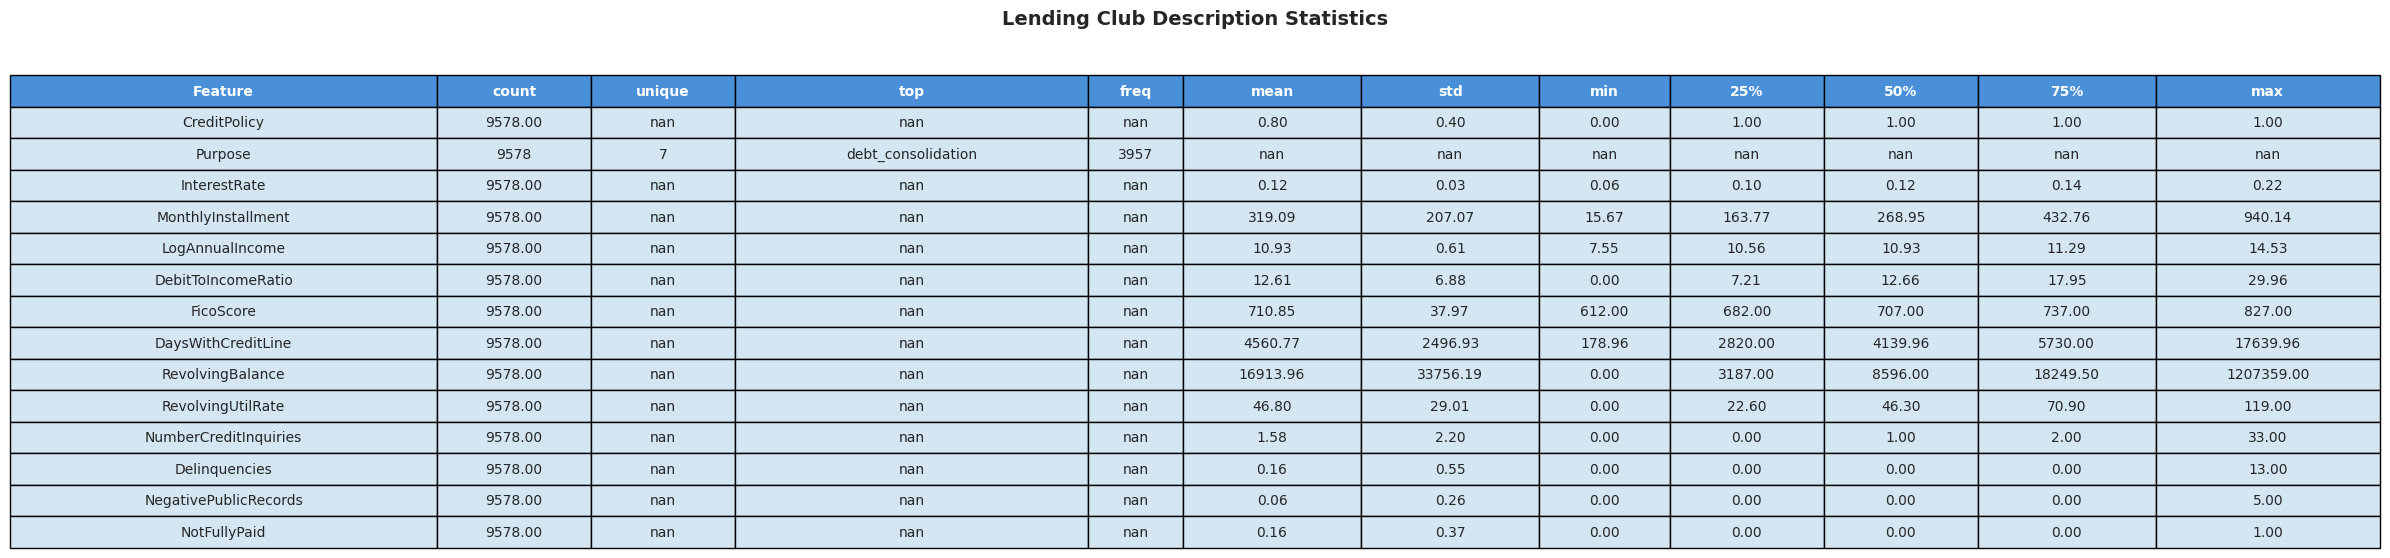

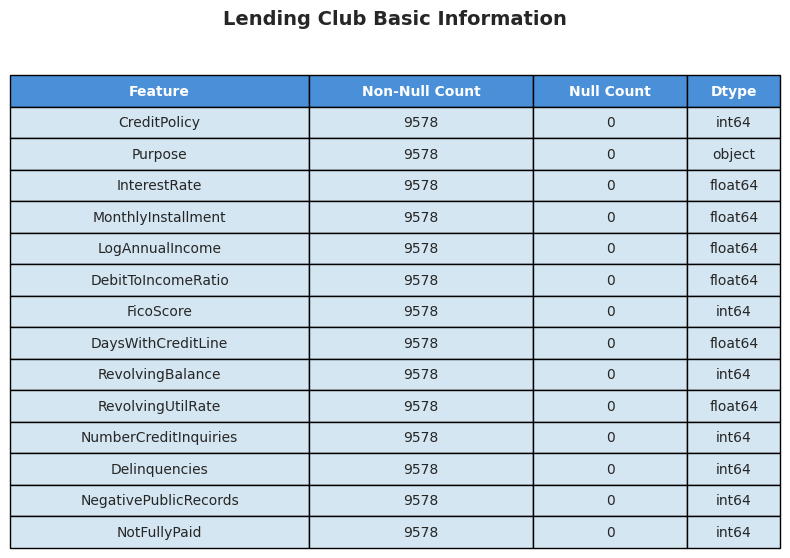

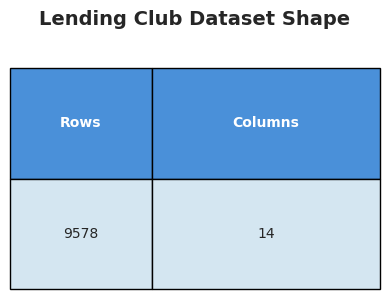




No data to display: Lending Club Missing Categorical (String) Data

No data to display: Lending Club Missing Numeric Data



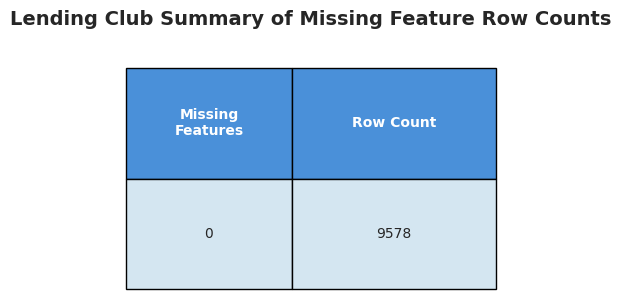

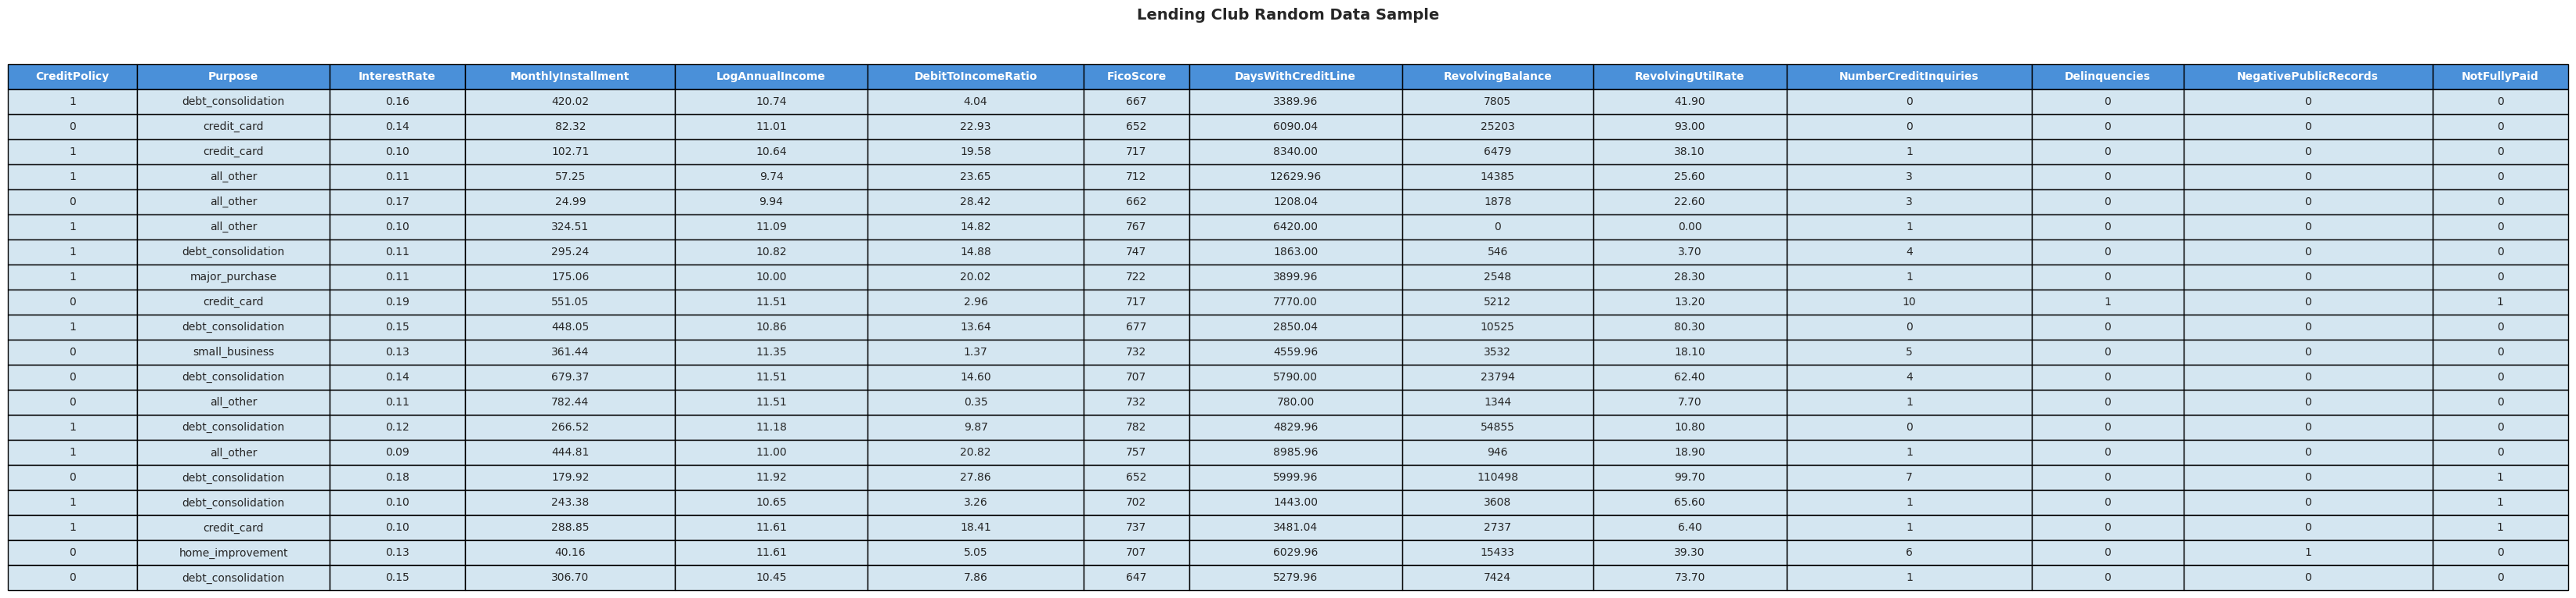

In [117]:
# Update Feature Names
label = 'NotFullyPaid'
features = ['CreditPolicy', 'Purpose', 'InterestRate','MonthlyInstallment', 'LogAnnualIncome', 'DebitToIncomeRatio', 'FicoScore', 'DaysWithCreditLine', 
            'RevolvingBalance', 'RevolvingUtilRate', 'NumberCreditInquiries', 'Delinquencies', 'NegativePublicRecords', 'NotFullyPaid' ]

df_LendingClub.columns = features

features.remove(label)
PrintDataFrameStatistics(df_LendingClub)

### **Initial EDA Analysis** ###
- Data - 9579 rows of data, 13 features (columns), 1 labels
- No rows of missing or (nan) data in either dataset
- Need to leading/following trim() categorical feature columns

#### Plots To Further Examine Data and Distributions ####
Display some initial Bar/Count Plots to give us an insight into any trends such as:
- Distribution of Loan Purposes
- Distribution of continuous numerical features including (InterestRate, MonthlyInstallment, FicoScore)
- Distribution of binary (integer) features such as (NumberOfCreditInquires, Delinquencies)

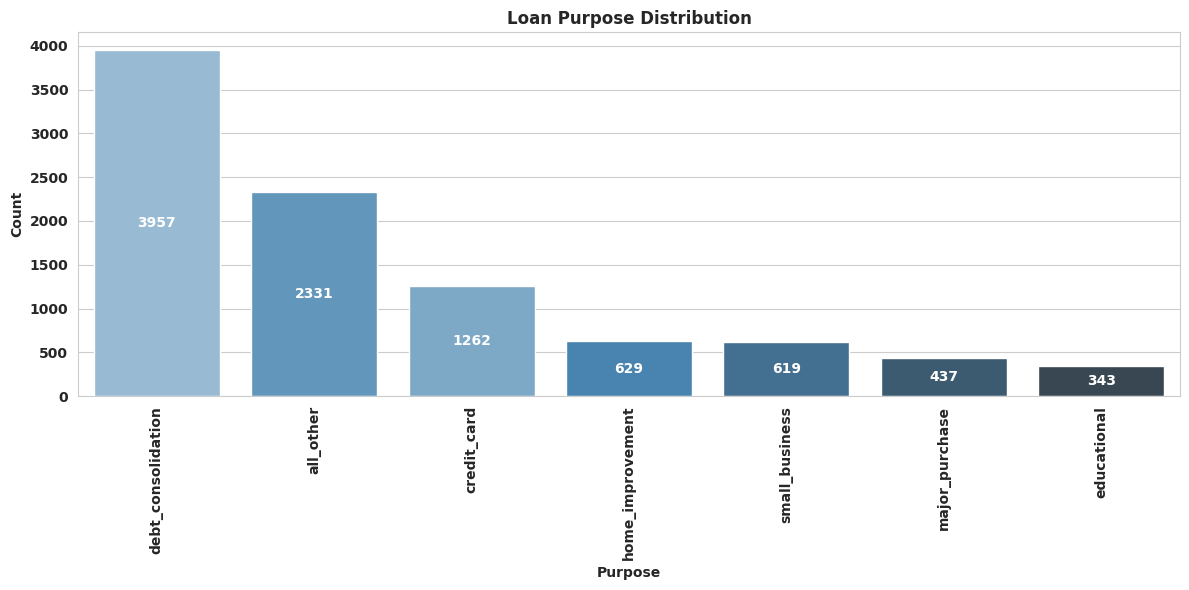

In [118]:
#
# Loan Purpose Distribution
# print(df_LendingClub['Purpose'].unique())
# print(df_LendingClub['Purpose'].value_counts())
# print(df_LendingClub['Purpose'].nunique())

purpose_order = df_LendingClub['Purpose'].value_counts().index
DisplayCountPlot(df_LendingClub, 'Purpose', purpose_order, 'Loan Purpose Distribution', (12,6))

#### Loan Purpose Distribution Analysis ####
- debit_consolidation accounts for the most loans (**41%**)
- all_other (**24%**) and credit_card (**13%**) are next highest 
- All together, they account for **78%** of all the loan types

#### Histograms of Continuous Numeric Features ####

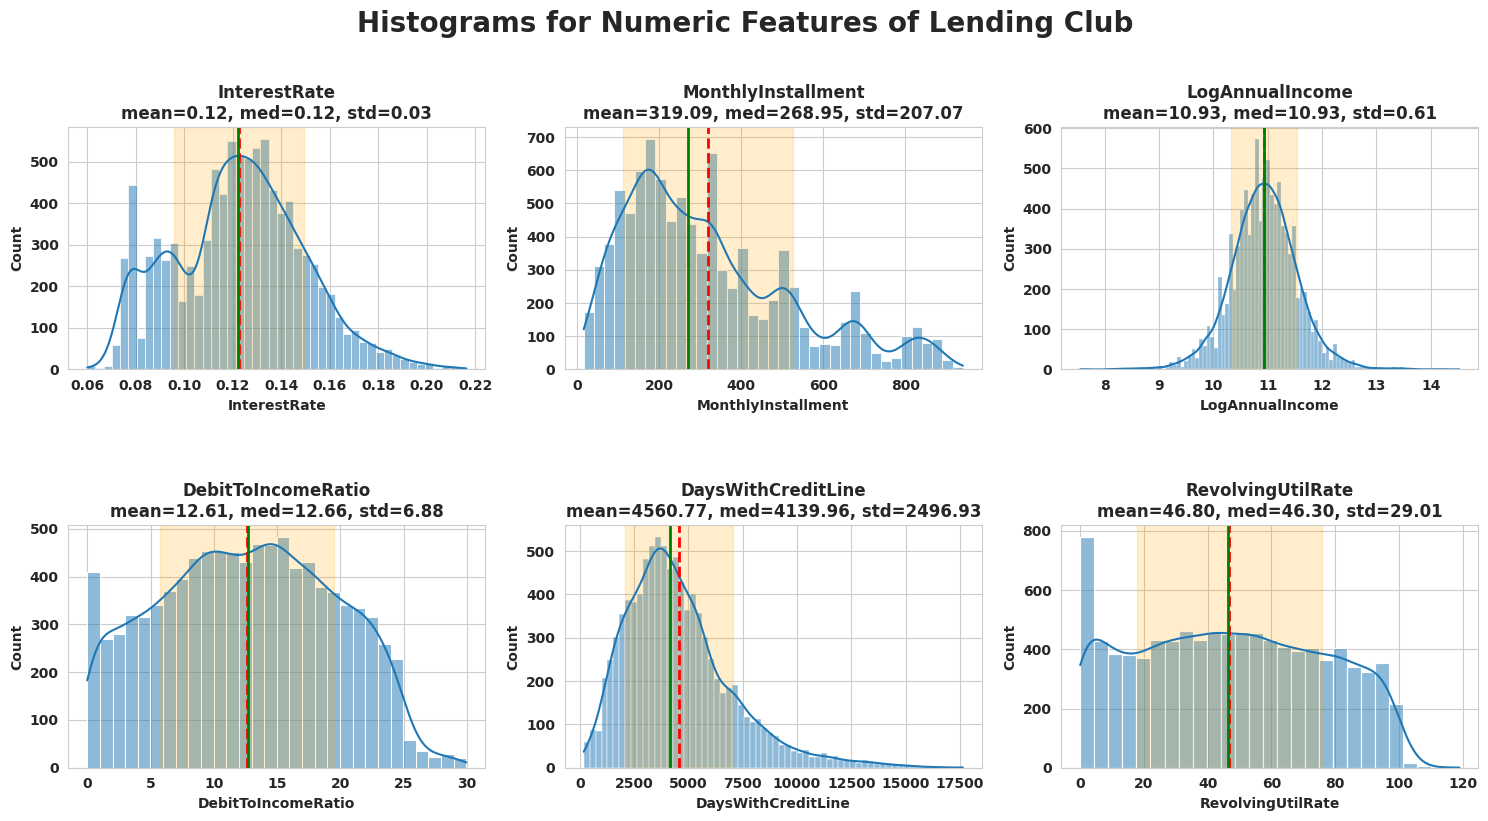

In [119]:
# Get a list of the float columns
float_columns = df_LendingClub.select_dtypes(include=['float']).columns.tolist()
#print(float_columns)

DisplayNumericFeatureHistograms(df_LendingClub, 
                                feature_columns=float_columns,
                                plot_title = 'Continuous Numeric Feature Distributions', 
                                display_statistics=True)

#### Continuous Numeric Feature Histograms Analysis ####
- InterestRate
    - Bimodal Distribution with Right Skew
- MonthlyInstallment
    - Right Skewed Distribution with a second peak around 270
- LogAnnualIncome
    - Perfect Normal Distribution - because it's Log...
    - Mean/Medium **10.93**
- DebitToIncomeRatio
    - Approximately Normal (Symmeteric) Distribution with a spike around 0
- DaysWithCreditLine
    - Normalish Right-Skewed Distribution
- RevolvingUtilRate
    - Uniform Distribtution with a spike at 0 and quick right tail after 100

**Action Item**: Normalize all the non-normal distributions during **Feature Engineering**

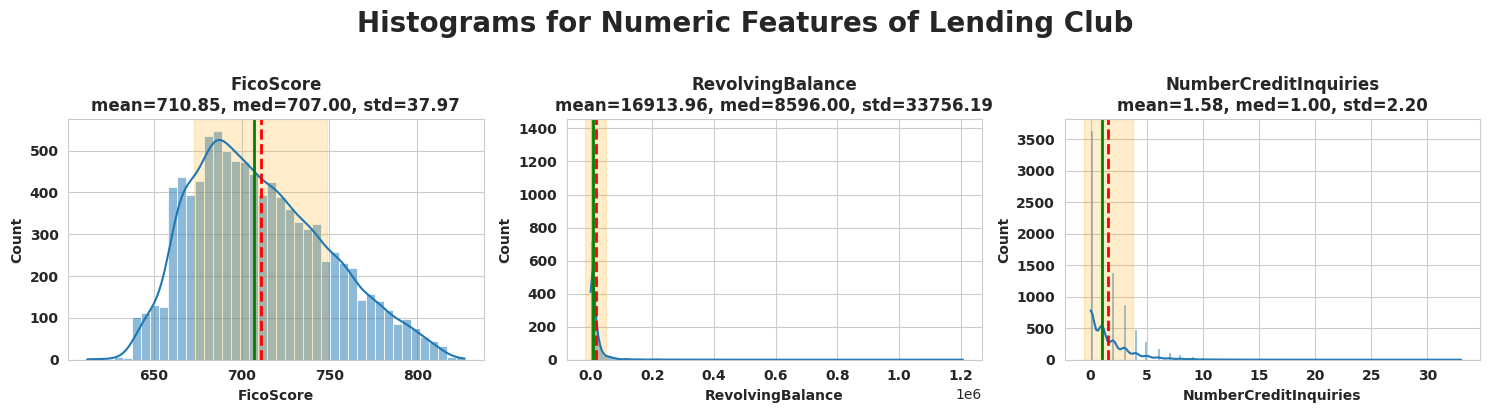

In [120]:
# Get a list of the continuous int feature columns
columns_to_plot = ['FicoScore', 'RevolvingBalance', 'NumberCreditInquiries']

DisplayNumericFeatureHistograms(df_LendingClub, 
                                feature_columns=columns_to_plot,
                                plot_title = 'Continuous Integer Feature Distributions', 
                                display_statistics=True)

#### Continuous Integer Feature Distributions Analysis ####
- FicoScore
    - Approximate Normal Distribution with a definite right skew
- RevolvingBalance
    - Heavily Right Skewed Distribution with extreme outliers
- NumberCreditInquiries
    - Right Skewed Distribution with extreme outliers

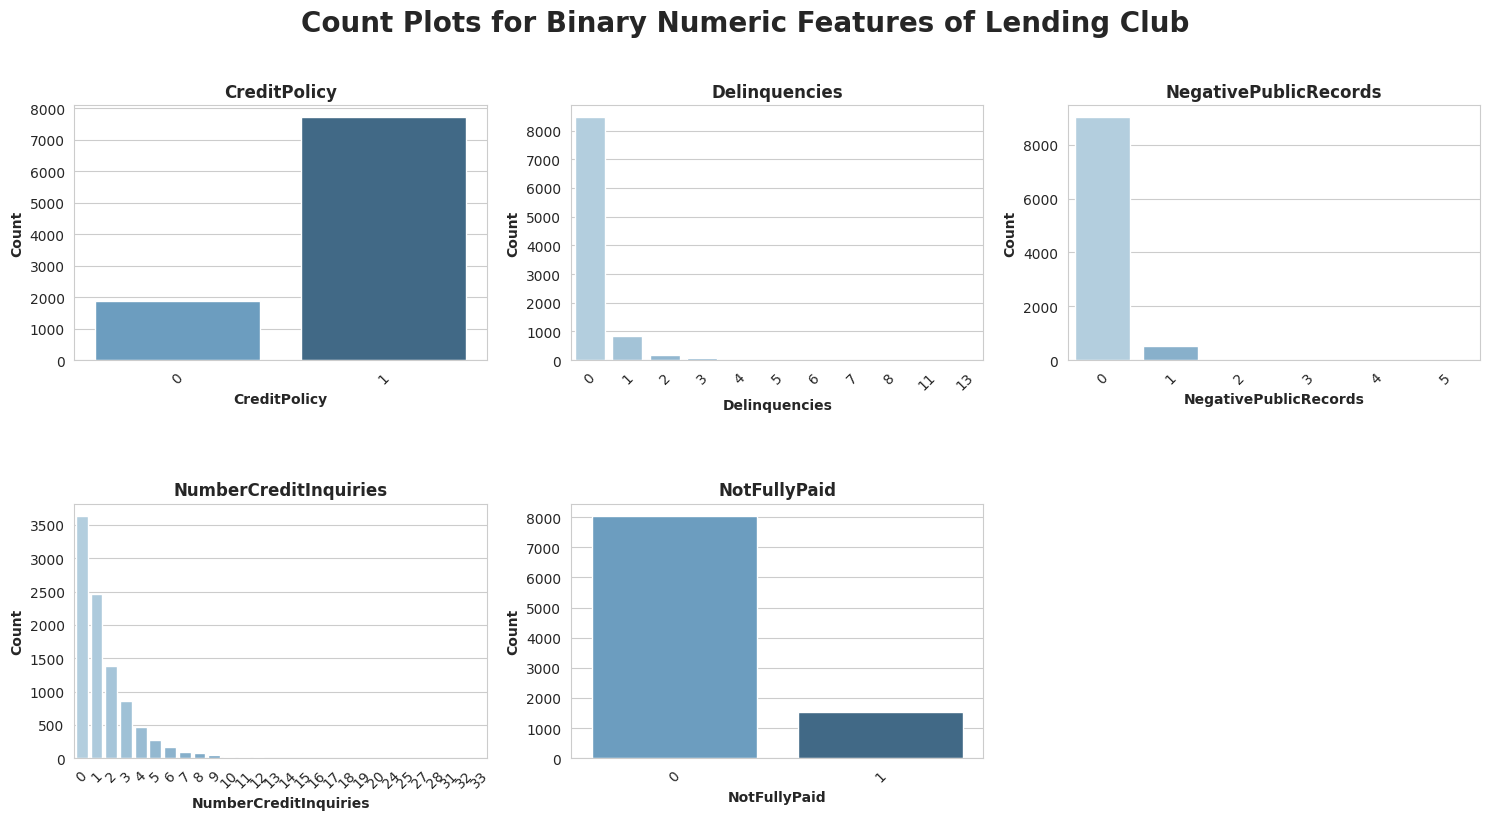

In [121]:
# Get a list of the integer columns
#integer_columns = df_LendingClub.select_dtypes(include=['int']).columns.tolist()
#print(integer_columns)
columns_to_plot = ['CreditPolicy', 'Delinquencies', 'NegativePublicRecords', 'NumberCreditInquiries', 'NotFullyPaid']

DisplayNumericFeatureCountPlots(df_LendingClub,
                                columns_to_plot,
                                target_label=None,
                                plot_title=data_set_name)


#### Count Plot Feature Distributions Analysis ####
- CreditPolicy
    - Most people (**80%)** meet the credit underwriting criteria
- Delinquencies
    - Most people do not have delinquencies
- NegativePublicRecords
    - Most people do not have negative public records
- NumberCreditInquiries
     -Right Skewed Distribution with extreme outliers
- NotFullyPaid
    - Imbalanced - Majority of people are not fully paid

#### Unbalanced Distribution of Dataset Label: **NotFullyPaid**
Display plots showing the distribution of the label (NotFullyPaid).</br>
The plots clearly show in the intended label that far more people **DID NOT** fully pay their loans</br>
This will have to be dealt with later on in the **Feature Engineering**

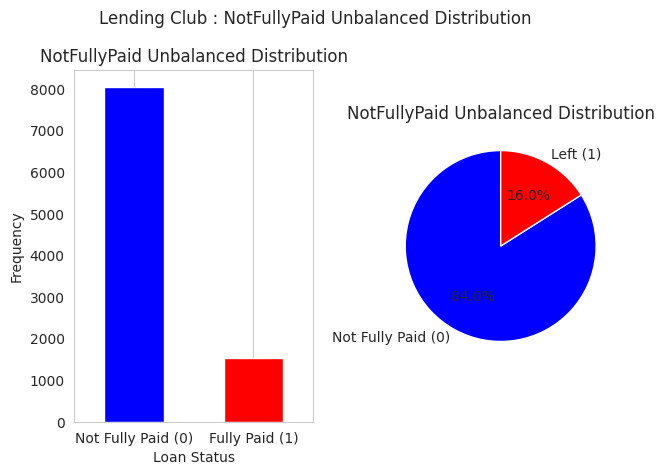

In [122]:
def DisplayDataFeatureBalancePlots(x_data, y_data, plot_title, label_name):

    sub_plot_title = f"{label_name} Unbalanced Distribution"

    leftCounts = y_data.value_counts().sort_index()

    plt.subplot(1, 2, 1)
    leftCounts.plot(kind='bar', color=['blue', 'red'])
    plt.title(sub_plot_title)
    plt.xlabel('Loan Status')
    plt.ylabel('Frequency')
    plt.xticks(ticks=[0, 1], labels=['Not Fully Paid (0)', 'Fully Paid (1)'], rotation=0)
    plt.grid(axis='y')

    # Plot the distribution of the 'Class' column as a pie chart
    plt.subplot(1, 2, 2)
    leftCounts.plot(kind='pie', labels=['Not Fully Paid (0)', 'Left (1)'], colors=['blue', 'red'], autopct='%1.1f%%', startangle=90)
    plt.title(sub_plot_title)
    plt.ylabel('')

    plt.suptitle(plot_title)

    # Show the plots
    plt.tight_layout()
    plt.show()
    print()

    if x_data is not None:
        print("Scatter Plot Unbalanced Data")
        # Scatter plot for the imbalanced data
        plt.figure(figsize=(12, 5))
        plt.scatter(x_data[:, 0], x_data[:, 1], c=y_data, alpha=0.5, cmap='viridis', marker='o')
        plt.title(title)
        plt.xlabel('Feature 1')
        plt.ylabel('Feature 2')
        plt.colorbar(label='Class')
    print()
    print()

DisplayDataFeatureBalancePlots(x_data=None, 
                               y_data=df_LendingClub[label], 
                               plot_title= f'{data_set_name} : {label} Unbalanced Distribution',
                               label_name = label)

## **2. Non-Feature Engineered Modeling for Baseline** ##
Choose, justify and train a (1) Machine Learning model and a (1) Deep Learning Model. </br>
Train these models against unfeature engineered data. </br>
The Unfeature Engineered dataset will require the minimal amount of feature engineering required to get the models working.</br>
In a later section the same models will be run against **Feature Engineered** data.</br>

This will give the opportunity to make 2 comparisons:
1. Within each Un/Feature Engineered bucket, compare the **Machine Learning** and **Deep Learning Models**
2. Compare the overall performance (best model) results between the Unfeature and Feature Engineered buckets.

#### Limited Feature Engineering ####
Complete the minimum amount of feature engineering required to get the models to run.</br>
In this case we have to encode the string feature 'Purpose' to numeric values.

In [123]:
# One-Hot-Encode Purpose - no implied ordinal ranking
df_LendingClub = pd.get_dummies(df_LendingClub, columns=['Purpose'], drop_first=True, dtype=int)

### Test-Train Split ###

In [124]:
# # Separate features and target variable
X = df_LendingClub.drop(label, axis=1)
y = df_LendingClub[label]

# Test/Train Split 80:20
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

## **3. Non-Feature Engineered Modeling for Baseline** ##
### Machine Learning Models ###
I will examine/compare the results of 3 Machine Learning models:
1. Logisitic Regression 
2. Random Forest Classifier
3. Gradient Boosting Classifier

#### The Initial Version of the Machine Learning Models ####
The requirements of the assignment specified that limited feature engineering be done against the </br>
dataset before the initial run of the models. Complete the minimal amount of feature engineering required to </br>
get the models functional. The dataset is highly imbalanced, and the intent was to run the models against this</br>
class imbalance.</br>

Through an error on my part, I included using **class_weight='balanced'** in the **ML** model creation. The **Deep Learning (DL) Sequential** </br>
model was **NOT** constructed using any weighting/scaling strategy. While this would not normally be a bad thing, in this instance </br>
it nullified my initial comparison of ML and DL performance results. 

This has been rectified for subsequent model runs and the comparison metrics have been updated accordingly. </br>

#### Machine Learning Utility Functions ####
These utility functions were taken directly from my "**Machine Learning - Unit 3 End Project**" </br>
Ultimately (when time permits -- **HA**!) I would like to place these reoccurring functions in a private utility library.

In [125]:
#
# LogisticRegression
# 
def RunLogisticRegression(df_target=None, target_label=None, plot_title=None, 
                          apply_scaling=False, apply_pca=False,
                          X_train=None, X_test=None, y_train=None, y_test=None,
                          feature_names=None):
    
    # Use the provided pre-split (SMOTE) data
    if X_train is not None and X_test is not None and y_train is not None and y_test is not None:

        X = None 
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]
    else:
        # Perform Test/Train Split here
        X = df_target.drop(target_label, axis=1)
        y = df_target[target_label]
        feature_names = X.columns
        
        # Split Data into Training/Test => 80/20
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

        if apply_scaling == True:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        if apply_pca:
            pca = PCA(n_components=0.95)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            print(f'PCA Components: {pca.n_components_}')
            print(f'Variance Explained: {pca.explained_variance_ratio_.sum():.2%}')
            print()

    # Balanced Class Weight 
    # Remove class_weight='balanced' parameter
    model = LogisticRegression(random_state=315, max_iter=1000)
    model.fit(X_train, y_train)

    # Predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    # Metrics
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions, average='weighted')

    print('=' * 60)
    print(f'{plot_title} LOGISTIC REGRESSION RESULTS')
    print('=' * 60)
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Testing Accuracy:  {test_accuracy:.4f}')
    print(f'Testing F1 Score:  {test_f1:.4f}')
    print(f'Gap:               {train_accuracy - test_accuracy:.4f}')
    print()

    # Classification Report (includes precision, recall, F1)
    print('-' * 60)
    print(f'{plot_title} TEST DATA - Classification Report')
    print('-' * 60)
    report = classification_report(y_test, test_predictions, output_dict=True)
    print(report)
    print()

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, ax=ax, cmap='Blues')
    plt.title(f'{plot_title} Logistic Regression - Test Data Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    # Feature Importance
    print('-' * 60)
    print(f'{plot_title} FEATURE IMPORTANCE')
    print('-' * 60)
    
    avg_importance = pd.Series(
        np.abs(model.coef_).mean(axis=0),
        index=feature_names
    ).sort_values(ascending=False)
    
    print(avg_importance)
    print()

    plt.figure(figsize=(10, 6))
    avg_importance.sort_values().plot(kind='barh')
    plt.xlabel('Average Absolute Coefficient')
    plt.title(f'{plot_title} Feature Importance - Logistic Regression', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
            'model': model,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'f1_score': test_f1,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test, 
            'test_predictions': test_predictions,
            'report': report
        }


#
# RandomForestClassifier
# 
def RunRandomForestClassifier(df_target=None, target_label=None, plot_title=None, 
                              apply_scaling=False, apply_pca=False,
                              X_train=None, X_test=None, y_train=None, y_test=None,
                              feature_names=None):

    # Use the provided pre-split (SMOTE) data
    if X_train is not None and X_test is not None and y_train is not None and y_test is not None:
        X = None
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]
    else:
        # Perform Test/Train Split here
        X = df_target.drop(target_label, axis=1)
        y = df_target[target_label]
        feature_names = X.columns

        # Split Data into Training/Test => 80/20
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

        if apply_scaling == True:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # PCA - after scaling, before model
        if apply_pca:
            pca = PCA(n_components=0.95)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            print(f'PCA Components: {pca.n_components_}')
            print(f'Variance Explained: {pca.explained_variance_ratio_.sum():.2%}')
            print()             

    # Balanced Class Weight 
    # Remove class_weight='balanced' parameter
    model = RandomForestClassifier(
        n_estimators=100,
        max_depth=None,
        min_samples_split=2,
        min_samples_leaf=1,
        max_features='sqrt',
        random_state=315,
        n_jobs=-1
    )
    
    model.fit(X_train, y_train)

    # Predictions
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    # Metrics
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions, average='weighted')

    print('=' * 60)
    print(f'{plot_title} RANDOM FOREST CLASSIFIER RESULTS')
    print('=' * 60)
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Testing Accuracy:  {test_accuracy:.4f}')
    print(f'Testing F1 Score:  {test_f1:.4f}')
    print(f'Gap:               {train_accuracy - test_accuracy:.4f}')
    print()

    # Classification Report
    print('-' * 60)
    print(f'{plot_title} TEST DATA - Classification Report')
    print('-' * 60)
    report = classification_report(y_test, test_predictions, output_dict=True)
    print(report)
    print()

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, ax=ax, cmap='Blues')
    plt.title(f'{plot_title} Random Forest - Test Data Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    # Feature Importance
    print('-' * 60)
    print(f'{plot_title} FEATURE IMPORTANCE')
    print('-' * 60)
    
    # RandomForest uses feature_importances_ (not coef_)
    feature_importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)
    
    print(feature_importance)
    print()

    plt.figure(figsize=(10, 6))
    feature_importance.sort_values().plot(kind='barh')
    plt.xlabel('Feature Importance (Gini)')
    plt.title(f'{plot_title} Feature Importance - Random Forest', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
            'model': model,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'f1_score': test_f1,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test, 
            'test_predictions': test_predictions,
            'report': report
        }

#
# GradientBoostingClassifier
# 
def RunGradientBoostingClassifier(df_target=None, target_label=None, plot_title=None, 
                                  apply_scaling=False, apply_pca=False,
                                  X_train=None, X_test=None, y_train=None, y_test=None,
                                  feature_names=None):

    # Use the provided pre-split (SMOTE) data
    if X_train is not None and X_test is not None and y_train is not None and y_test is not None:
        X = None
        if feature_names is None:
            feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]
    else:
        # Perform Test/Train Split here
        X = df_target.drop(target_label, axis=1)
        y = df_target[target_label]
        feature_names = X.columns

        # Split Data into Training/Test => 80/20
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

        if apply_scaling == True:
            scaler = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test = scaler.transform(X_test)

        # PCA - after scaling, before model
        if apply_pca:
            pca = PCA(n_components=0.95)
            X_train = pca.fit_transform(X_train)
            X_test = pca.transform(X_test)
            print(f'PCA Components: {pca.n_components_}')
            print(f'Variance Explained: {pca.explained_variance_ratio_.sum():.2%}')
            print()

    # Gradient Boosting Classifier
    # Note: GradientBoostingClassifier does not support class_weight parameter
    # Using SMOTE data handles class imbalance instead
    model = GradientBoostingClassifier(
                                        n_estimators=100,
                                        learning_rate=0.1,
                                        max_depth=3,
                                        min_samples_split=2,
                                        min_samples_leaf=1,
                                        max_features='sqrt',
                                        random_state=315
                                    )
    model.fit(X_train, y_train)

    #
    # Predictions
    #
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)

    #
    # Metrics
    #
    train_accuracy = accuracy_score(y_train, train_predictions)
    test_accuracy = accuracy_score(y_test, test_predictions)
    test_f1 = f1_score(y_test, test_predictions, average='weighted')

    print('=' * 60)
    print(f'{plot_title} GRADIENT BOOSTING CLASSIFIER RESULTS')
    print('=' * 60)
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Testing Accuracy:  {test_accuracy:.4f}')
    print(f'Testing F1 Score:  {test_f1:.4f}')
    print(f'Gap:               {train_accuracy - test_accuracy:.4f}')
    print()

    #
    # Classification Report (includes precision, recall, F1)
    #
    print('-' * 60)
    print(f'{plot_title} TEST DATA - Classification Report')
    print('-' * 60)
    report = classification_report(y_test, test_predictions, output_dict=True)
    print(report)
    print()

    #
    # Confusion Matrix
    #
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, test_predictions, ax=ax, cmap='Blues')
    plt.title(f'{plot_title} Gradient Boosting - Test Data Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    #
    # Feature Importance
    #
    print('-' * 60)
    print(f'{plot_title} FEATURE IMPORTANCE')
    print('-' * 60)
    
    # GradientBoosting uses feature_importances_ (like RandomForest)
    feature_importance = pd.Series(
        model.feature_importances_,
        index=feature_names
    ).sort_values(ascending=False)
    
    print(feature_importance)
    print()

    plt.figure(figsize=(10, 6))
    feature_importance.sort_values().plot(kind='barh')
    plt.xlabel('Feature Importance')
    plt.title(f'{plot_title} Feature Importance - Gradient Boosting', fontweight='bold')
    plt.tight_layout()
    plt.show()

    return {
            'model': model,
            'train_accuracy': train_accuracy,
            'test_accuracy': test_accuracy,
            'f1_score': test_f1,
            'X_train': X_train,
            'X_test': X_test,
            'y_train': y_train,
            'y_test': y_test, 
            'test_predictions': test_predictions,
            'report': report
        }

def PlotConfusionMatrices(results_dict):
    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 5))
    
    if n_models == 1:
        axes = [axes]
    
    palettes = ['Blues', 'Greens', 'Oranges', 'Purples']
    
    for i, (name, results) in enumerate(results_dict.items()):
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        cm = confusion_matrix(y_test, test_predictions)
        
        sns.heatmap(cm, annot=True, fmt='d', cmap=palettes[i % len(palettes)], 
                    ax=axes[i], cbar=True)
        axes[i].set_title(f'{name}', fontweight='bold')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('Actual')
    
    plt.suptitle('Confusion Matrix Comparison', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print()

def CompareClassificationResults(results_dict, title='Classifier Comparison'):
    
    sns.set_style("whitegrid")
    
    #
    # 1. Calculate all metrics
    #
    metrics_data = []
    for name, results in results_dict.items():
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        report = results['report']
        
        metrics_data.append({
            'Model': name,
            'Train Accuracy': results['train_accuracy'],
            'Test Accuracy': results['test_accuracy'],
            'Balanced Accuracy': balanced_accuracy_score(y_test, test_predictions),
            'Precision': precision_score(y_test, test_predictions, average='weighted'),
            'Recall': recall_score(y_test, test_predictions, average='weighted'),
            'F1 Score': results['f1_score'],
            'Gap': results['train_accuracy'] - results['test_accuracy']
        })
    
    df_comparisons = pd.DataFrame(metrics_data).set_index('Model')
    
    #
    # 2. Print Metrics Table
    #
    print('=' * 70)
    print(title)
    print('=' * 70)
    print(df_comparisons.round(4))
    print()

    DisplayTable(df_comparisons, 'Classification Comparisons',show_index=True)
    
    #
    # 3. Accuracy Comparison (Train vs Test vs Balanced)
    #
    accuracy_metrics = []
    for name, results in results_dict.items():
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        
        accuracy_metrics.append({'Model': name, 'Metric': 'Train Accuracy', 'Score': results['train_accuracy']})
        accuracy_metrics.append({'Model': name, 'Metric': 'Test Accuracy', 'Score': results['test_accuracy']})
        accuracy_metrics.append({'Model': name, 'Metric': 'Balanced Accuracy', 'Score': balanced_accuracy_score(y_test, test_predictions)})
    
    acc_df = pd.DataFrame(accuracy_metrics)
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=acc_df, x='Metric', y='Score', hue='Model', palette='deep')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
    plt.title('Accuracy Metrics Comparison', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 4. Precision / Recall / F1 Comparison
    #
    prf_metrics = []
    for name, results in results_dict.items():
        model = results['model']
        X_test = results['X_test']
        y_test = results['y_test']
        test_predictions = model.predict(X_test)
        
        prf_metrics.append({'Model': name, 'Metric': 'Precision', 'Score': precision_score(y_test, test_predictions, average='weighted')})
        prf_metrics.append({'Model': name, 'Metric': 'Recall', 'Score': recall_score(y_test, test_predictions, average='weighted')})
        prf_metrics.append({'Model': name, 'Metric': 'F1 Score', 'Score': results['f1_score']})
    
    prf_df = pd.DataFrame(prf_metrics)
    
    plt.figure(figsize=(12, 6))
    ax = sns.barplot(data=prf_df, x='Metric', y='Score', hue='Model', palette='Set2')
    for container in ax.containers:
        ax.bar_label(container, fmt='%.3f', fontsize=9)
    plt.title('Precision / Recall / F1 Comparison', fontweight='bold')
    plt.ylim(0, 1.1)
    plt.legend(title='Model')
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 5. Gap Comparison (Overfitting indicator)
    #
    gap_data = pd.DataFrame({
        'Model': list(results_dict.keys()),
        'Gap': [r['train_accuracy'] - r['test_accuracy'] for r in results_dict.values()]
    })
    
    plt.figure(figsize=(10, 5))
    ax = sns.barplot(data=gap_data, x='Model', y='Gap', palette='deep')
    ax.bar_label(ax.containers[0], fmt='%.4f', fontsize=10)
    ax.axhline(y=0, color='red', linestyle='--', alpha=0.5)
    plt.title('Overfitting Indicator (Lower is Better)', fontweight='bold')
    plt.ylabel('Train - Test Accuracy Gap')
    plt.tight_layout()
    plt.show()
    print()
    
    #
    # 6. Confusion Matrices
    #
    PlotConfusionMatrices(results_dict)
    
    #
    # 7. Metrics Heatmap
    #
    plt.figure(figsize=(12, len(results_dict) * 0.8 + 2))
    heatmap_cols = ['Test Accuracy', 'Balanced Accuracy', 'Precision', 'Recall', 'F1 Score']
    sns.heatmap(df_comparisons[heatmap_cols], annot=True, fmt='.4f', cmap='YlGnBu', 
                vmin=0, vmax=1, linewidths=0.5)
    plt.title('Model Metrics Heatmap', fontweight='bold')
    plt.tight_layout()
    plt.show()

    #
    # 8. Plot Classification Report Results
    #
    for i, (name, results) in enumerate(results_dict.items()):

        report = results['report']
        df_result = pd.DataFrame(report)
        DisplayTable(df_result, 
                     f'{name} Classification Report',
                     show_index=True)
    
    n_models = len(results_dict)
    fig, axes = plt.subplots(1, n_models, figsize=(6 * n_models, 4))

    if n_models == 1:
        axes = [axes]

    for i, (name, results) in enumerate(results_dict.items()):
        report = results['report']
        df_report = pd.DataFrame(report).T
        
        # Keep only class rows and main metrics
        df_report = df_report.drop(['accuracy', 'macro avg', 'weighted avg'], errors='ignore')
        df_report = df_report.drop(columns=['support'], errors='ignore')
        
        sns.heatmap(df_report, annot=True, fmt='.2f', cmap='RdYlGn',
                    vmin=0, vmax=1, ax=axes[i], linewidths=0.5)
        axes[i].set_title(f'{name}', fontweight='bold')
        axes[i].set_ylabel('Class')
        axes[i].set_xlabel('Metric')

    plt.suptitle('Classification Reports Comparison', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()

    return df_comparisons

def CheckClusterDistributions(df_target, feature_name, title):
    print(f'{title} Cluster Distribution Comparisons')
    valueCounts = df_target[feature_name].value_counts()
    print(f'ValueCounts: {valueCounts}')
    normalizedValueCounts = df_target[feature_name].value_counts(normalize=True) * 100
    print(f'NormalizedValueCounts: {normalizedValueCounts}')
    print()

#### Cross Validation Utility Functions ####
These utility functions were taken directly from my "**Machine Learning - Unit 3 End Project**" </br>

In [126]:
def ApplyCrossValidationClassification(model, X, y, plot_label, apply_crossvalidation=True):

    # Split for train/test calculation
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315)

    # Fit model and calculate train/test metrics
    model.fit(X_train, y_train)
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    test_f1 = f1_score(y_test, model.predict(X_test), average='weighted')

    # Issues with applying cross-validation with Keras Sequential Model
    # So rather than complicate things a lot further -- skip it
    if not apply_crossvalidation:
        print('Cross-validation skipped.')
        print()
        return {'cv_accuracy': None, 'cv_f1': None}

    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    # Cross-validation for Accuracy
    cv_accuracy = cross_val_score(model, X, y, scoring='accuracy', n_jobs=-1, cv=kf)

    # Cross-validation for F1 Score
    cv_f1 = cross_val_score(model, X, y, scoring='f1_weighted', n_jobs=-1, cv=kf)

    # Accuracy stats
    acc_mean = np.mean(cv_accuracy)
    acc_std = np.std(cv_accuracy)
    acc_moe = 1.96 * acc_std / np.sqrt(len(cv_accuracy))

    # F1 stats
    f1_mean = np.mean(cv_f1)
    f1_std = np.std(cv_f1)
    f1_moe = 1.96 * f1_std / np.sqrt(len(cv_f1))

    print(plot_label)
    print(f'Mean CV Accuracy: {acc_mean:.4f} ± {acc_moe:.4f}')
    print(f'95% CI Accuracy: {acc_mean - acc_moe:.4f} to {acc_mean + acc_moe:.4f}')
    print(f'Mean CV F1 Score: {f1_mean:.4f} ± {f1_moe:.4f}')
    print(f'95% CI F1: {f1_mean - f1_moe:.4f} to {f1_mean + f1_moe:.4f}')
    print(f'Train Accuracy: {train_accuracy:.4f}')
    print(f'Test Accuracy: {test_accuracy:.4f}')
    print(f'Test F1 Score: {test_f1:.4f}')

    # Plot
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Accuracy boxplot
    axes[0].boxplot(cv_accuracy)
    axes[0].axhline(acc_mean - acc_moe, linestyle='--', color='teal', label='95% CI')
    axes[0].axhline(acc_mean + acc_moe, linestyle='--', color='teal')
    axes[0].axhline(test_accuracy, color='purple', label='Test Accuracy')
    axes[0].axhline(train_accuracy, color='red', label='Train Accuracy')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title(f'CV Accuracy - {plot_label}')
    axes[0].legend(loc='best')

    # F1 boxplot
    axes[1].boxplot(cv_f1)
    axes[1].axhline(f1_mean - f1_moe, linestyle='--', color='teal', label='95% CI')
    axes[1].axhline(f1_mean + f1_moe, linestyle='--', color='teal')
    axes[1].axhline(test_f1, color='purple', label='Test F1')
    axes[1].set_ylabel('F1 Score')
    axes[1].set_title(f'CV F1 Score - {plot_label}')
    axes[1].legend(loc='best')

    plt.tight_layout()
    plt.show()

    print()
    print()

    return {'cv_accuracy': cv_accuracy, 'cv_f1': cv_f1}

### Machine Learning Baseline Models ###
Package the Machine Learning functions with CrossValidation so they can be rerun against the Feature Engineered datasets.
#### Logistic Regression ####

Logistic Regression


/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Lending Club Loan Data LOGISTIC REGRESSION RESULTS
Training Accuracy: 0.8418
Testing Accuracy:  0.8288
Testing F1 Score:  0.7584
Gap:               0.0130

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.8321935823250921, 'recall': 0.994343180389692, 'f1-score': 0.9060710194730813, 'support': 1591.0}, '1': {'precision': 0.4, 'recall': 0.018461538461538463, 'f1-score': 0.03529411764705882, 'support': 325.0}, 'accuracy': 0.8288100208768268, 'macro avg': {'precision': 0.6160967911625461, 'recall': 0.5064023594256153, 'f1-score': 0.47068256856007007, 'support': 1916.0}, 'weighted avg': {'precision': 0.7588830842793431, 'recall': 0.8288100208768268, 'f1-score': 0.7583661692155357, 'support': 1916.0}}



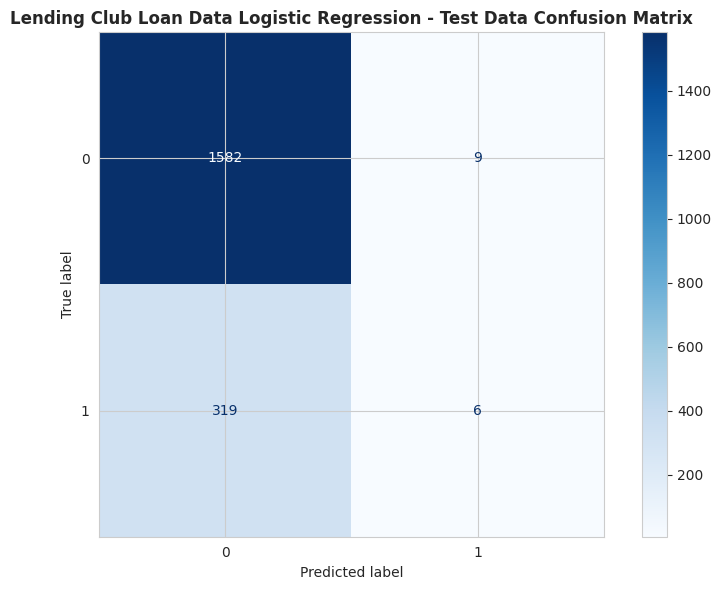


------------------------------------------------------------
Lending Club Loan Data FEATURE IMPORTANCE
------------------------------------------------------------
Purpose_small_business        0.531735
CreditPolicy                  0.469751
Purpose_credit_card           0.432382
Purpose_debt_consolidation    0.369992
NegativePublicRecords         0.277389
Purpose_educational           0.163256
LogAnnualIncome               0.113734
NumberCreditInquiries         0.106583
Purpose_major_purchase        0.077040
InterestRate                  0.063234
Delinquencies                 0.030879
RevolvingUtilRate             0.006710
DebitToIncomeRatio            0.004348
Purpose_home_improvement      0.002699
FicoScore                     0.001169
MonthlyInstallment            0.000820
DaysWithCreditLine            0.000025
RevolvingBalance              0.000001
dtype: float64



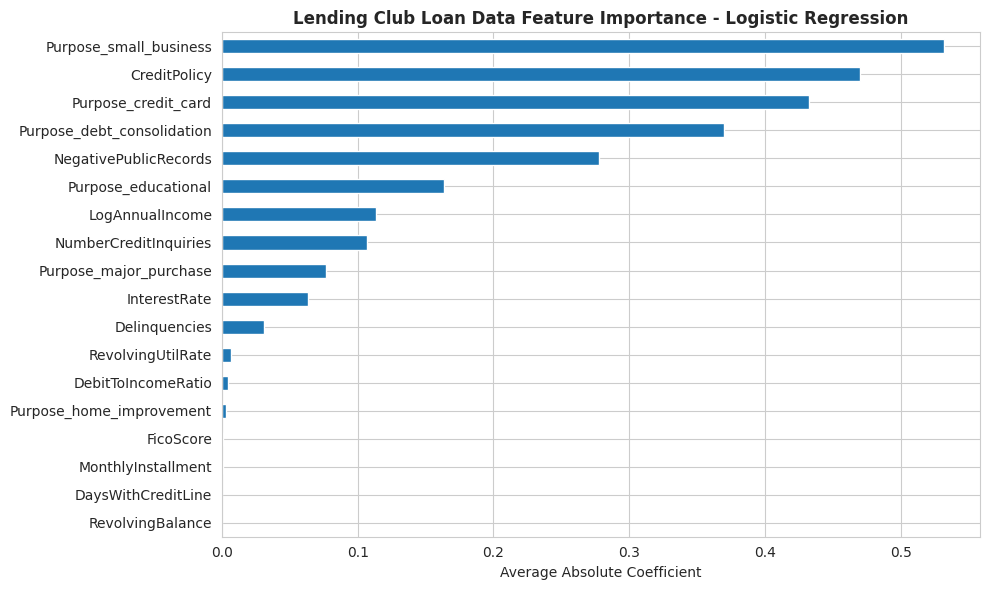

/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.10/dist-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Logistic Regression 5-Fold CV
Mean CV Accuracy: 0.8423 ± 0.0117
95% CI Accuracy: 0.8306 to 0.8541
Mean CV F1 Score: 0.7775 ± 0.0161
95% CI F1: 0.7614 to 0.7936
Train Accuracy: 0.8398
Test Accuracy: 0.8506
Test F1 Score: 0.7874


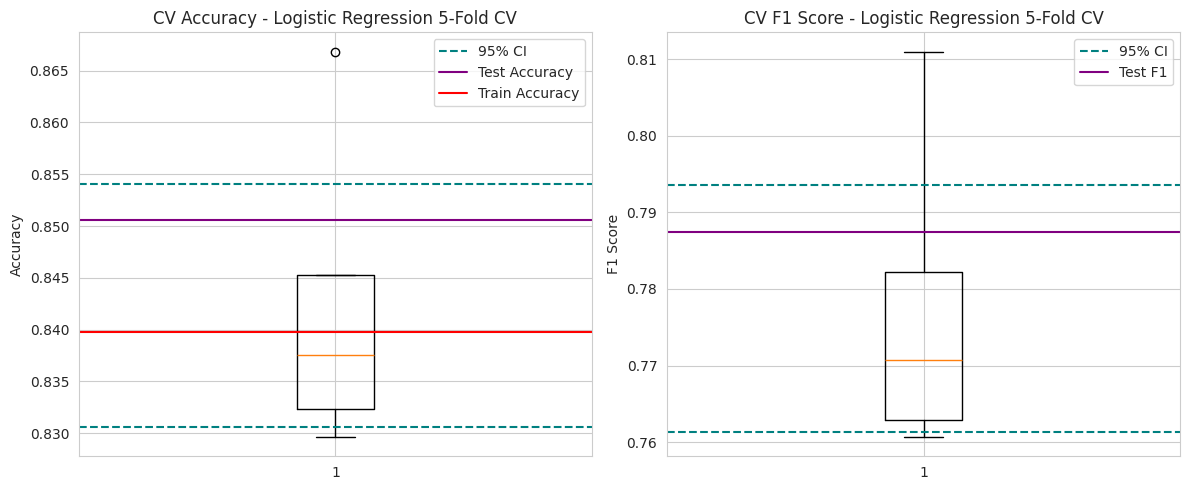

In [127]:
# Get feature names before scaling (from original X)
#feature_names = X.columns  #
feature_names=X_train.columns.tolist()

def RunLogisticRegressionAndCrossValidation(plot_title,
                                            X_train,     
                                            X_test,          
                                            y_train,     
                                            y_test,             
                                            feature_names):
    print('Logistic Regression')
    logisticRegressionResults = RunLogisticRegression(
                                                        plot_title='Lending Club Loan Data',
                                                        X_train=X_train,     
                                                        X_test=X_test,          
                                                        y_train=y_train,     
                                                        y_test=y_test,             
                                                        feature_names=feature_names
                                                    )

    ApplyCrossValidationClassification(
                                        logisticRegressionResults['model'], 
                                        X_train,     
                                        y_train,      
                                        'Logistic Regression 5-Fold CV'
                                    )
    return logisticRegressionResults

logisticRegressionResults = RunLogisticRegressionAndCrossValidation(
                                                                    plot_title='Lending Club Loan Data',
                                                                    X_train=X_train,     
                                                                    X_test=X_test,          
                                                                    y_train=y_train,     
                                                                    y_test=y_test,             
                                                                    feature_names=feature_names
                                                                )

#### Random Forest Classifier ####

Random Forest Classifier
Lending Club Loan Data RANDOM FOREST CLASSIFIER RESULTS
Training Accuracy: 1.0000
Testing Accuracy:  0.8267
Testing F1 Score:  0.7563
Gap:               0.1733

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.8314902580305424, 'recall': 0.9924575738529227, 'f1-score': 0.9048710601719198, 'support': 1591.0}, '1': {'precision': 0.29411764705882354, 'recall': 0.015384615384615385, 'f1-score': 0.029239766081871343, 'support': 325.0}, 'accuracy': 0.826722338204593, 'macro avg': {'precision': 0.562803952544683, 'recall': 0.503921094618769, 'f1-score': 0.4670554131268956, 'support': 1916.0}, 'weighted avg': {'precision': 0.7403388495932727, 'recall': 0.826722338204593, 'f1-score': 0.7563427874270002, 'support': 1916.0}}



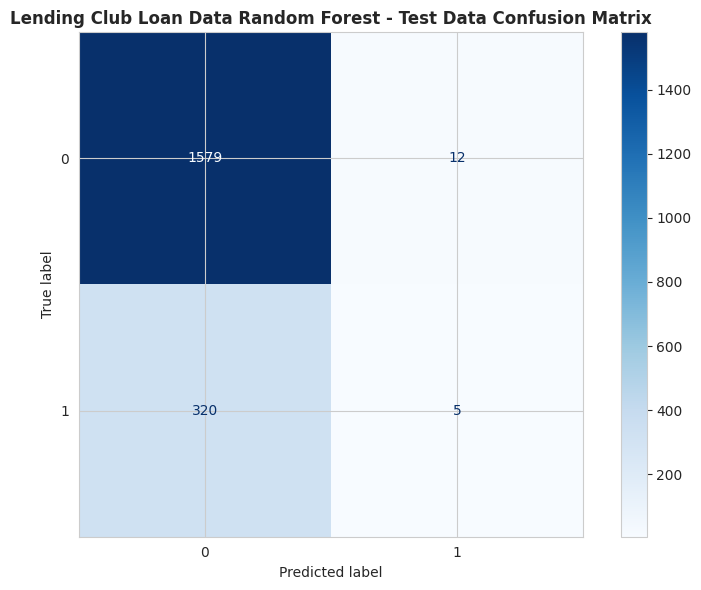


------------------------------------------------------------
Lending Club Loan Data FEATURE IMPORTANCE
------------------------------------------------------------
MonthlyInstallment            0.113151
RevolvingBalance              0.112755
DaysWithCreditLine            0.112124
LogAnnualIncome               0.111973
DebitToIncomeRatio            0.111925
RevolvingUtilRate             0.111368
InterestRate                  0.103631
FicoScore                     0.077859
NumberCreditInquiries         0.054890
CreditPolicy                  0.014838
Delinquencies                 0.014622
Purpose_debt_consolidation    0.014521
Purpose_small_business        0.010890
NegativePublicRecords         0.008860
Purpose_credit_card           0.008216
Purpose_educational           0.006875
Purpose_home_improvement      0.006686
Purpose_major_purchase        0.004814
dtype: float64



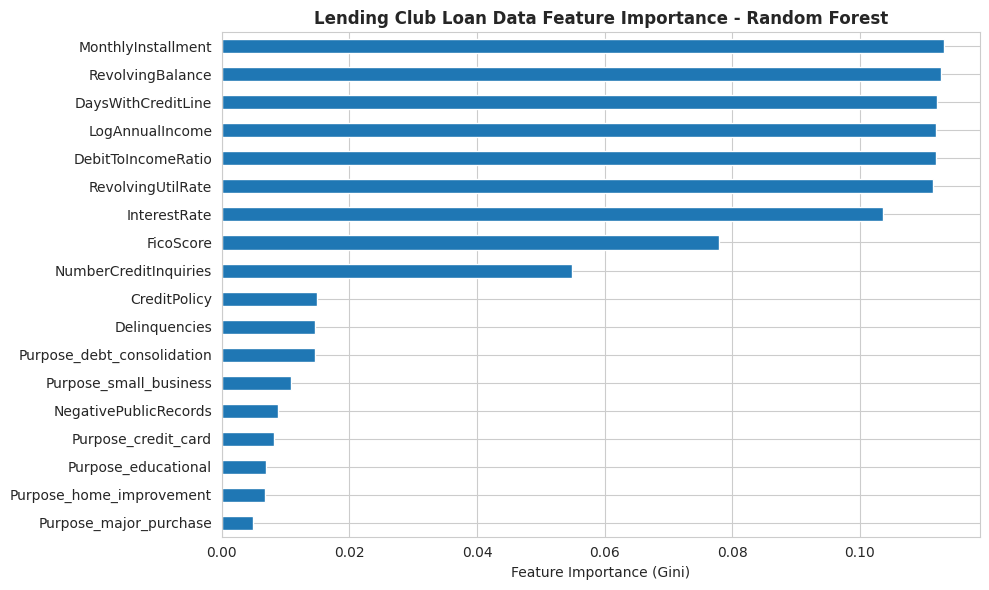

Random Forest 5-Fold CV
Mean CV Accuracy: 0.8416 ± 0.0102
95% CI Accuracy: 0.8313 to 0.8518
Mean CV F1 Score: 0.7763 ± 0.0157
95% CI F1: 0.7606 to 0.7920
Train Accuracy: 0.9998
Test Accuracy: 0.8493
Test F1 Score: 0.7878


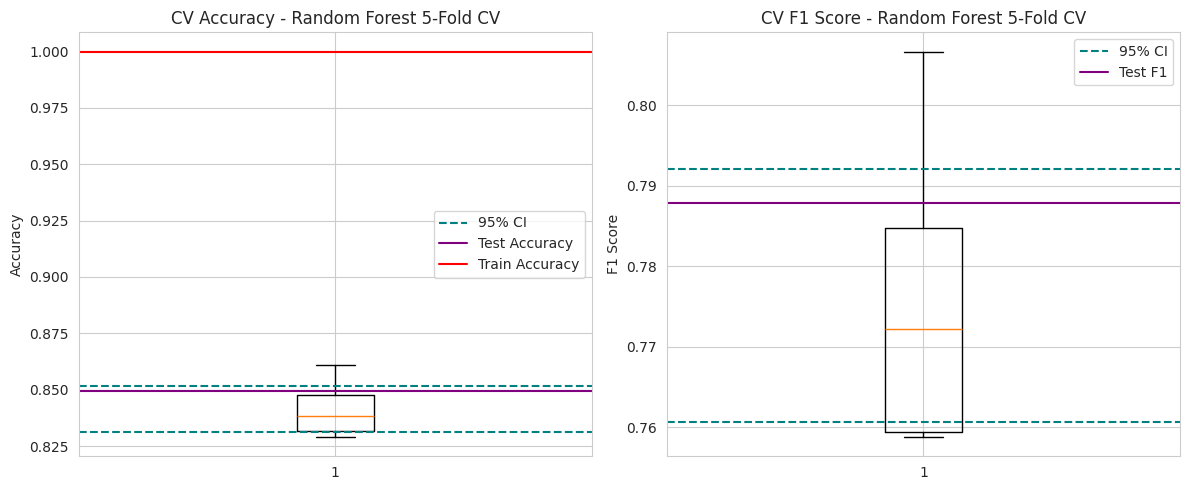

In [128]:
def RunRandomForestClassifierAndCrossValidation(plot_title,
                                                X_train,     
                                                X_test,          
                                                y_train,     
                                                y_test,             
                                                feature_names):
    
    print('Random Forest Classifier')
    randomForestResults = RunRandomForestClassifier(
                                                    plot_title='Lending Club Loan Data',
                                                    X_train=X_train,     
                                                    X_test=X_test,          
                                                    y_train=y_train,     
                                                    y_test=y_test,             
                                                    feature_names=feature_names
                                                )

    # Cross-validation
    ApplyCrossValidationClassification(
                                        randomForestResults['model'], 
                                        X_train,      
                                        y_train,      
                                        'Random Forest 5-Fold CV'
                                    )

    return randomForestResults

randomForestResults = RunRandomForestClassifierAndCrossValidation(
                                                                plot_title='Lending Club Loan Data',
                                                                X_train=X_train,     
                                                                X_test=X_test,          
                                                                y_train=y_train,     
                                                                y_test=y_test,             
                                                                feature_names=feature_names
                                                            )    

#### Gradient Boosting Classifier ####

Gradient Boosting Classifier
Lending Club Loan Data GRADIENT BOOSTING CLASSIFIER RESULTS
Training Accuracy: 0.8524
Testing Accuracy:  0.8283
Testing F1 Score:  0.7590
Gap:               0.0241

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.8324552160168599, 'recall': 0.9930861093651792, 'f1-score': 0.9057036400114646, 'support': 1591.0}, '1': {'precision': 0.3888888888888889, 'recall': 0.021538461538461538, 'f1-score': 0.04081632653061224, 'support': 325.0}, 'accuracy': 0.8282881002087683, 'macro avg': {'precision': 0.6106720524528744, 'recall': 0.5073122854518204, 'f1-score': 0.47325998327103846, 'support': 1916.0}, 'weighted avg': {'precision': 0.7572156250374285, 'recall': 0.8282881002087683, 'f1-score': 0.7589978065661217, 'support': 1916.0}}



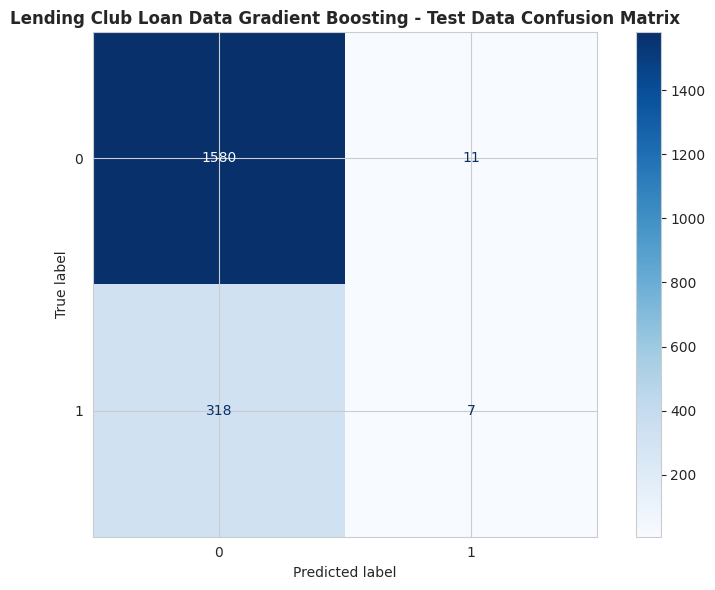


------------------------------------------------------------
Lending Club Loan Data FEATURE IMPORTANCE
------------------------------------------------------------
NumberCreditInquiries         0.125886
LogAnnualIncome               0.110513
InterestRate                  0.102761
MonthlyInstallment            0.102468
FicoScore                     0.098216
CreditPolicy                  0.083631
RevolvingUtilRate             0.082462
RevolvingBalance              0.075572
DebitToIncomeRatio            0.055552
DaysWithCreditLine            0.052730
Purpose_small_business        0.048175
NegativePublicRecords         0.021752
Delinquencies                 0.013531
Purpose_credit_card           0.009098
Purpose_major_purchase        0.007325
Purpose_debt_consolidation    0.005931
Purpose_educational           0.003537
Purpose_home_improvement      0.000859
dtype: float64



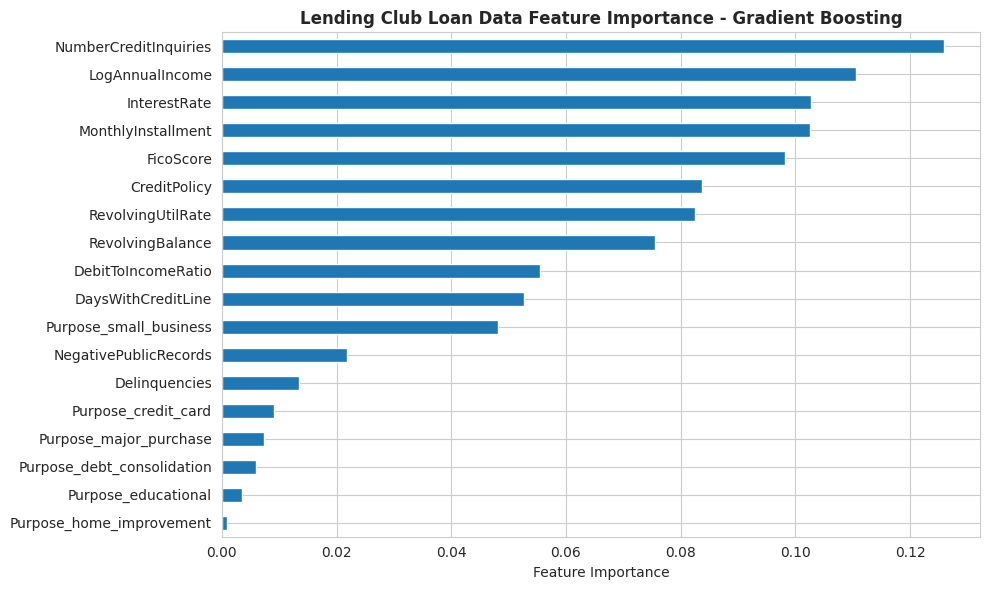

Gradient Boosting 5-Fold CV
Mean CV Accuracy: 0.8425 ± 0.0116
95% CI Accuracy: 0.8309 to 0.8540
Mean CV F1 Score: 0.7789 ± 0.0163
95% CI F1: 0.7625 to 0.7952
Train Accuracy: 0.8535
Test Accuracy: 0.8480
Test F1 Score: 0.7848


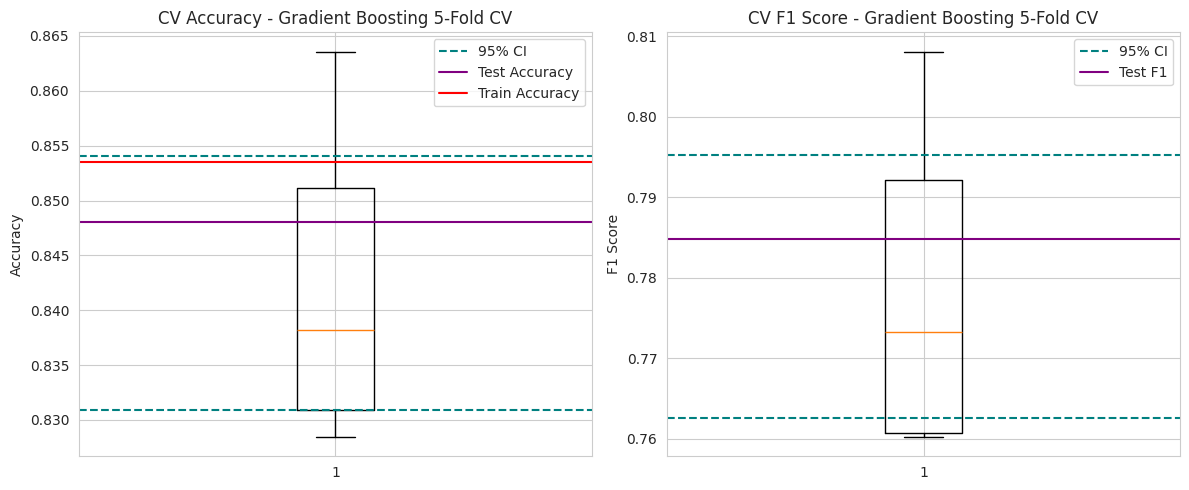

In [129]:
def RunGradientBoostingClassifierAndCrossValidation(plot_title,
                                                    X_train,     
                                                    X_test,          
                                                    y_train,     
                                                    y_test,             
                                                    feature_names):

    print('Gradient Boosting Classifier')
    gradientBoostingResults = RunGradientBoostingClassifier(
                                                            plot_title='Lending Club Loan Data',
                                                            X_train=X_train,     
                                                            X_test=X_test,          
                                                            y_train=y_train,     
                                                            y_test=y_test,             
                                                            feature_names=feature_names
                                                        )

    # Cross-validation
    ApplyCrossValidationClassification(
                                        gradientBoostingResults['model'], 
                                        X_train,      
                                        y_train,      
                                        'Gradient Boosting 5-Fold CV'
                                    )

    return gradientBoostingResults      

gradientBoostingResults = RunGradientBoostingClassifierAndCrossValidation(
                                                                            plot_title='Lending Club Loan Data',
                                                                            X_train=X_train,     
                                                                            X_test=X_test,          
                                                                            y_train=y_train,     
                                                                            y_test=y_test,             
                                                                            feature_names=feature_names
                                                                        )                               

### Deep Learning Model Utility Functions ###
Build a Feedforward Neural Network - Multi-Layer Perceptron (MLP)</br>
Sequentially stack the layers one after another. </br>
</br>
The dataset is a fairly simple data set with 19 (including encoded) features and under 10000 rows of data.</br>
It is simple enough that other Deep Learning (DL) methods (AutoEncoder, Transformer) would be overkill</br>

#### MLP Utility Functions ####
These functions were taken directly from George's class demo/examples.</br>

#### Observations and Play by Play ####
- **Phase 1: 16->32->64->32->16**
    - I started with model #2, and I found that the sequential model did not perform well.</br>
        - The model did not seem to learn well/consistently
        - The loss/accuracy curves were jagged an inconsistent
        - There were significant gaps between test and validation data
        - It appeared to overfit.
        - Maybe the model is too complex for the relatively small dataset (# of rows/# of features)
    - **Action**: Try a simpler model with less dense layers
- **Phase 2: 16->32->16**
    - Started with a simpler model, but model still not performing well
    - **Action**: Add **Dropout** layers to reduce overfitting (we had no **Dropout** at all)
- **Phase 3: 16->D->32->D->16->D**
    - Dropouts with unscaled, imbalanced classes made results much worse - didn't learn minority class at all.</br>
    Best suited for Feature Engineered dataset.
    - **Action** - add condition parameter add_dropouts so it can be turned off for raw data/on for feature engineered
- **Phase 3: 8->16->8**
    - Added conditional dropouts and reduced dropout rate to 0.2 to take dataset/feature size into account.</br>
    - Try simplest model yet and see if that affects results - small data set/small feature set
    - **Model TOO SIMPLE**
    - **Action** - Going back Phase 2 Model for minimally Feature Engineered data.
    - **Action** - Reduce comparison threshold to account for minority class
- **Conclusion**
    - Phase 2 (16-32-16) with threshold of 0.2 and no dropouts gave the best results for</br> 
    Sequential model using Unfeature Engineered dataset

- **Next Steps**
    - For Feature Engineered dataset with Sequential model use:
        - Use Phase 2 (16-32-16) model
        - Hyperparameter tuning (batch_size, learning_rate, threshold)
        - Try with/without dropouts
        - Varied threshold

In [ ]:
# Wraps Keras .predict() to return class labels (0/1) instead of probabilities, matching scikit-learn's .predict() output format.
class KerasClassifierWrapper:
    def __init__(self, keras_model):
        self.model = keras_model
    def predict(self, X):
        return (self.model.predict(X).flatten() >= 0.5).astype(int)
    def fit(self, X, y):
        self.model.fit(X, y)
        return self    


def MakeCallbacks(
                    learning_rate: float,
                    batch_size: int,
                    patience: int = 10,
                ) -> Tuple[keras.callbacks.EarlyStopping, keras.callbacks.TensorBoard]:

    early_stopping = keras.callbacks.EarlyStopping(
                                                    monitor='val_loss',
                                                    patience=patience,
                                                    restore_best_weights=True,
                                                    verbose=verbose
                                                )

    run_log_dir = f'{log_dir}/lr_{learning_rate}_bs_{batch_size}'
    Path(run_log_dir).mkdir(parents=True, exist_ok=True)

    tensorboard_callback = keras.callbacks.TensorBoard(
                                                        log_dir=run_log_dir,
                                                        histogram_freq=1,
                                                        write_graph=False
                                                    )

    return early_stopping, tensorboard_callback


def BuildModel(input_dim, learning_rate: float=0.01, add_dropouts=False) -> keras.Sequential:

    # Model #1
    # if add_dropouts == True:
    #     model = keras.Sequential([
    #         layers.Input(shape=(input_dim,)),
    #         layers.Dense(16, activation='relu'),
    #         layers.Dropout(0.2),
    #         layers.Dense(32, activation='relu'),
    #         layers.Dropout(0.2),
    #         layers.Dense(16, activation='relu'),
    #         layers.Dense(1, activation='sigmoid')
    #     ])
    #     print('Sequential Model using Dropouts')
    # else:
    #     model = keras.Sequential([
    #         layers.Input(shape=(input_dim,)),
    #         layers.Dense(16, activation='relu'),
    #         layers.Dense(32, activation='relu'),
    #         layers.Dense(16, activation='relu'),
    #         layers.Dense(1, activation='sigmoid')
    #     ])
    #     print('Sequential Model NOT using Dropouts')

    # print()

    # Model #2
    # Something more complex
    # model = keras.Sequential([
    #                             layers.Input(shape=(input_dim,)),
    #                             layers.Dense(16, activation='relu'),
    #                             layers.Dense(32, activation='relu'),
    #                             layers.Dense(64, activation='relu'),
    #                             layers.Dense(32, activation='relu'),
    #                             layers.Dense(16, activation='relu'),
    #                             layers.Dense(1, activation='sigmoid')
    #                         ])

    # Model #3
    # Try simplest model
    if add_dropouts == True:
        model = keras.Sequential([
                                    layers.Input(shape=(input_dim,)),
                                    layers.Dense(8, activation='relu'),
                                    layers.Dropout(0.2),
                                    layers.Dense(16, activation='relu'),
                                    layers.Dropout(0.2),                                    
                                    layers.Dense(8, activation='relu'),
                                    layers.Dense(1, activation='sigmoid')
                                ])                                
        print('Sequential Model using Dropouts')
    else:
        model = keras.Sequential([
                                    layers.Input(shape=(input_dim,)),
                                    layers.Dense(8, activation='relu'),
                                    layers.Dense(16, activation='relu'),
                                    layers.Dense(8, activation='relu'),
                                    layers.Dense(1, activation='sigmoid')
                                ])
        print('Sequential Model NOT using Dropouts')

    print()

    model.compile(
                    optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
                    loss='binary_crossentropy',
                    metrics=['accuracy']
                )

    return model


def TrainModel(
                model: keras.Sequential,
                X_train=None,
                y_train=None,
                epochs: int=200,
                batch_size: int=128,
                validation_split: Optional[float]=0.2,
                class_weights=None,
                callbacks: Tuple[keras.callbacks.EarlyStopping, keras.callbacks.TensorBoard]=None
            ) -> Tuple[keras.Sequential, keras.callbacks.History]:

    # Remove class_weight='balanced' parameter
    history = model.fit(
                            X_train,
                            y_train,
                            epochs=epochs,
                            batch_size=batch_size,
                            validation_split=validation_split,
                            class_weight=None,
                            callbacks=callbacks,
                            verbose=verbose
                        )

    return model, history


def RunSequentialModel(plot_title=None,
                       X_train=None, 
                       X_test=None,
                       y_train=None, 
                       y_test=None,
                       feature_names=None,
                       learning_rate=0.01,
                       epochs=200,
                       batch_size=128,
                       patience=10,
                       apply_scaling=False,
                       class_weights=None,
                       threshold=0.5
                       add_dropouts=False):

    if feature_names is None:
        feature_names = [f'Feature_{i}' for i in range(X_train.shape[1])]

    # Optional scaling
    if apply_scaling:
        scaler = StandardScaler()
        X_train_used = scaler.fit_transform(X_train)
        X_test_used = scaler.transform(X_test)
    else:
        X_train_used = X_train
        X_test_used = X_test

    # Build model
    model = BuildModel(input_dim=X_train_used.shape[1], 
                       learning_rate=learning_rate,
                       add_dropouts=add_dropouts)
    
    print('Sequential Model Architecture:')
    print(model.summary())

    # Callbacks
    early_stopping, tensorboard_callback = MakeCallbacks(
                                                            learning_rate=learning_rate,
                                                            batch_size=batch_size,
                                                            patience=patience
                                                        )

    # Train using TrainModel function
    model, history = TrainModel(
                                    model=model,
                                    X_train=X_train_used,
                                    y_train=y_train,
                                    epochs=epochs,
                                    batch_size=batch_size,
                                    validation_split=0.2,
                                    class_weights=class_weights,
                                    callbacks=[early_stopping, tensorboard_callback]
                                )

    # Predictions
    y_pred_train = (model.predict(X_train_used).flatten() >= threshold).astype(int)
    y_pred_test = (model.predict(X_test_used).flatten() >= threshold).astype(int)

    # Metrics
    train_accuracy = accuracy_score(y_train, y_pred_train)
    test_accuracy = accuracy_score(y_test, y_pred_test)
    test_f1 = f1_score(y_test, y_pred_test, average='weighted')

    print('=' * 60)
    print(f'{plot_title} KERAS SEQUENTIAL MODEL RESULTS')
    print('=' * 60)
    print(f'Scaling: {apply_scaling}')
    print(f'Class Weights: {class_weights}')
    print(f'Training Accuracy: {train_accuracy:.4f}')
    print(f'Testing Accuracy:  {test_accuracy:.4f}')
    print(f'Testing F1 Score:  {test_f1:.4f}')
    print(f'Gap:               {train_accuracy - test_accuracy:.4f}')
    print()

    # Classification Report
    print('-' * 60)
    print(f'{plot_title} TEST DATA - Classification Report')
    print('-' * 60)
    report = classification_report(y_test, y_pred_test, output_dict=True)
    print(report)
    print()

    # Confusion Matrix
    fig, ax = plt.subplots(figsize=(8, 6))
    ConfusionMatrixDisplay.from_predictions(y_test, y_pred_test, ax=ax, cmap='Blues')
    plt.title(f'{plot_title} Keras Sequential - Test Data Confusion Matrix', fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

    # Training History Plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history.history['loss'], label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title('Loss Curve', fontweight='bold')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history.history['accuracy'], label='Train Accuracy')
    axes[1].plot(history.history['val_accuracy'], label='Val Accuracy')
    axes[1].set_title('Accuracy Curve', fontweight='bold')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.suptitle(f'{plot_title} Training History', fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print()

    return {
                'model': KerasClassifierWrapper(model),
                'train_accuracy': train_accuracy,
                'test_accuracy': test_accuracy,
                'f1_score': test_f1,
                'X_train': X_train_used,
                'X_test': X_test_used,
                'y_train': y_train,
                'y_test': y_test,
                'test_predictions': y_pred_test,
                'report': report,
                'history': history
            }

#### Train the Sequential Model ####
For this initial run against minimally engineered feature data, we will only complete 1 run of the sequential model </br>
using default values for epochs, batch_size and learning rate.

Sequential Model - Feed-Forward NN
Sequential Model NOT using Dropouts

Sequential Model Architecture:


Model: "sequential_60"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_240 (Dense)               │ (None, 8)              │           336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_241 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_242 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_243 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 625 (2.44 KB)

 Trainable params: 625 (2.44 KB)

 Non-trainable params: 0 (0.00 B)

None


240/240 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.8295
Testing Accuracy:  0.8184
Testing F1 Score:  0.7804
Gap:               0.0112

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.8489208633093526, 'recall': 0.9533871970167807, 'f1-score': 0.8981264637002342, 'support': 1609.0}, '1': {'precision': 0.3119266055045872, 'recall': 0.11074918566775244, 'f1-score': 0.16346153846153846, 'support': 307.0}, 'accuracy': 0.8183716075156576, 'macro avg': {'precision': 0.5804237344069698, 'recall': 0.5320681913422666, 'f1-score': 0.5307940010808864, 'support': 1916.0}, 'weighted avg': {'precision': 0.7628784639638083, 'recall': 0.8183716075156576, 'f1-score': 0.7804113634662678, 'support': 1916.0}}



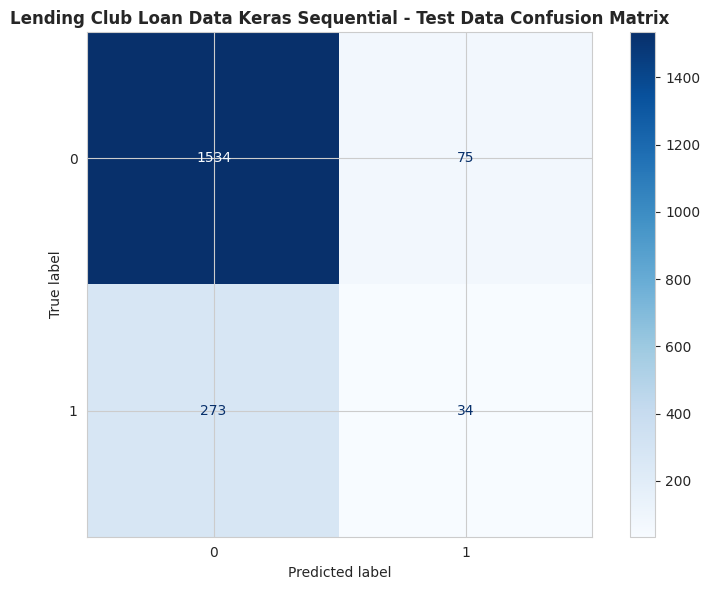

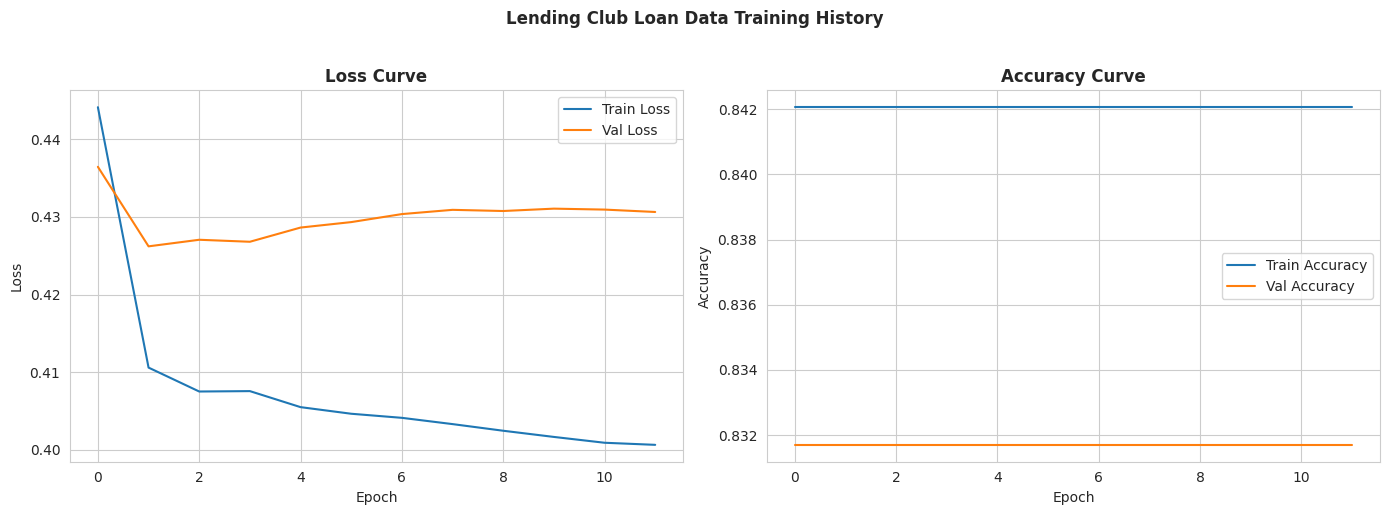


192/192 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8385 - loss: 0.4229
192/192 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
48/48 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Cross-validation skipped.



{'cv_accuracy': None, 'cv_f1': None}

In [ ]:
print('Sequential Model - Feed-Forward NN')
sequentialResults = RunSequentialModel(
                                        plot_title='Lending Club Loan Data',
                                        X_train=X_train,     
                                        X_test=X_test,          
                                        y_train=y_train,     
                                        y_test=y_test,             
                                        feature_names=feature_names,
                                        threshold=0.2,
                                        add_dropouts=False
                                    )

# Cross-validation
ApplyCrossValidationClassification(
                                    sequentialResults['model'], 
                                    X_train,      
                                    y_train,      
                                    'D',
                                    apply_crossvalidation=False
                                )

### Model With Unfeature Engineered Data Analysis ###
Plots definitely highlight the class imbalance.

**Logistic Regression (ML)**
- Most Important Features:
    - Purpose_small_business        6.108006e-01
    - Purpose_credit_card           5.557489e-01
    - CreditPolicy                  4.973941e-01
    - NegativePublicRecords         3.354003e-01
    - Purpose_debt_consolidation    2.444413e-01
- Confusion Matrix
    - Reasonably good at identifying TN (NDO=0)
    - Not very good at identifying TP (ND0=1) - 50/50
    - FP (Type 1 Errors) - 447
    - FN (Type 2 Errors) - 157
Box Plot Analysis
Accuracy
F1 Score

**Random Forest Classifier (ML)**
- Most Important Features:
    - InterestRate                  0.115167
    - DaysWithCreditLine            0.113023
    - LogAnnualIncome               0.110696
    - RevolvingUtilRate             0.108306
    - RevolvingBalance              0.108300
- Confusion Matrix
    - Very good at identifying TN (NDO=0)
    - Very good at identifying TP (ND0=1) 
    - FP (Type 1 Errors) - 6
    - FN (Type 2 Errors) - 322
Only 328 misclassified predictions - Overfitting??
Box Plot Analysis
Accuracy
F1 Score

**Gradient Boosting Classifier (ML)**
- Most Important Features:
    - NumberCreditInquiries         0.125886
    - LogAnnualIncome               0.110513
    - InterestRate                  0.102761
    - MonthlyInstallment            0.102468
    - FicoScore                     0.098216
- Confusion Matrix
    - Very good at identifying TN (NDO=0)
    - Very good at identifying TP (ND0=1) 
    - FP (Type 1 Errors) - 11
    - FN (Type 2 Errors) - 318
Only 329 misclassified predictions - Overfitting??
Slightly less than Random Forest Classifier
Box Plot Analysis
Accuracy
F1 Score

**Sequential Model (DL)**
- Confusion Matrix
    - Perfect at identifying TN (NDO=0)
    - Can't identify TP (ND0=1) - zero (0)
    - FP (Type 1 Errors) - 0
    - FN (Type 2 Errors) - 325
- Loss Curve
    - Train starts high, drops quickly
    - Validation starts low and stays low
    - They both stabilize after epch 5
- Accuracy Curve
    - Train/Validation rise quickly
    - Train rises quickly, has some derivations and stablizes around 7 epochs
    - Gap stays consistent between train/validation
    - Validation spikes at 1 epoch and stays consistent

### Model Comparisons against **Unfeature Engineered Data** ###
Compare Results of LogisticRegression, RandomForestClassifier, GradientBoostingClassifier, Sequential Models</br>
This was done directly using the functionality from the Unit End 3 project.

Double check the Classification Results


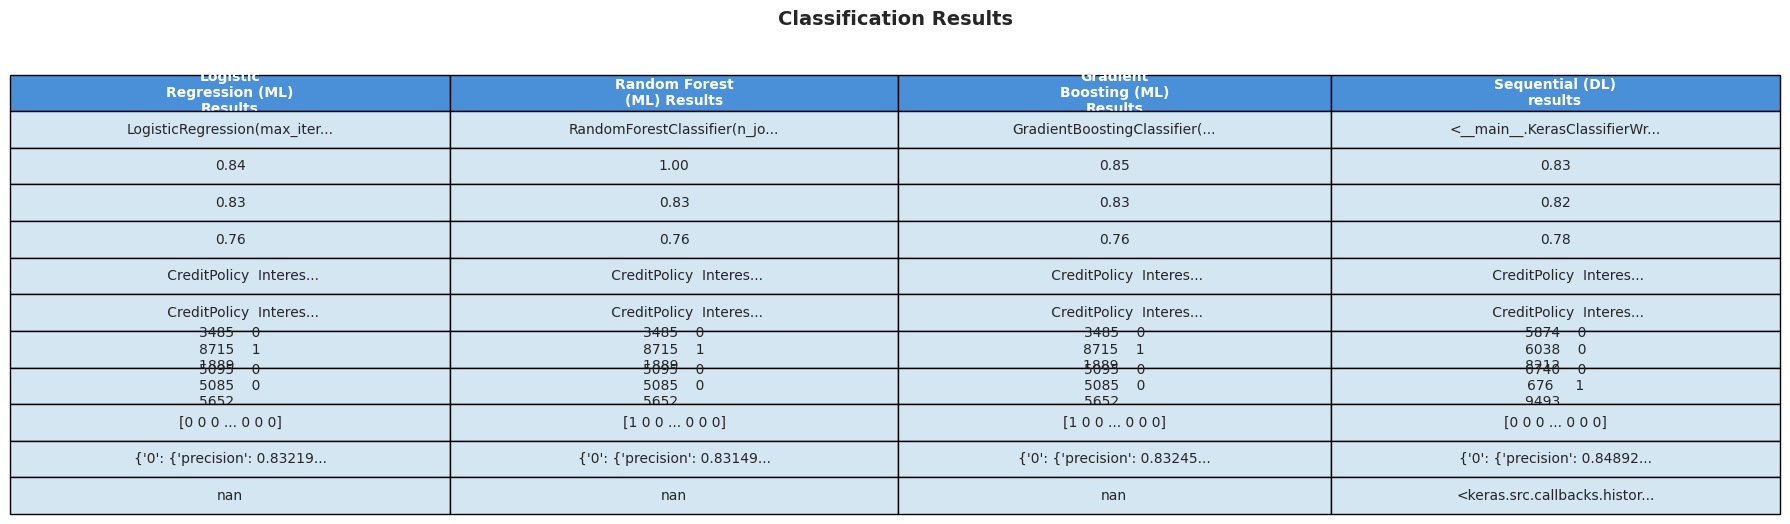



60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Classification Model Results
                                  Train Accuracy  Test Accuracy  \
Model                                                             
Logistic Regression (ML) Results          0.8418         0.8288   
Random Forest (ML) Results                1.0000         0.8267   
Gradient Boosting (ML) Results            0.8524         0.8283   
Sequential (DL) results                   0.8295         0.8184   

                                  Balanced Accuracy  Precision  Recall  \
Model                                                                    
Logistic Regression (ML) Results             0.5079     0.7656  0.8293   
Random Forest (ML) Results                   0.5110     0.7628  0.8283   
Gradient Boosting (ML) Results               0.5085     0.7503  0.8262   
Sequential (DL) results                      0.5000     0.7052  0.8398   

                                  F1 Score     Gap  
Model                        

/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


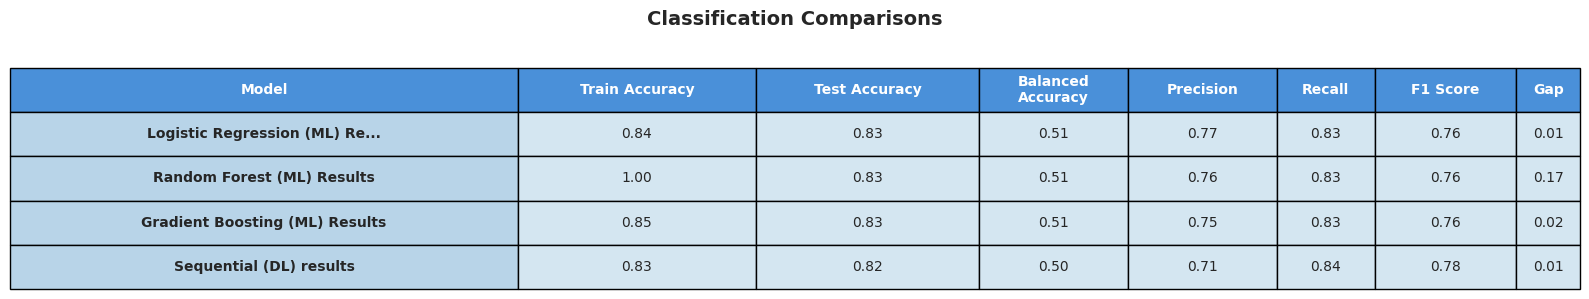



60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


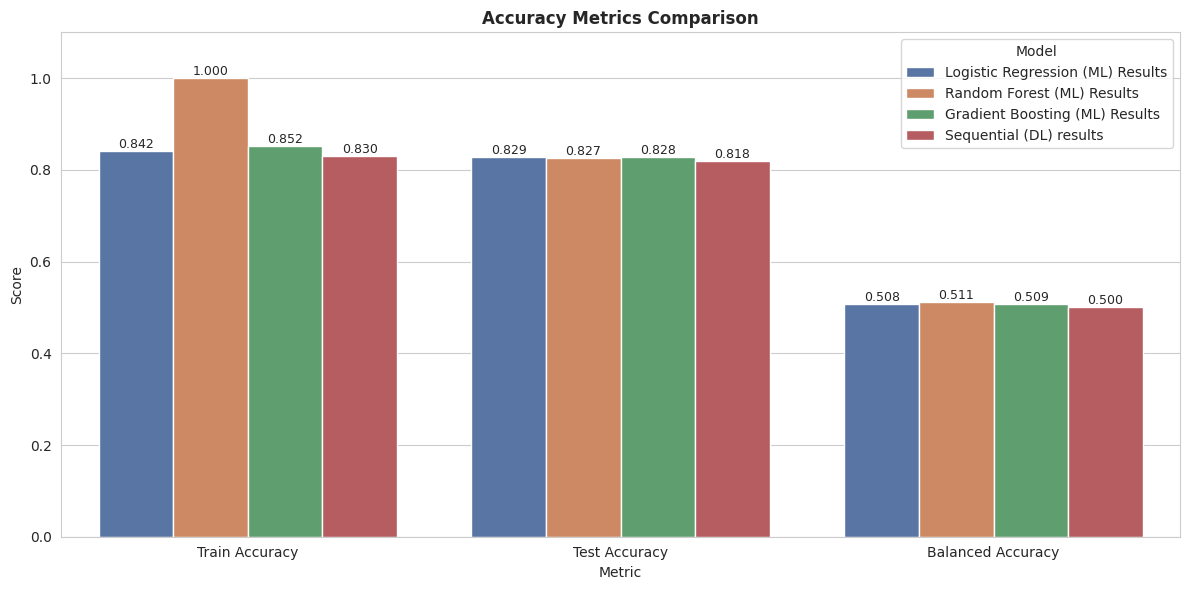


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


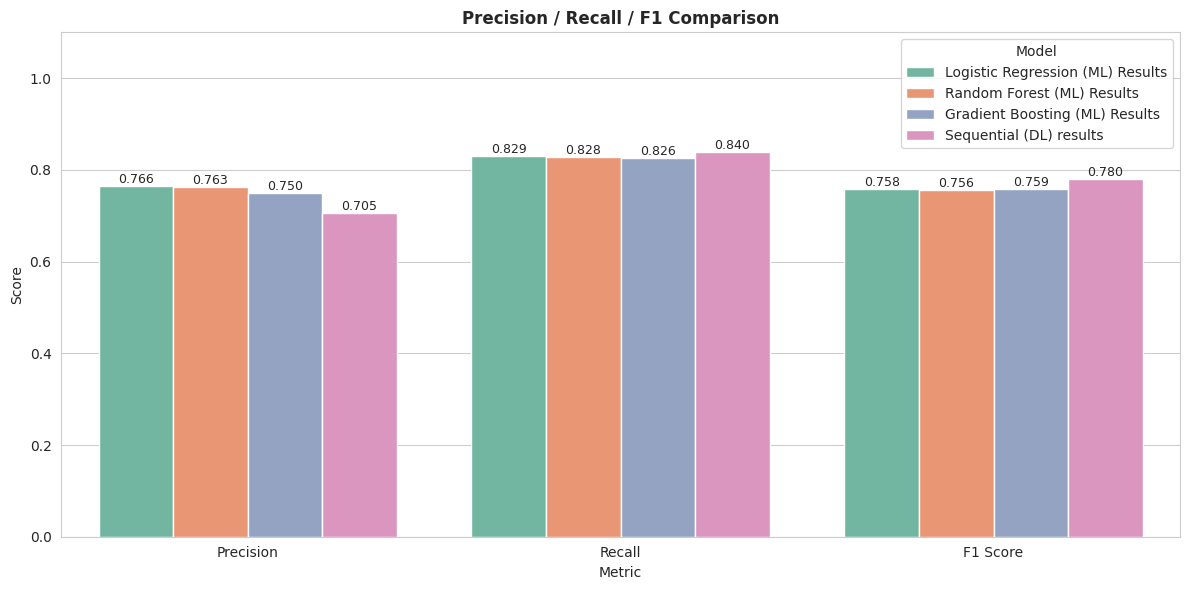

/tmp/ipykernel_1251/4279958838.py:485: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gap_data, x='Model', y='Gap', palette='deep')


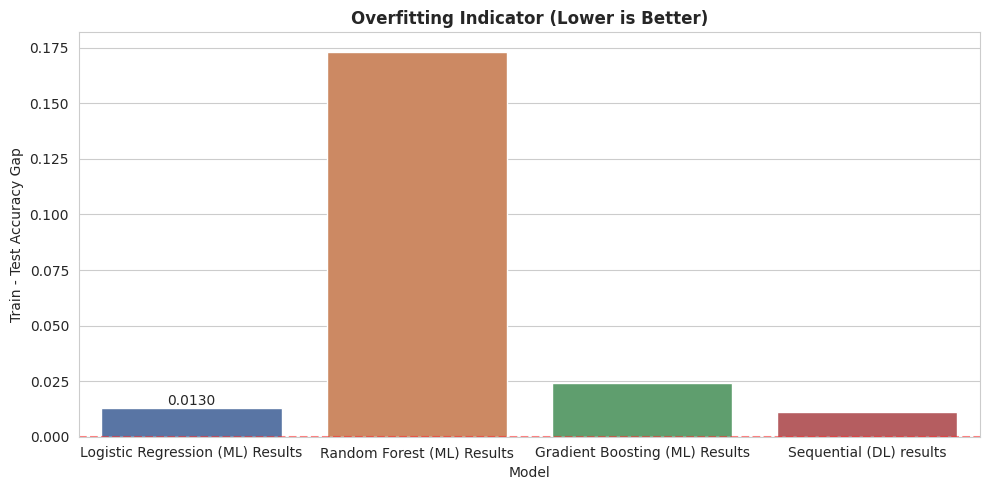


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


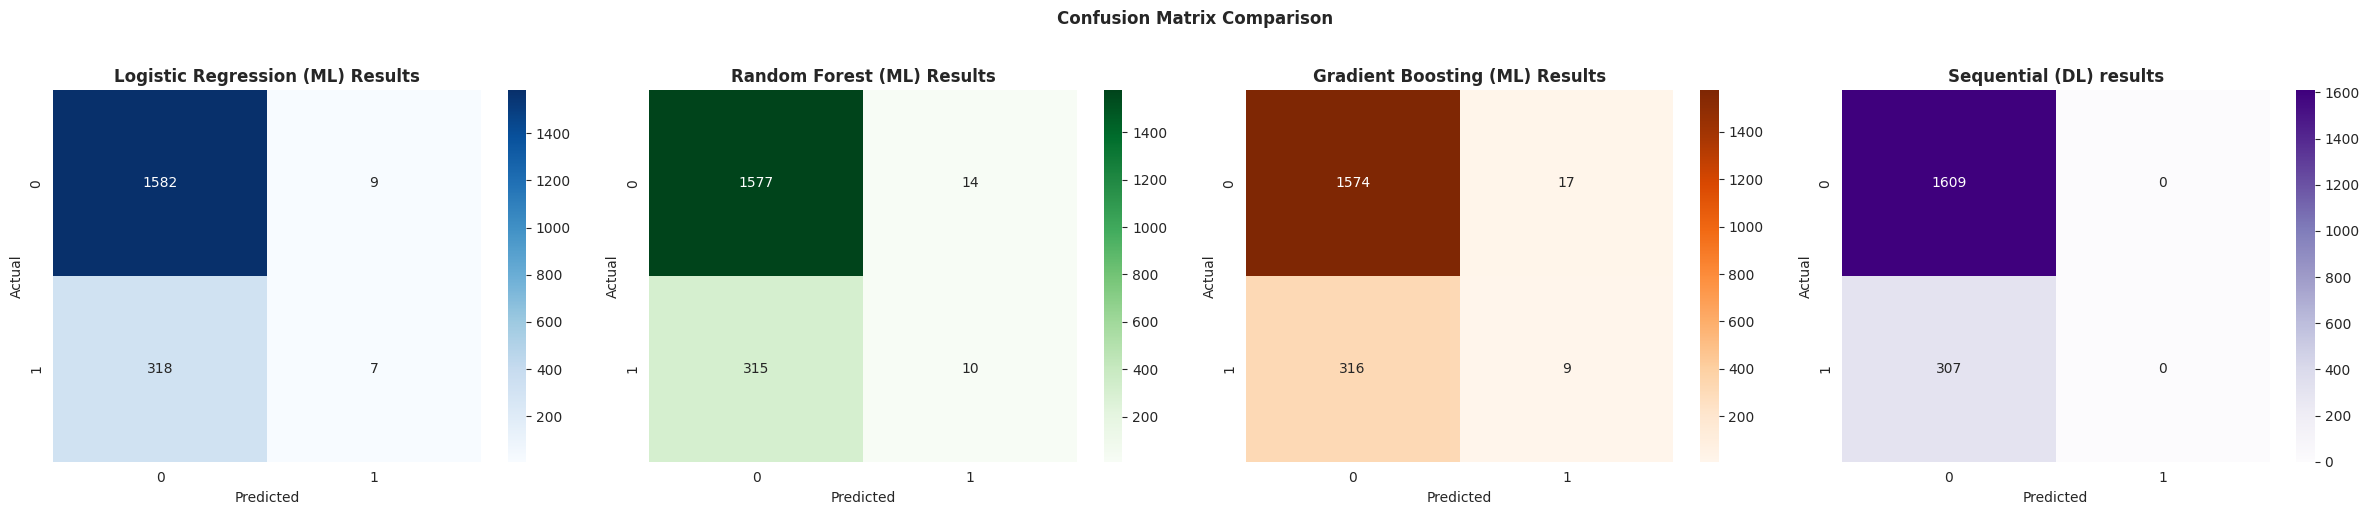

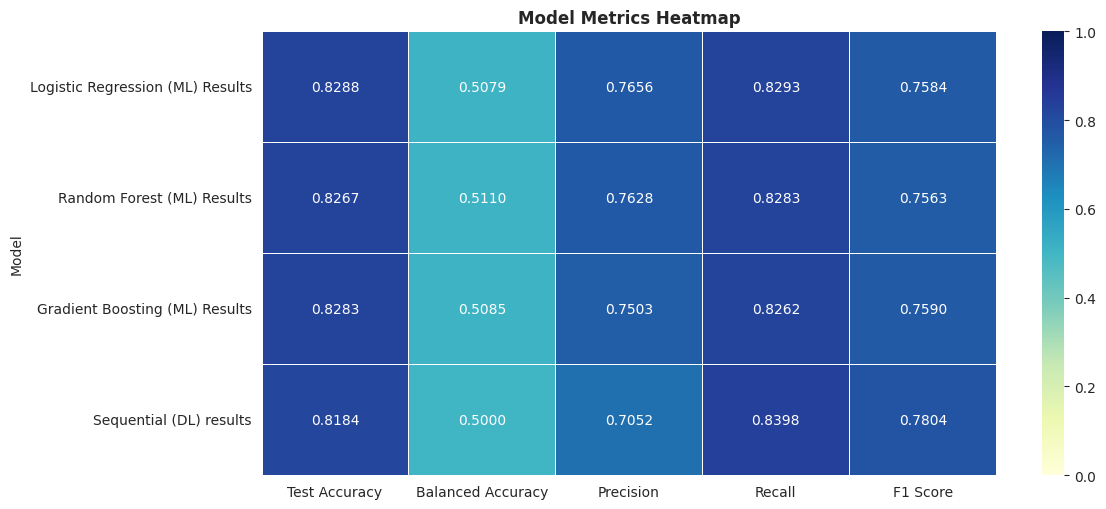

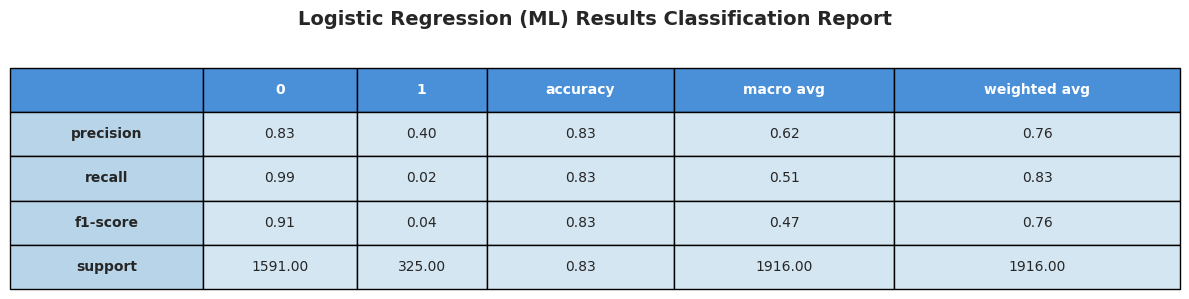

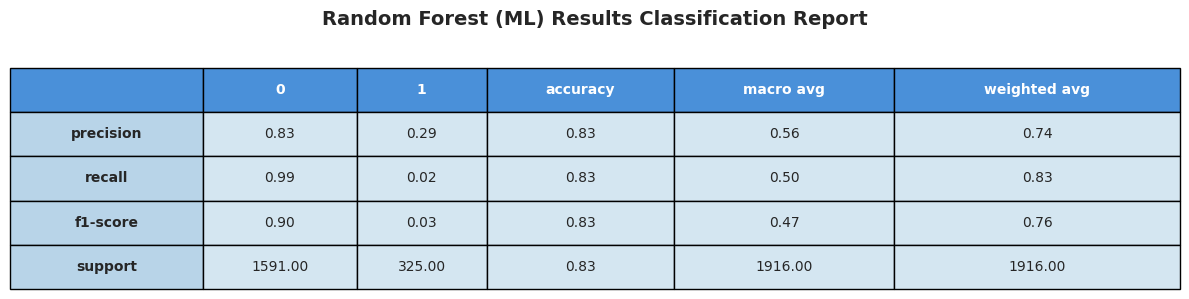

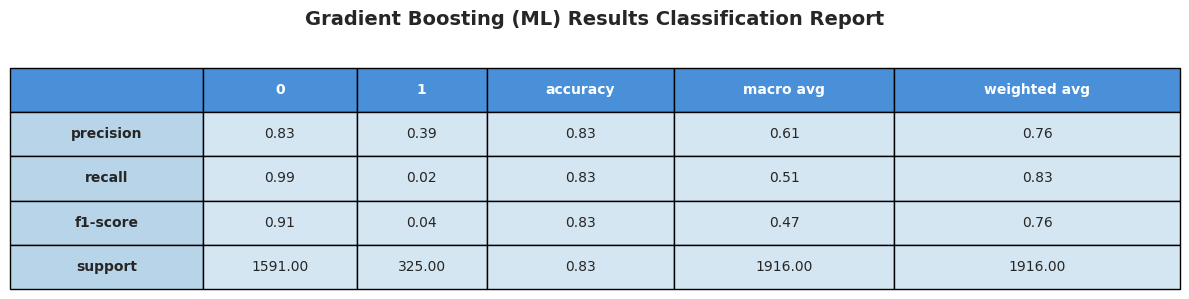

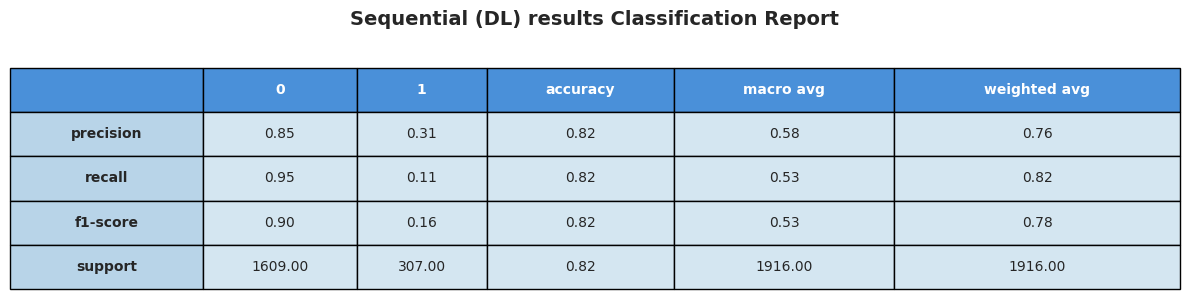

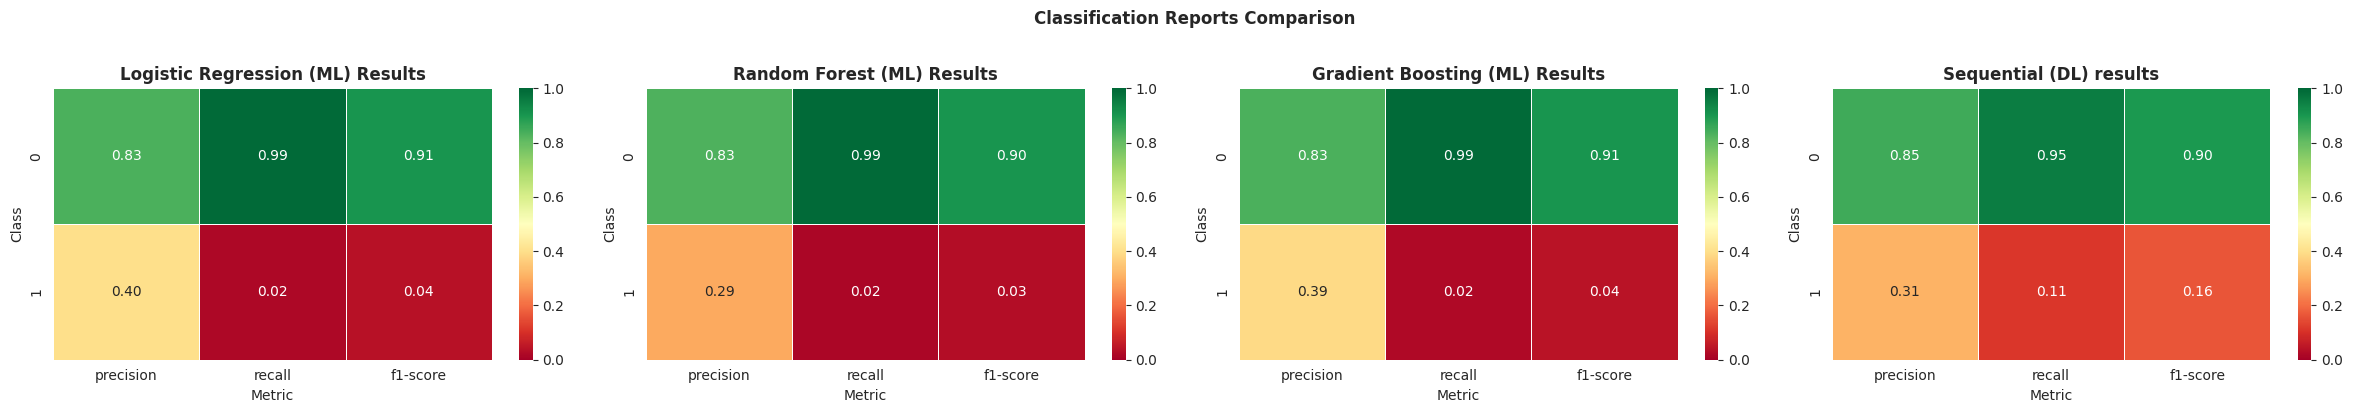

In [206]:
# Display Comparisons

results_dict = {
    'Logistic Regression (ML) Results': logisticRegressionResults,
    'Random Forest (ML) Results': randomForestResults,
    'Gradient Boosting (ML) Results': gradientBoostingResults,
    'Sequential (DL) results': sequentialResults
}

print('Double check the Classification Results')
df_Results = pd.DataFrame(results_dict)
DisplayTable(df_Results, 'Classification Results')

CompareClassificationResults(results_dict, title='Classification Model Results')
print()
print()

#### Model Performance Comparison Observations ####
- **Highest accuracy**: Sequential / Random Forest
- **Highest Minority Detection**: Logistic Regression
- **Largest Train–Test Gap**: Random Forest (**overfitting**)
- **Lowest Minority Recall**: Sequential (DL)

**Based on this class imbalanced dataset, Logistic Regression is the best performing model.**
- It has reasonable accuracy
- It does not overfit
- It is the only model that detects the minority class

## **3. Data Wrangling and Feature Engineering** ##

### **Missing Values and Imputation** ###
Not required

##### Trim Categorical Features #####

In [207]:
# Trim Data
obj_cols = df_LendingClub.select_dtypes(include='object').columns
df_LendingClub[obj_cols] = df_LendingClub[obj_cols].apply(lambda col: col.str.strip())

##### New Feature Creation #####
1. Create new ratio based features
    - Monthly Installment to Income ratio
    - Revolving Balance to Income ratio
2. Bin Fico scores, then one hot encode </br>(To translate string bin to integer values for models)

In [208]:
# Create new ratio based features
df_LendingClub['InstallmentToIncomeRatio'] = df_LendingClub['MonthlyInstallment'] / (np.exp(df_LendingClub['LogAnnualIncome']) / 12)
df_LendingClub['RevolvingBalanceToIncomeRatio'] = df_LendingClub['RevolvingBalance'] / np.exp(df_LendingClub['LogAnnualIncome']) 

# Bin FICO scores
df_LendingClub['fico_bin'] = pd.cut(df_LendingClub['FicoScore'], 
                                    bins=[0, 650, 700, 750, 900], 
                                    labels=['Poor', 'Fair', 'Good', 'Excellent'])

# One-Hot-Encode binned FICO score - no implied ordinal ranking - automatically drops from dataframe
df_LendingClub = pd.get_dummies(df_LendingClub, columns=['fico_bin'], drop_first=True, dtype=int)

### **Data Type Conversion** ###
For OS memory performance and model efficiency, convert to more efficient data types.

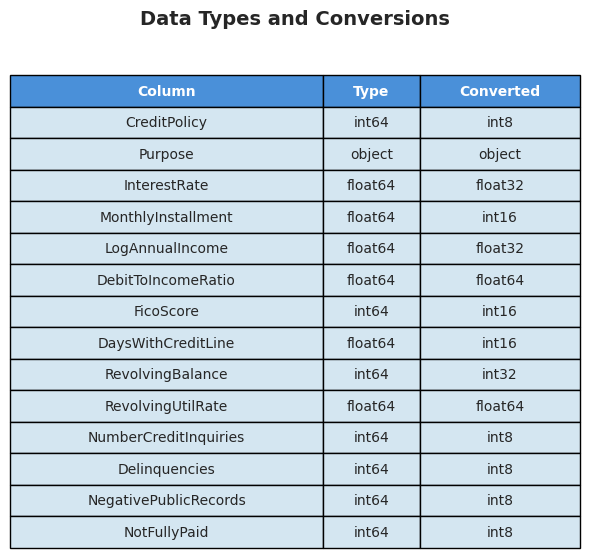




Converted Data Columns


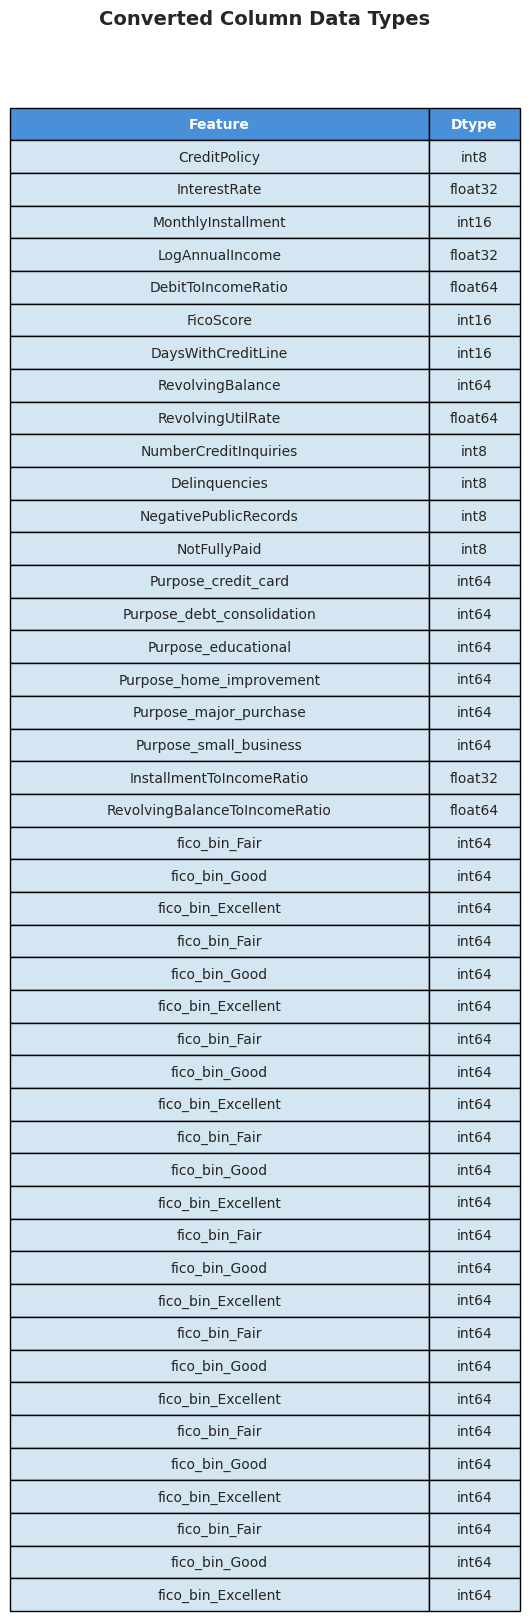

In [209]:
#PrintDataFrameStatistics(df_LendingClub)

features = ['CreditPolicy', 'Purpose', 'InterestRate','MonthlyInstallment', 'LogAnnualIncome', 'DebitToIncomeRatio', 'FicoScore', 
            'DaysWithCreditLine', 'RevolvingBalance', 'RevolvingUtilRate', 'NumberCreditInquiries', 'Delinquencies', 'NegativePublicRecords', 'NotFullyPaid' ]
# Features, Types and Data Type Conversion Targets..
df_types = pd.DataFrame({
                    'Column': features,
                    'Type': [
                        'int64', 'object', 'float64', 'float64', 'float64', 'float64', 'int64', 
                        'float64', 'int64', 'float64', 'int64', 'int64', 'int64', 'int64'
                    ],
                    'Converted': [
                        'int8', 'object', 'float32', 'int16', 'float32', 'float64', 'int16', 
                        'int16', 'int32', 'float64', 'int8', 'int8', 'int8', 'int8'
                    ]
                })


#print(df_types)

DisplayTable(df_types, table_title='Data Types and Conversions', max_cell_length=60)
print()


def PerformDataConversion(df_target, display_output=False):

    # Convert Floats
    float_columns = ['InterestRate', 'LogAnnualIncome']
    df_target[float_columns] = df_target[float_columns].astype('float32')

    # Convert Int64 to Int16
    int_columns = ['FicoScore']
    df_target[int_columns] = df_target[int_columns].astype('int16')

    # Convert Int64 to Int8
    int_columns = ['CreditPolicy', 'NumberCreditInquiries', 'Delinquencies', 'NegativePublicRecords', 'NotFullyPaid']
    df_target[int_columns] = df_target[int_columns].astype('int8')

    # Convert (Round) Float to Int16
    int_columns = ['MonthlyInstallment', 'DaysWithCreditLine']
    df_target[int_columns] = df_target[int_columns].round(0).astype('int16')

    if display_output == True:
        print('Converted Data Columns')

        df_info = pd.DataFrame({
                                'Feature': df_target.columns,
                                'Dtype': df_target.dtypes.values
                                }).reset_index(drop=True)
        DisplayTable(df_info, 'Converted Column Data Types')
    
    return df_target

df_LendingClub = PerformDataConversion(df_LendingClub, display_output=True)
#PrintDataFrameStatistics(df_LendingClub)

### Feature Normalization ###
Address the Distribution Normalization issued identified during EDA
- Apply Yeo-Johnson to the following continuous (float) features </br>
Several features are right-skewed, yeo-johnson finds best transform automatically
    - MonthlyInstallment
    - DaysWithCreditLine 
    - RevolvingBalance
    - FicoScore
    - AnnualIncome 
- Apply Standard Scaler to the following numeric columns:</br>
Transforms remaining (non-skewed) features to the same scale 
    - InterestRate
    - DebitToIncomeRatio
    - RevolvingUtilRate
    - LogAnnualIncome 

In [210]:
# Break down of columns to be transformed
yeo_johnson_columns = ['MonthlyInstallment', 'DaysWithCreditLine', 'RevolvingBalance', 'FicoScore']

standard_scaler_columns = ['InterestRate', 'DebitToIncomeRatio', 'RevolvingUtilRate',
                            'InstallmentToIncomeRatio', 'RevolvingBalanceToIncomeRatio']


# New features/columns added so redo the train/test split
X = df_LendingClub.drop('NotFullyPaid', axis=1)
y = df_LendingClub['NotFullyPaid']

# stratify=y guarantees train/test have some class proportions as original dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=315, stratify=y)

# Yeo-Johnson on skewed continuous features
pt = PowerTransformer(method='yeo-johnson')
X_train[yeo_johnson_columns] = pt.fit_transform(X_train[yeo_johnson_columns])
X_test[yeo_johnson_columns] = pt.transform(X_test[yeo_johnson_columns])

# StandardScaler on remaining continuous features
scaler = StandardScaler()
X_train[standard_scaler_columns] = scaler.fit_transform(X_train[standard_scaler_columns])
X_test[standard_scaler_columns] = scaler.transform(X_test[standard_scaler_columns])


#### Plot Distributions of Normalized Features ####
Replot the distributions after normalization and scaling has been applied</br>
Since the train/test split has already been applied, plot the distributions on the train dataset

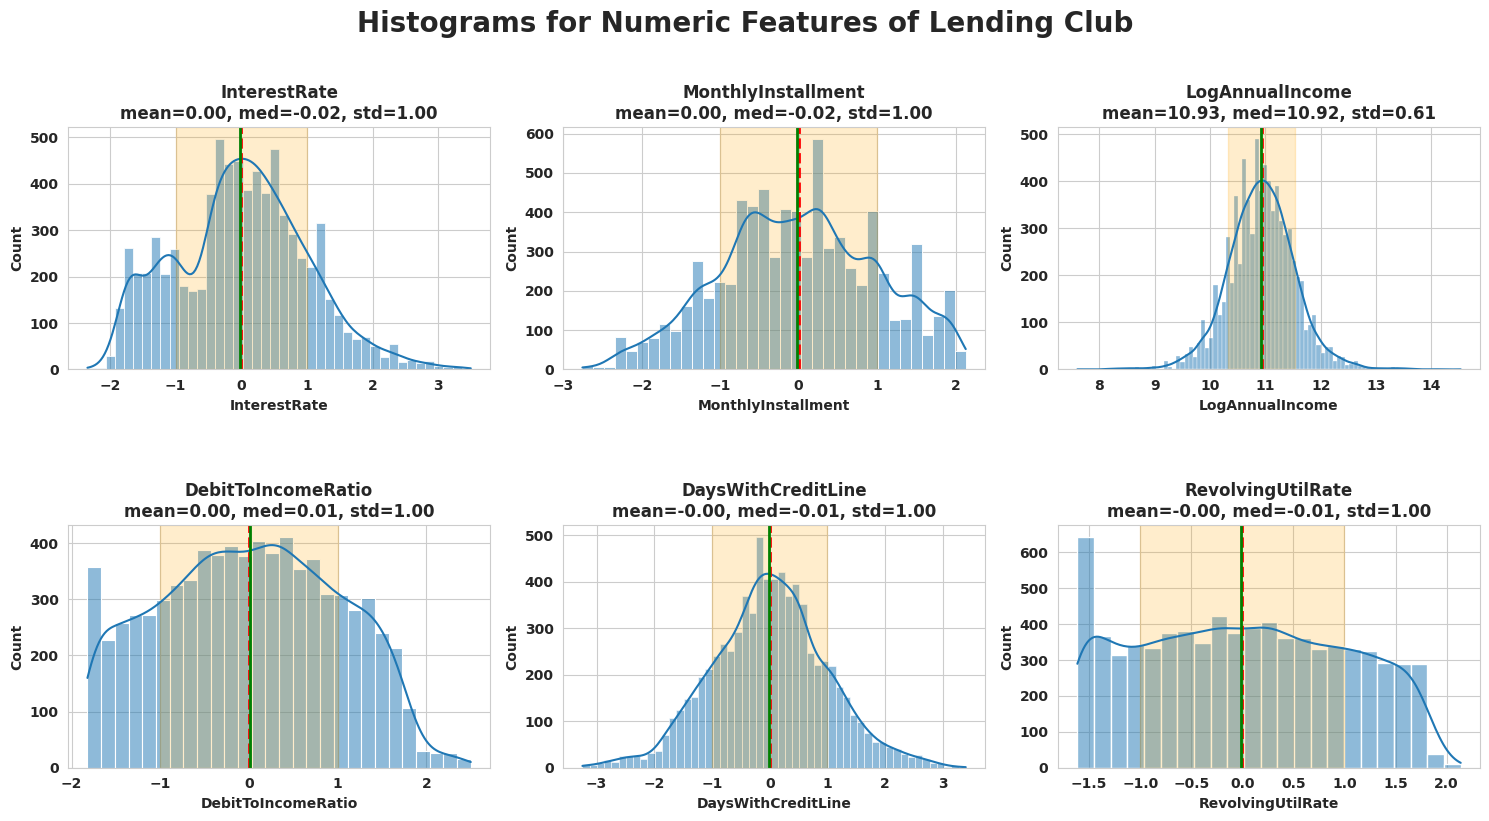

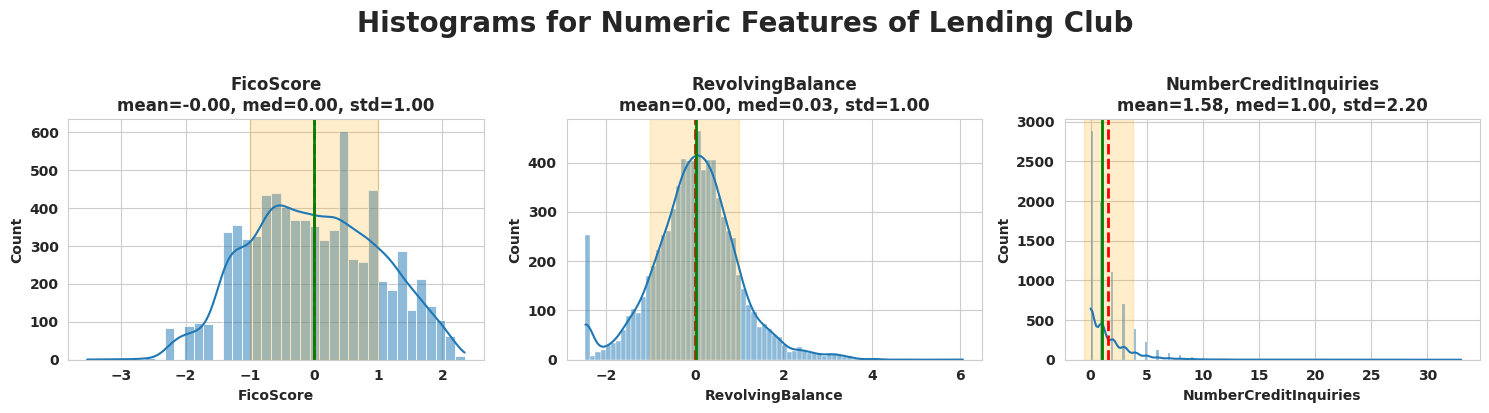

In [211]:
DisplayNumericFeatureHistograms(X_train, 
                                feature_columns=float_columns,
                                plot_title = 'Continuous Numeric Feature Distributions', 
                                display_statistics=True)
print()
print()

columns_to_plot = ['FicoScore', 'RevolvingBalance', 'NumberCreditInquiries']	
DisplayNumericFeatureHistograms(X_train, 
                                feature_columns=columns_to_plot,
                                plot_title = 'Continuous Integer Feature Distributions', 
                                display_statistics=True)

print()
print()                                

#### Balanced Distribution of Dataset Label: **NotFullyPaid**
Display plots showing the balanced distribution of the label (NotFullyPaid).</br>
The split has been corrected from 84%/16% to 50%/50%</br>

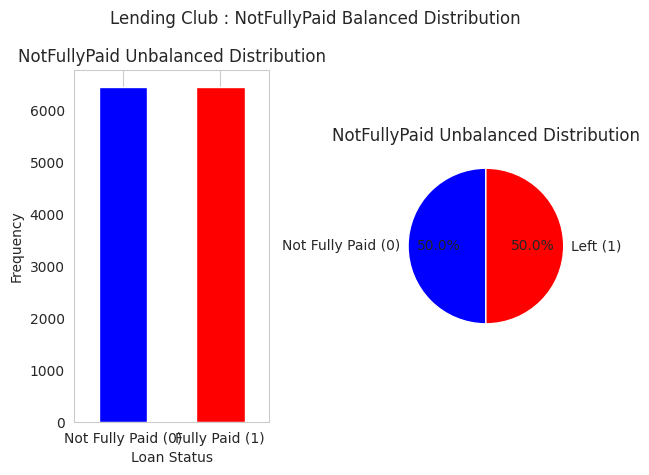

In [212]:
#
# SMOTE Directly from 20.3 Classification Part 3
# 

# Apply SMOTE
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# Plot the corrected results
DisplayDataFeatureBalancePlots(x_data=None, 
                               y_data=y_train_smote, 
                               plot_title= f'{data_set_name} : {label} Balanced Distribution',
                               label_name = label)

## **3. Feature Engineered Data Modeling** ##

#### Process Machine Learning Models ####
Process the ML models with the Feature Engineered dataset

Logistic Regression
Lending Club Loan Data LOGISTIC REGRESSION RESULTS
Training Accuracy: 0.6975
Testing Accuracy:  0.6649
Testing F1 Score:  0.7032
Gap:               0.0326

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.8716372021521906, 'recall': 0.7047855811062772, 'f1-score': 0.7793814432989691, 'support': 1609.0}, '1': {'precision': 0.22764227642276422, 'recall': 0.4560260586319218, 'f1-score': 0.3036876355748373, 'support': 307.0}, 'accuracy': 0.6649269311064718, 'macro avg': {'precision': 0.5496397392874774, 'recall': 0.5804058198690996, 'f1-score': 0.5415345394369032, 'support': 1916.0}, 'weighted avg': {'precision': 0.7684501237602628, 'recall': 0.6649269311064718, 'f1-score': 0.7031611933139438, 'support': 1916.0}}



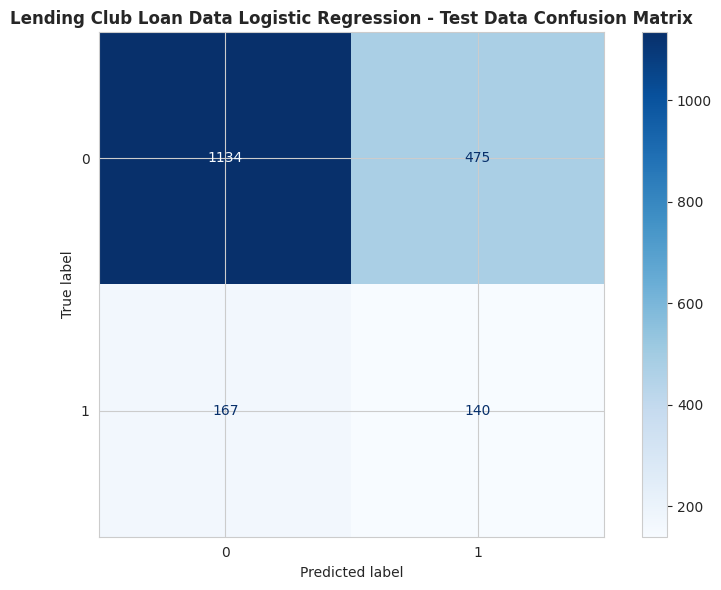


------------------------------------------------------------
Lending Club Loan Data FEATURE IMPORTANCE
------------------------------------------------------------
Purpose_credit_card              2.289103
Purpose_major_purchase           2.135361
Purpose_educational              1.748824
Purpose_home_improvement         1.490403
Purpose_debt_consolidation       1.421860
Purpose_small_business           1.182287
CreditPolicy                     0.645706
Delinquencies                    0.620467
LogAnnualIncome                  0.568763
NegativePublicRecords            0.442233
MonthlyInstallment               0.421747
FicoScore                        0.346774
DaysWithCreditLine               0.182741
InterestRate                     0.134344
RevolvingUtilRate                0.064330
fico_bin_Excellent               0.053188
fico_bin_Excellent               0.053188
fico_bin_Excellent               0.053188
fico_bin_Excellent               0.053188
fico_bin_Excellent               0.05

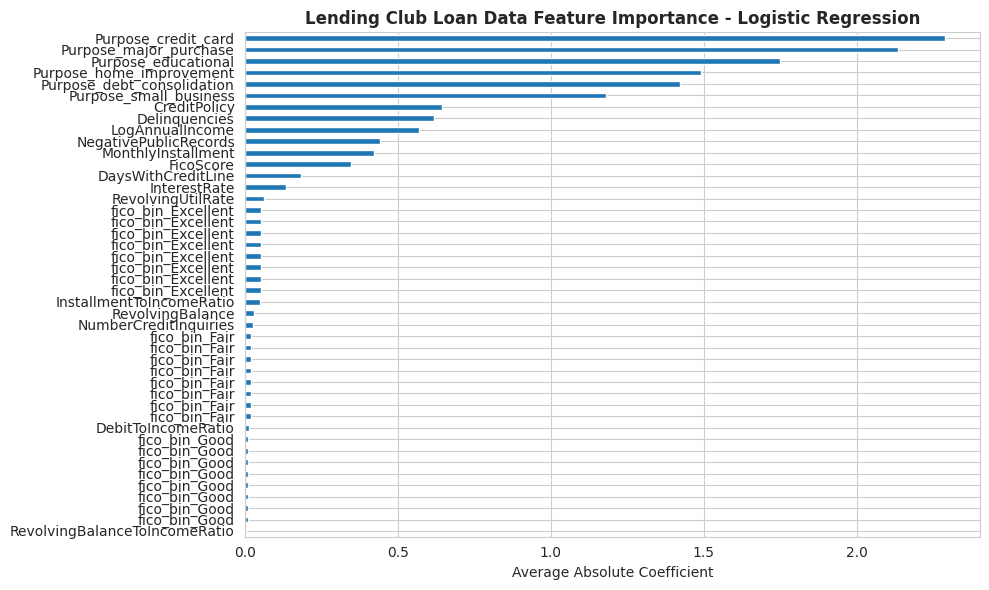

Logistic Regression 5-Fold CV
Mean CV Accuracy: 0.6951 ± 0.0084
95% CI Accuracy: 0.6867 to 0.7035
Mean CV F1 Score: 0.6950 ± 0.0084
95% CI F1: 0.6866 to 0.7034
Train Accuracy: 0.6973
Test Accuracy: 0.6967
Test F1 Score: 0.6967


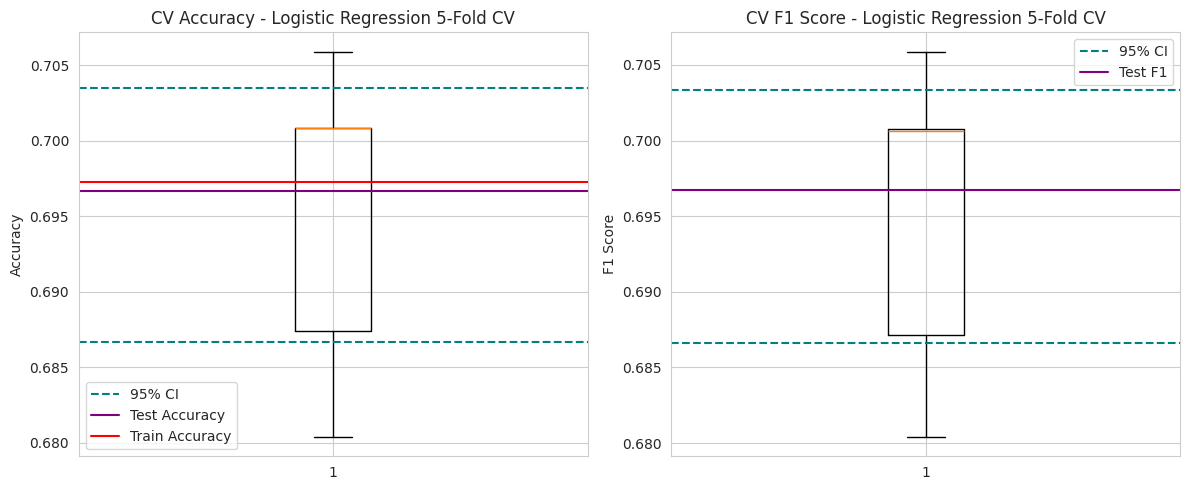



Random Forest Classifier
Lending Club Loan Data RANDOM FOREST CLASSIFIER RESULTS
Training Accuracy: 1.0000
Testing Accuracy:  0.7714
Testing F1 Score:  0.7645
Gap:               0.2286

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.854633555420957, 'recall': 0.8769422001243008, 'f1-score': 0.8656441717791411, 'support': 1609.0}, '1': {'precision': 0.2528301886792453, 'recall': 0.2182410423452769, 'f1-score': 0.23426573426573427, 'support': 307.0}, 'accuracy': 0.7713987473903967, 'macro avg': {'precision': 0.5537318720501011, 'recall': 0.5475916212347889, 'f1-score': 0.5499549530224377, 'support': 1916.0}, 'weighted avg': {'precision': 0.7582068155515909, 'recall': 0.7713987473903967, 'f1-score': 0.7644786288163979, 'support': 1916.0}}



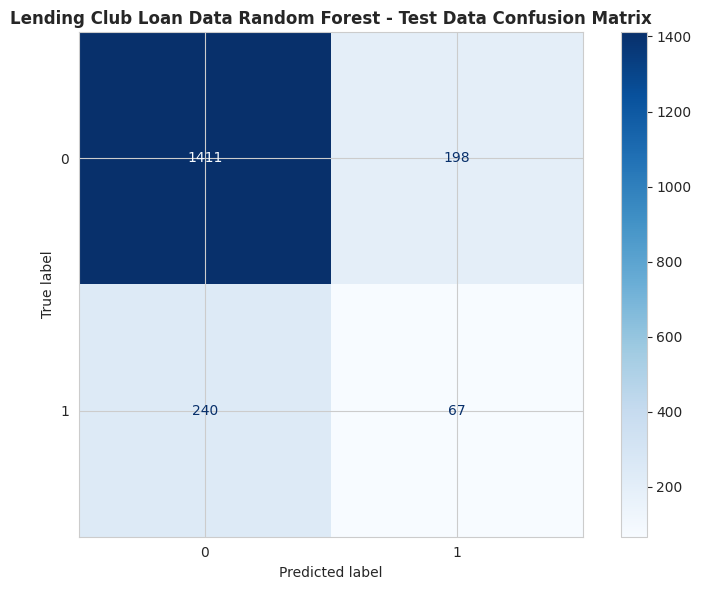


------------------------------------------------------------
Lending Club Loan Data FEATURE IMPORTANCE
------------------------------------------------------------
FicoScore                        0.095110
InterestRate                     0.088996
DaysWithCreditLine               0.079314
InstallmentToIncomeRatio         0.079268
DebitToIncomeRatio               0.076619
MonthlyInstallment               0.076549
RevolvingUtilRate                0.075143
LogAnnualIncome                  0.072946
RevolvingBalanceToIncomeRatio    0.072339
RevolvingBalance                 0.069448
NumberCreditInquiries            0.040107
Purpose_credit_card              0.030574
CreditPolicy                     0.029123
Purpose_debt_consolidation       0.027619
Delinquencies                    0.015422
Purpose_major_purchase           0.009324
Purpose_home_improvement         0.008012
Purpose_small_business           0.006904
Purpose_educational              0.006082
NegativePublicRecords            0.00

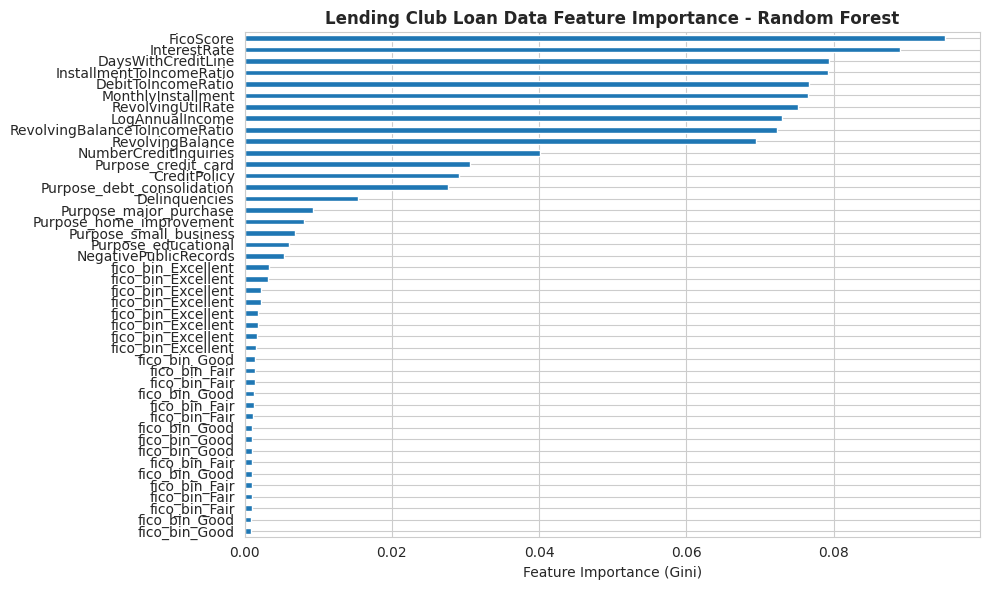

Random Forest 5-Fold CV
Mean CV Accuracy: 0.8832 ± 0.0062
95% CI Accuracy: 0.8771 to 0.8894
Mean CV F1 Score: 0.8832 ± 0.0062
95% CI F1: 0.8771 to 0.8894
Train Accuracy: 1.0000
Test Accuracy: 0.8901
Test F1 Score: 0.8901


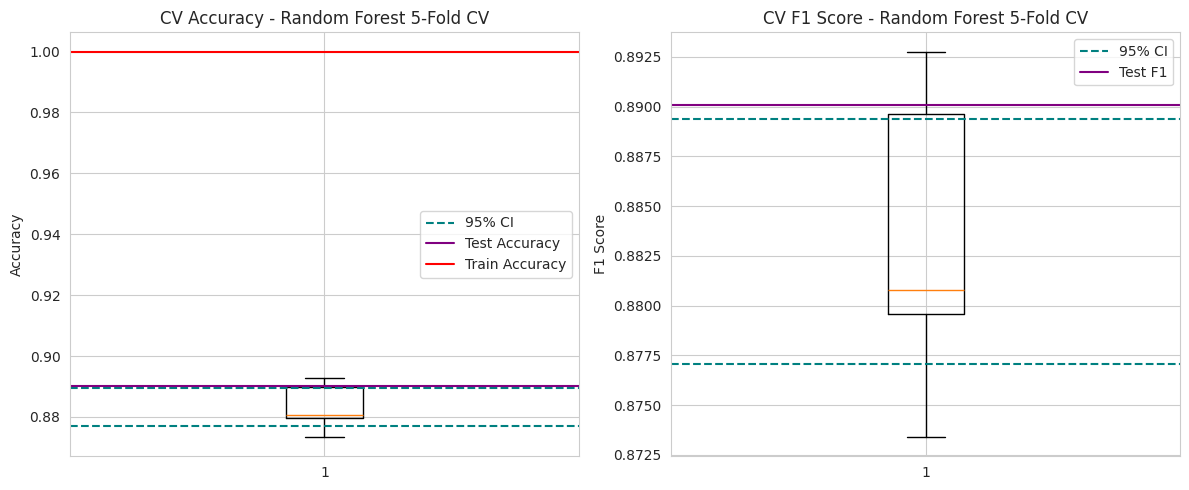



Gradient Boosting Classifier
Lending Club Loan Data GRADIENT BOOSTING CLASSIFIER RESULTS
Training Accuracy: 0.7490
Testing Accuracy:  0.6785
Testing F1 Score:  0.7138
Gap:               0.0705

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.8747169811320755, 'recall': 0.7203231821006837, 'f1-score': 0.7900477164280846, 'support': 1609.0}, '1': {'precision': 0.23857868020304568, 'recall': 0.4592833876221498, 'f1-score': 0.31403118040089084, 'support': 307.0}, 'accuracy': 0.6784968684759917, 'macro avg': {'precision': 0.5566478306675606, 'recall': 0.5898032848614168, 'f1-score': 0.5520394484144877, 'support': 1916.0}, 'weighted avg': {'precision': 0.7727887669435514, 'recall': 0.6784968684759917, 'f1-score': 0.713775755801598, 'support': 1916.0}}



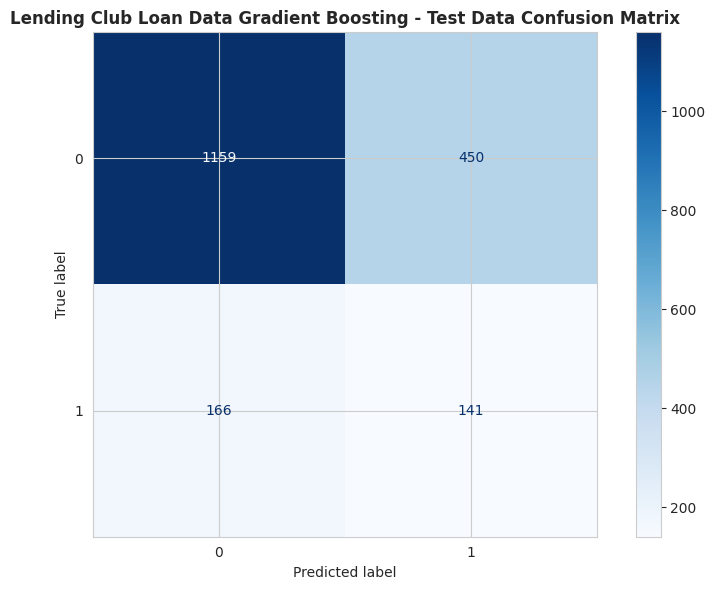


------------------------------------------------------------
Lending Club Loan Data FEATURE IMPORTANCE
------------------------------------------------------------
Purpose_credit_card              0.135052
FicoScore                        0.118810
Purpose_debt_consolidation       0.103398
CreditPolicy                     0.091164
InterestRate                     0.082884
InstallmentToIncomeRatio         0.045334
Purpose_major_purchase           0.040952
NumberCreditInquiries            0.035401
Delinquencies                    0.034595
Purpose_home_improvement         0.032605
DaysWithCreditLine               0.030688
MonthlyInstallment               0.029438
fico_bin_Excellent               0.023968
Purpose_educational              0.023430
RevolvingUtilRate                0.022910
RevolvingBalanceToIncomeRatio    0.022492
DebitToIncomeRatio               0.021843
LogAnnualIncome                  0.020550
fico_bin_Excellent               0.017329
Purpose_small_business           0.01

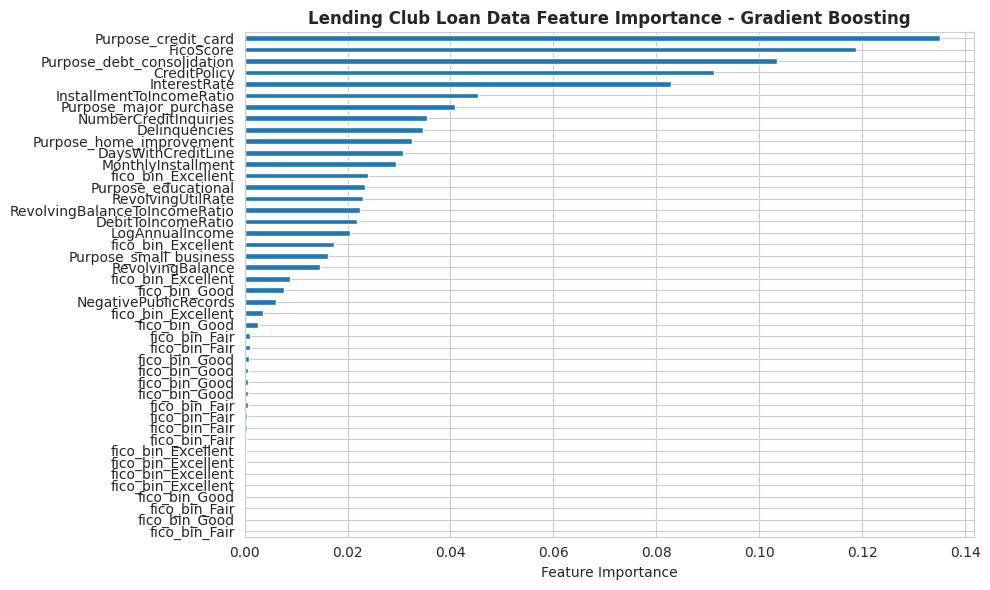

Gradient Boosting 5-Fold CV
Mean CV Accuracy: 0.7335 ± 0.0091
95% CI Accuracy: 0.7245 to 0.7426
Mean CV F1 Score: 0.7335 ± 0.0091
95% CI F1: 0.7244 to 0.7426
Train Accuracy: 0.7564
Test Accuracy: 0.7313
Test F1 Score: 0.7312


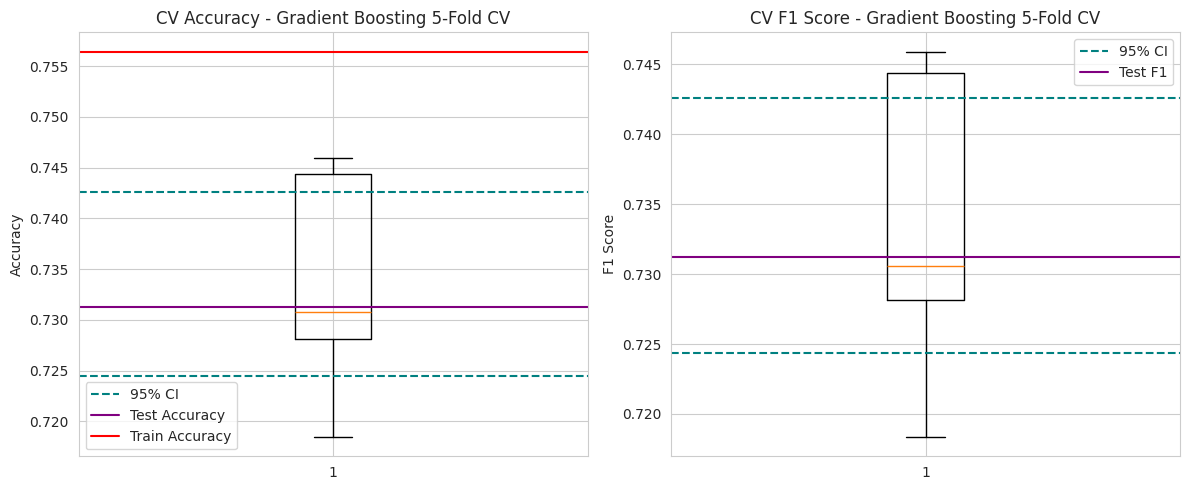

In [213]:
feature_names = df_LendingClub.drop('NotFullyPaid', axis=1).columns.tolist()

feature_engineered_LogisticRegressionResults = RunLogisticRegressionAndCrossValidation(
                                                                                        plot_title='Feature Engineered Lending Club Loan Data',
                                                                                        X_train=X_train_smote,     
                                                                                        X_test=X_test,          
                                                                                        y_train=y_train_smote,     
                                                                                        y_test=y_test,             
                                                                                        feature_names=feature_names
                                                                                    )

feature_engineered_RandomForestResults = RunRandomForestClassifierAndCrossValidation(
                                                                                        plot_title='Feature Engineered Lending Club Loan Data',
                                                                                        X_train=X_train_smote,     
                                                                                        X_test=X_test,          
                                                                                        y_train=y_train_smote,     
                                                                                        y_test=y_test,             
                                                                                        feature_names=feature_names
                                                                                    )                                                                        

feature_engineered_GradientBoostingResults = RunGradientBoostingClassifierAndCrossValidation(
                                                                                                plot_title='Feature Engineered Lending Club Loan Data',
                                                                                                X_train=X_train_smote,     
                                                                                                X_test=X_test,          
                                                                                                y_train=y_train_smote,     
                                                                                                y_test=y_test,             
                                                                                                feature_names=feature_names
                                                                                            )                                                                        

### Machine Leaning Models With **Feature Engineered** Data Analysis ###
**Logistic Regression (ML)**
- Most Important Features:
    - fico_bin_Excellent               2.474063
    - Purpose_credit_card              2.267060
    - Purpose_major_purchase           2.094066
    - Purpose_educational              1.686429
    - fico_bin_Good                    1.637250
- Confusion Matrix
    - Reasonably good at identifying TN (NDO=0)
    - Not very good at identifying TP (ND0=1) - 50/50
    - FP (Type 1 Errors) - 457
    - FN (Type 2 Errors) - 179
Performed slightly worse with Feature Engineered dataset

**Random Forest Classifier (ML)**
- Most Important Features:
    - FicoScore                        0.102376
    - InterestRate                     0.096906
    - DaysWithCreditLine               0.079539
    - InstallmentToIncomeRatio         0.077382
    - DebitToIncomeRatio               0.076962
- Confusion Matrix
    - Very good at identifying TN (NDO=0)
    - Much improved at identifying TP (ND0=1) 
    - FP (Type 1 Errors) - 194
    - FN (Type 2 Errors) - 243
    - Box Plot Analysis
Although this identifies more TPs, overall the model performs worse.

**Gradient Boosting Classifier (ML)**
- Most Important Features:
    - FicoScore                        0.178172
    - Purpose_credit_card              0.123814
    - CreditPolicy                     0.115489
    - Purpose_debt_consolidation       0.099890
    - InterestRate                     0.076975
- Confusion Matrix
    - Good at identifying TN (NDO=0)
    - Much improved at identifying TP (ND0=1) 
    - FP (Type 1 Errors) - 429
    - FN (Type 2 Errors) - 170
Identifies more TPs, but has higher number of FPs and FNs

#### Process Deep Learning Models with Feature Engineered Data ####
Process the DL models with the Feature Engineered dataset and Hyperparameter tuning.</br>
Determine the best DL model so it can be compared against the Feature Engineered ML model runs.</br>
Class balance has already been handled, so there is no need to use ClassWeights.

Batch size: 32, learning rate: 0.0001...	Sequential Model using Dropouts

Sequential Model Architecture:


Model: "sequential_61"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_244 (Dense)               │ (None, 8)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_104 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_245 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_105 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_246 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_247 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

None
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.5000
Testing Accuracy:  0.1602
Testing F1 Score:  0.0443
Gap:               0.3398

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.0, 'recall': 0.0, 'f1-score': 0.0, 'support': 1609.0}, '1': {'precision': 0.16022964509394572, 'recall': 1.0, 'f1-score': 0.2762033288349078, 'support': 307.0}, 'accuracy': 0.16022964509394572, 'macro avg': {'precision': 0.08011482254697286, 'recall': 0.5, 'f1-score': 0.1381016644174539, 'support': 1916.0}, 'weighted avg': {'precision': 0.025673539166931804, 'recall': 0.16022964509394572, 'f1-score': 0.04425596135298365, 'support': 1916.0}}



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


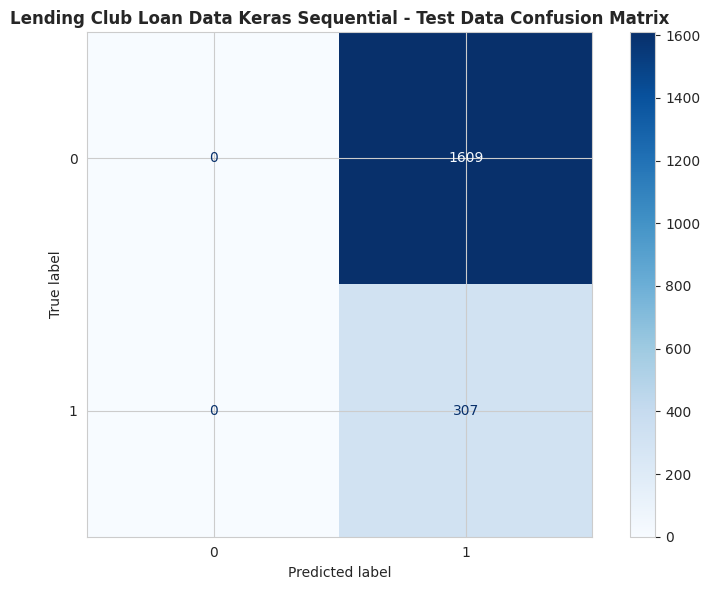

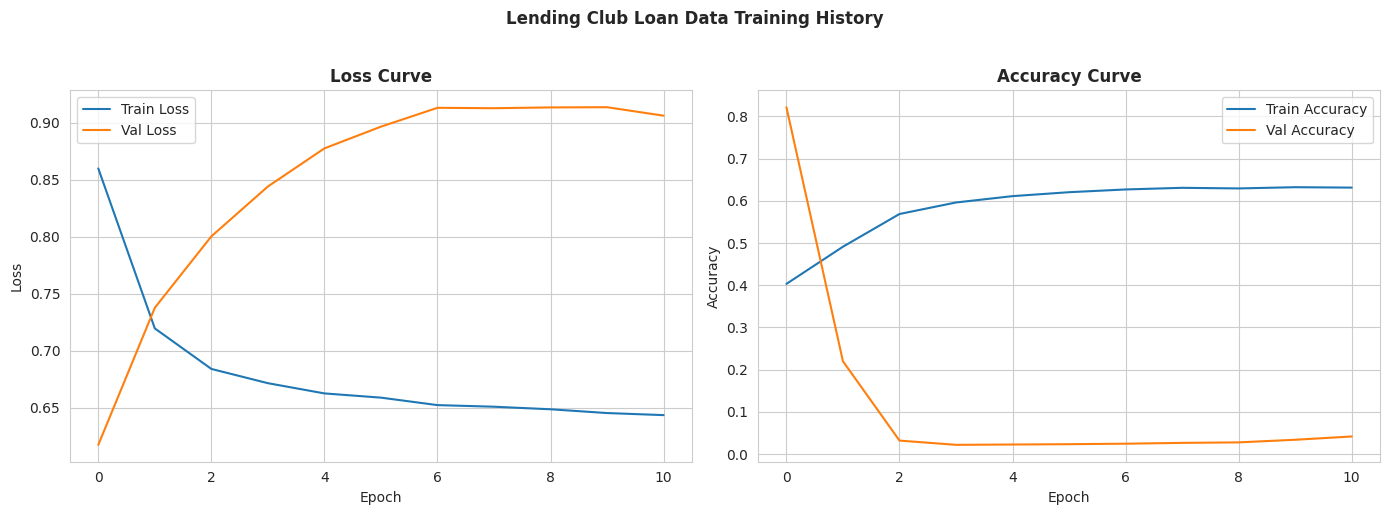


Completed Run #1
Batch size: 32, learning rate: 0.001...	Sequential Model using Dropouts

Sequential Model Architecture:


Model: "sequential_62"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_248 (Dense)               │ (None, 8)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_106 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_249 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_107 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_250 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_251 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

None
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.6965
Testing Accuracy:  0.5532
Testing F1 Score:  0.6119
Gap:               0.1432

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.8853633572159673, 'recall': 0.5376009944064637, 'f1-score': 0.6689868522815159, 'support': 1609.0}, '1': {'precision': 0.20766773162939298, 'recall': 0.6351791530944625, 'f1-score': 0.3130016051364366, 'support': 307.0}, 'accuracy': 0.5532359081419624, 'macro avg': {'precision': 0.5465155444226801, 'recall': 0.586390073750463, 'f1-score': 0.49099422870897624, 'support': 1916.0}, 'weighted avg': {'precision': 0.776776427646511, 'recall': 0.5532359081419624, 'f1-score': 0.6119474624727793, 'support': 1916.0}}



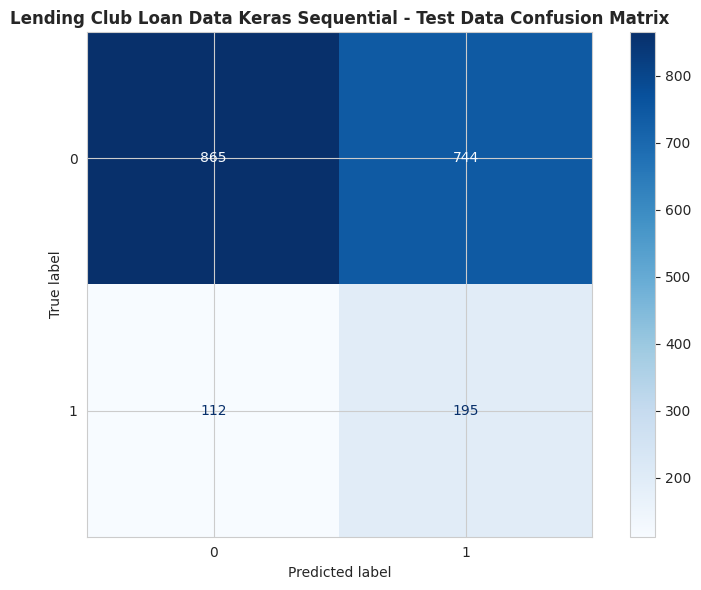

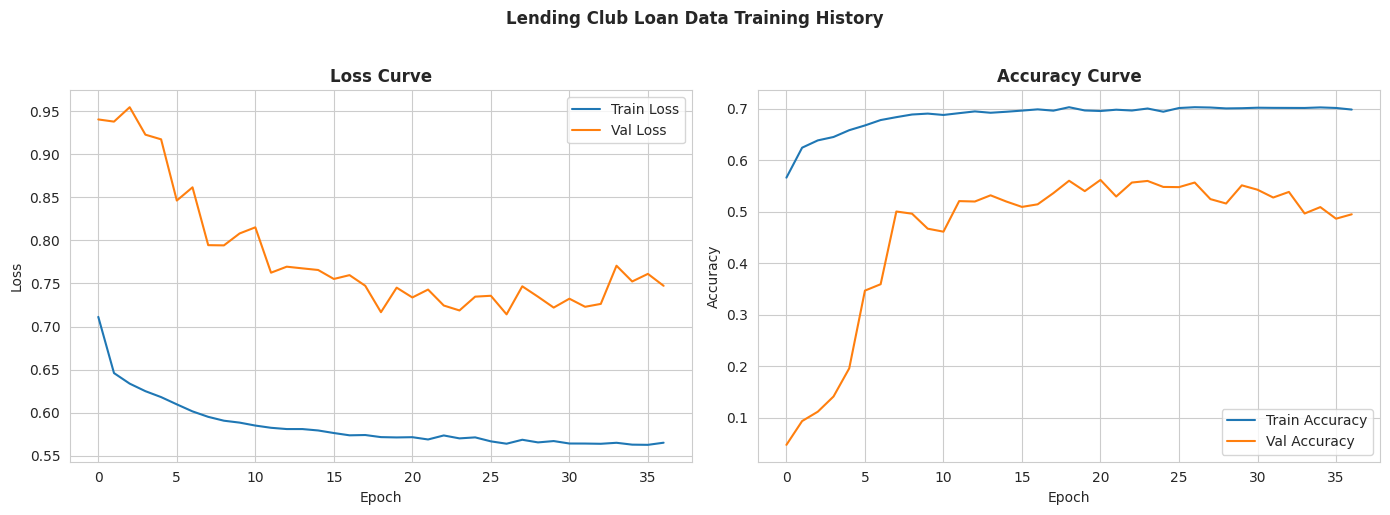


Completed Run #2
Batch size: 32, learning rate: 0.01...	Sequential Model using Dropouts

Sequential Model Architecture:


Model: "sequential_63"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_252 (Dense)               │ (None, 8)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_108 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_253 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_109 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_254 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_255 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

None
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.6519
Testing Accuracy:  0.4723
Testing F1 Score:  0.5277
Gap:               0.1795

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.9152777777777777, 'recall': 0.4095711622125544, 'f1-score': 0.5659081150708458, 'support': 1609.0}, '1': {'precision': 0.205685618729097, 'recall': 0.8013029315960912, 'f1-score': 0.3273453093812375, 'support': 307.0}, 'accuracy': 0.4723382045929019, 'macro avg': {'precision': 0.5604816982534374, 'recall': 0.6054370469043229, 'f1-score': 0.44662671222604167, 'support': 1916.0}, 'weighted avg': {'precision': 0.8015800779719608, 'recall': 0.4723382045929019, 'f1-score': 0.5276832813825839, 'support': 1916.0}}



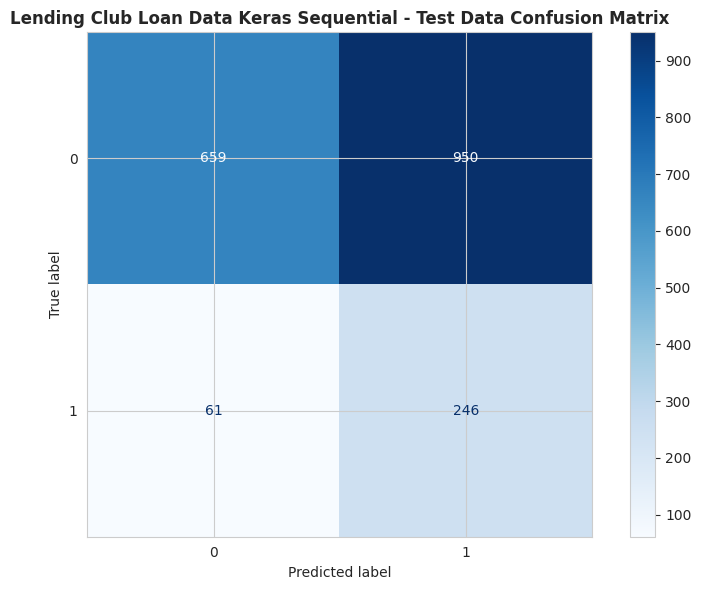

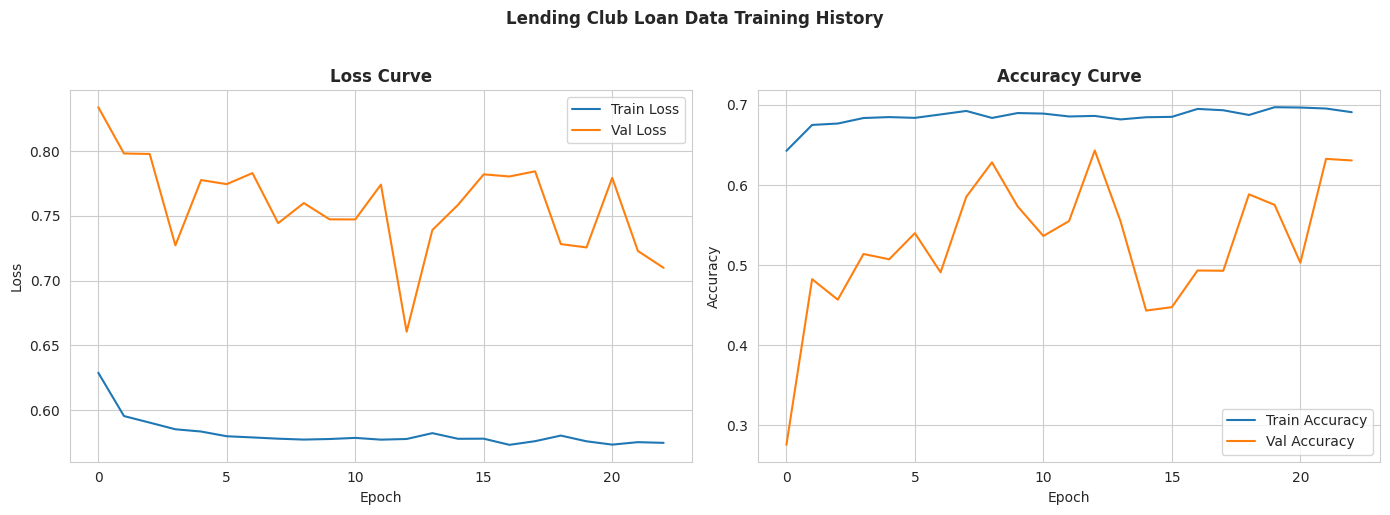


Completed Run #3
Batch size: 64, learning rate: 0.0001...	Sequential Model using Dropouts

Sequential Model Architecture:


Model: "sequential_64"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_256 (Dense)               │ (None, 8)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_110 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_257 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_111 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_258 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_259 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

None
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.4989
Testing Accuracy:  0.1613
Testing F1 Score:  0.0464
Gap:               0.3376

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 1.0, 'recall': 0.001243008079552517, 'f1-score': 0.002482929857231533, 'support': 1609.0}, '1': {'precision': 0.16039707419017765, 'recall': 1.0, 'f1-score': 0.2764520486267447, 'support': 307.0}, 'accuracy': 0.16127348643006262, 'macro avg': {'precision': 0.5801985370950888, 'recall': 0.5006215040397762, 'f1-score': 0.13946748924198812, 'support': 1916.0}, 'weighted avg': {'precision': 0.8654707211776538, 'recall': 0.16127348643006262, 'f1-score': 0.0463809045243717, 'support': 1916.0}}



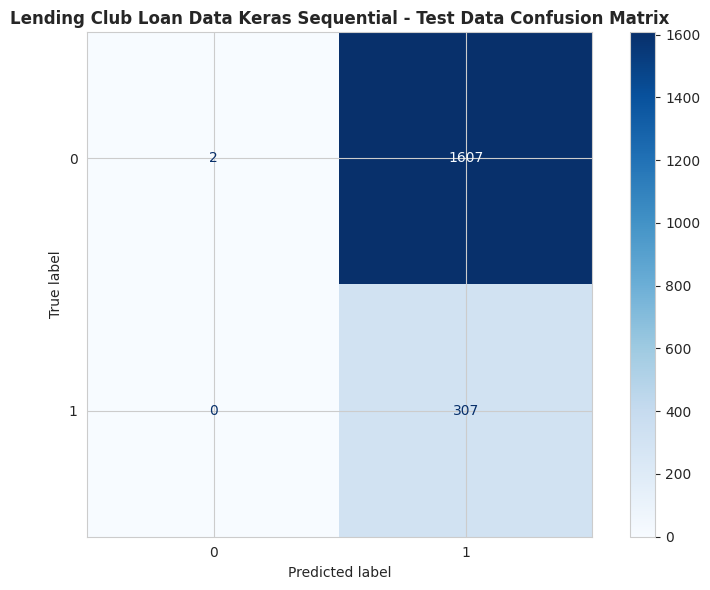

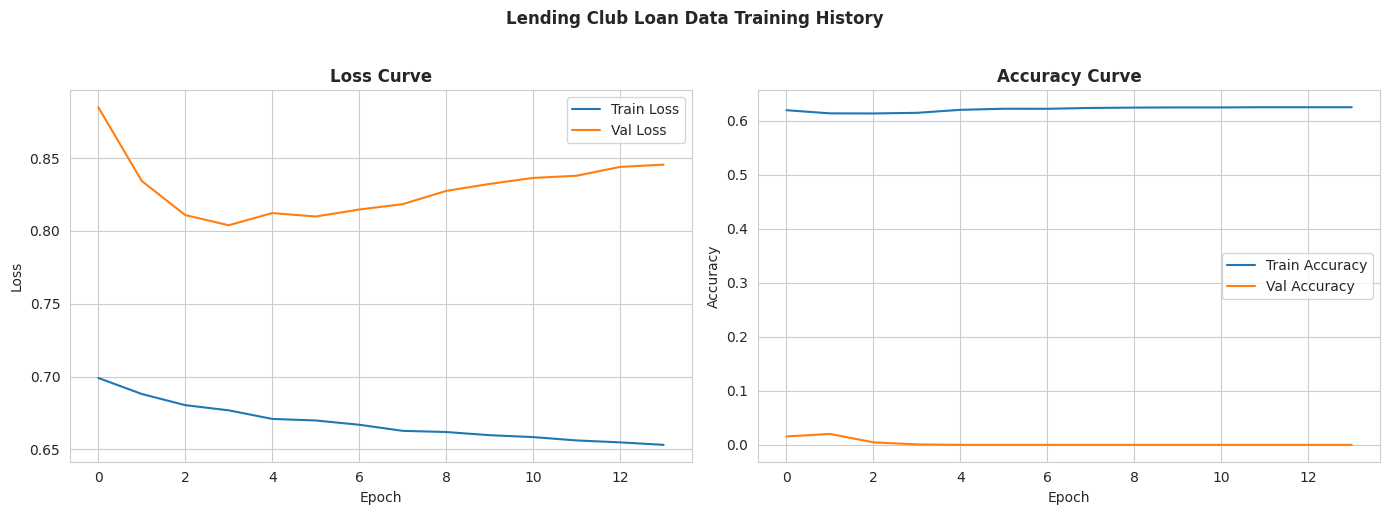


Completed Run #4
Batch size: 64, learning rate: 0.001...	Sequential Model using Dropouts

Sequential Model Architecture:


Model: "sequential_65"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_260 (Dense)               │ (None, 8)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_112 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_261 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_113 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_262 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_263 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

None
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.6492
Testing Accuracy:  0.4562
Testing F1 Score:  0.5117
Gap:               0.1931

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.903271692745377, 'recall': 0.39465506525792415, 'f1-score': 0.5493079584775087, 'support': 1609.0}, '1': {'precision': 0.19703215169002472, 'recall': 0.7785016286644951, 'f1-score': 0.3144736842105263, 'support': 307.0}, 'accuracy': 0.4561586638830898, 'macro avg': {'precision': 0.5501519222177008, 'recall': 0.5865783469612096, 'f1-score': 0.43189082134401746, 'support': 1916.0}, 'weighted avg': {'precision': 0.7901111817307669, 'recall': 0.4561586638830898, 'f1-score': 0.5116805460558158, 'support': 1916.0}}



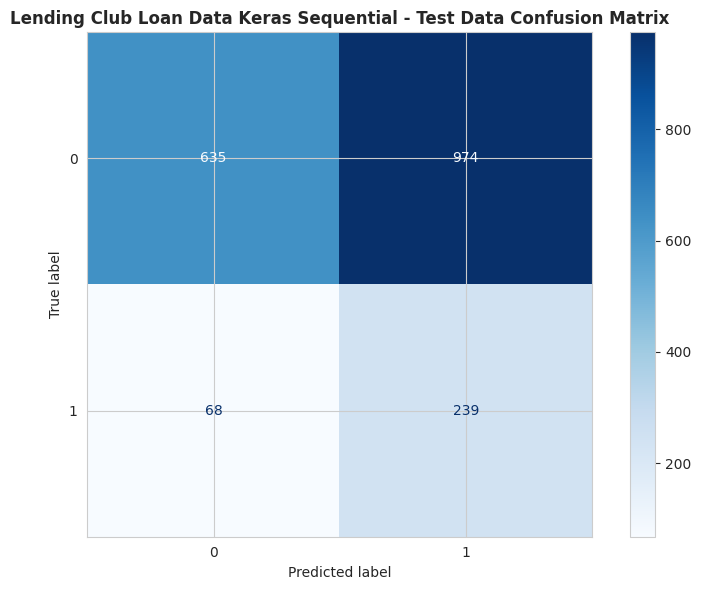

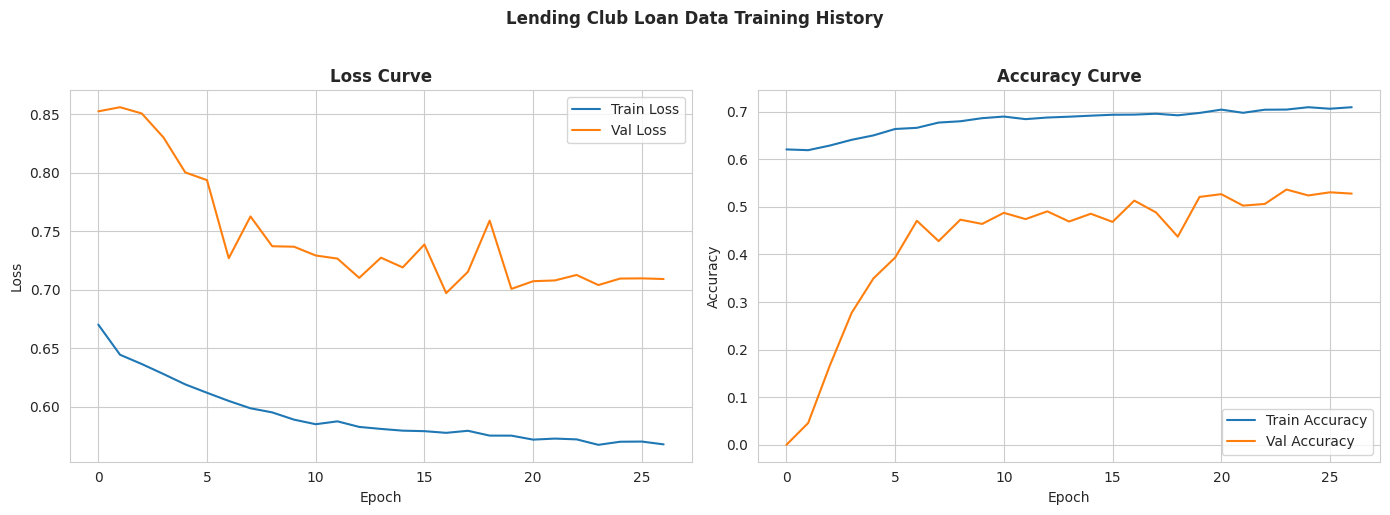


Completed Run #5
Batch size: 64, learning rate: 0.01...	Sequential Model using Dropouts

Sequential Model Architecture:


Model: "sequential_66"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_264 (Dense)               │ (None, 8)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_114 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_265 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_115 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_266 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_267 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

None
403/403 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.6715
Testing Accuracy:  0.5308
Testing F1 Score:  0.5901
Gap:               0.1407

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.8953229398663697, 'recall': 0.4996892479801119, 'f1-score': 0.6414040686078979, 'support': 1609.0}, '1': {'precision': 0.20923379174852652, 'recall': 0.6938110749185668, 'f1-score': 0.32150943396226417, 'support': 307.0}, 'accuracy': 0.5307933194154488, 'macro avg': {'precision': 0.5522783658074482, 'recall': 0.5967501614493393, 'f1-score': 0.48145675128508103, 'support': 1916.0}, 'weighted avg': {'precision': 0.7853911191606402, 'recall': 0.5307933194154488, 'f1-score': 0.5901474648311705, 'support': 1916.0}}



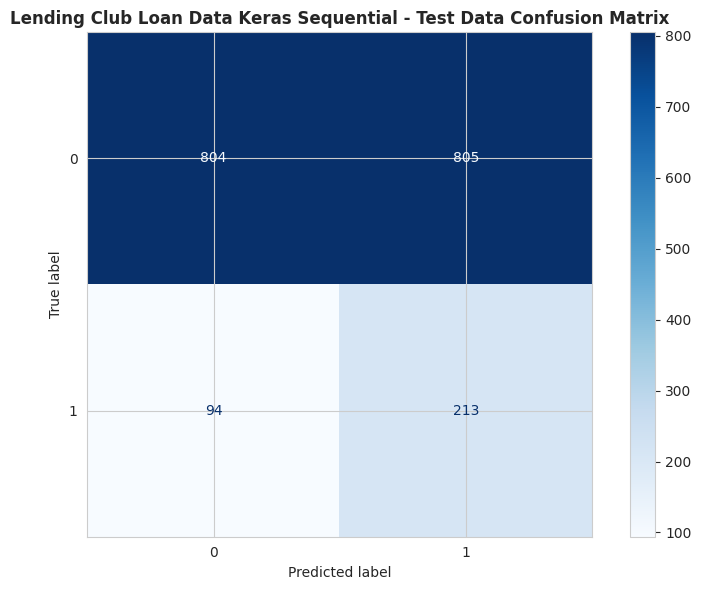

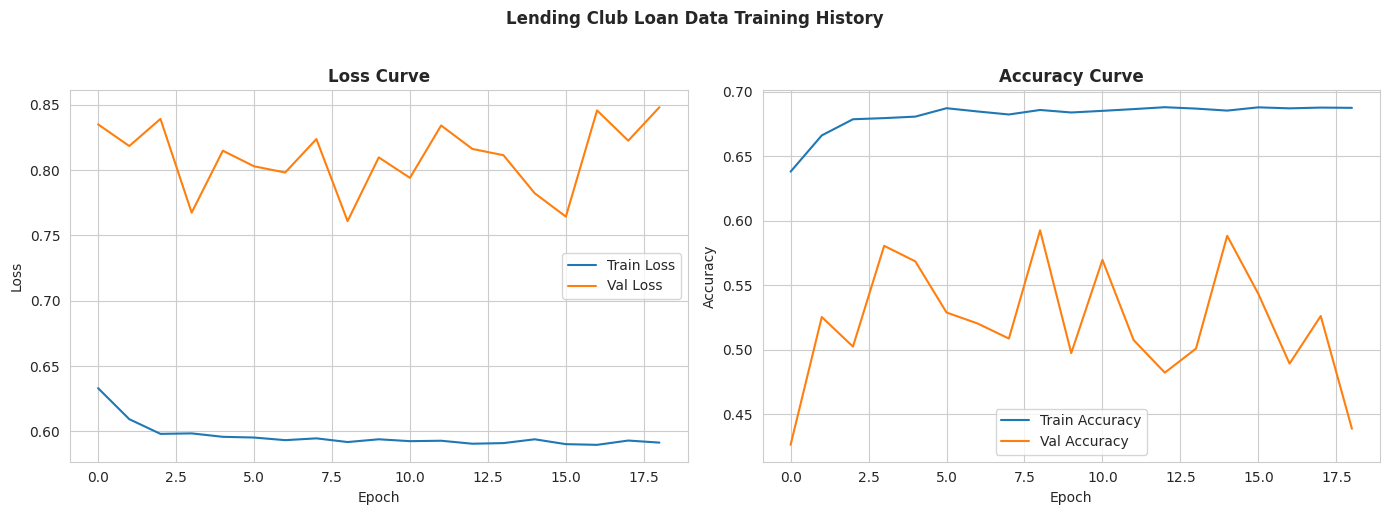


Completed Run #6
Batch size: 128, learning rate: 0.0001...	Sequential Model using Dropouts

Sequential Model Architecture:


Model: "sequential_67"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_268 (Dense)               │ (None, 8)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_116 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_269 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_117 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_270 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_271 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

None
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.5001
Testing Accuracy:  0.1602
Testing F1 Score:  0.0452
Gap:               0.3398

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.5, 'recall': 0.0006215040397762585, 'f1-score': 0.0012414649286157666, 'support': 1609.0}, '1': {'precision': 0.15987460815047022, 'recall': 0.996742671009772, 'f1-score': 0.2755515533543449, 'support': 307.0}, 'accuracy': 0.16022964509394572, 'macro avg': {'precision': 0.32993730407523514, 'recall': 0.4986820875247741, 'f1-score': 0.13839650914148033, 'support': 1916.0}, 'weighted avg': {'precision': 0.44550182917651066, 'recall': 0.16022964509394572, 'f1-score': 0.04519407304275921, 'support': 1916.0}}



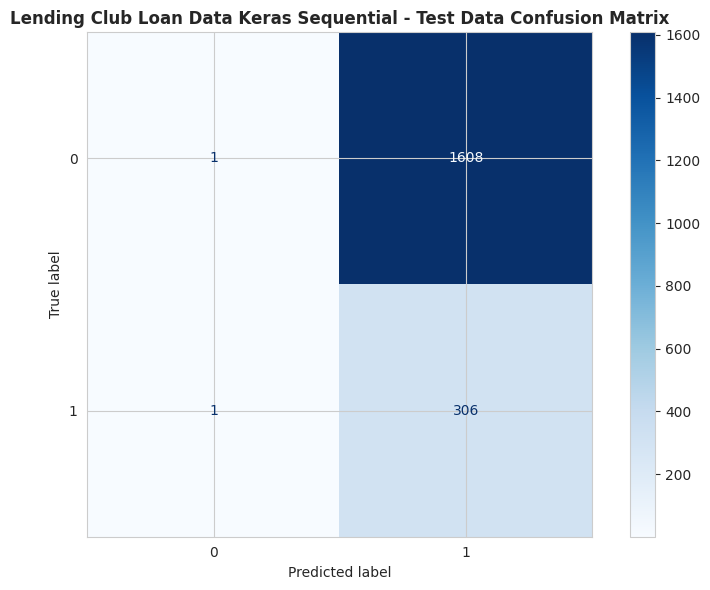

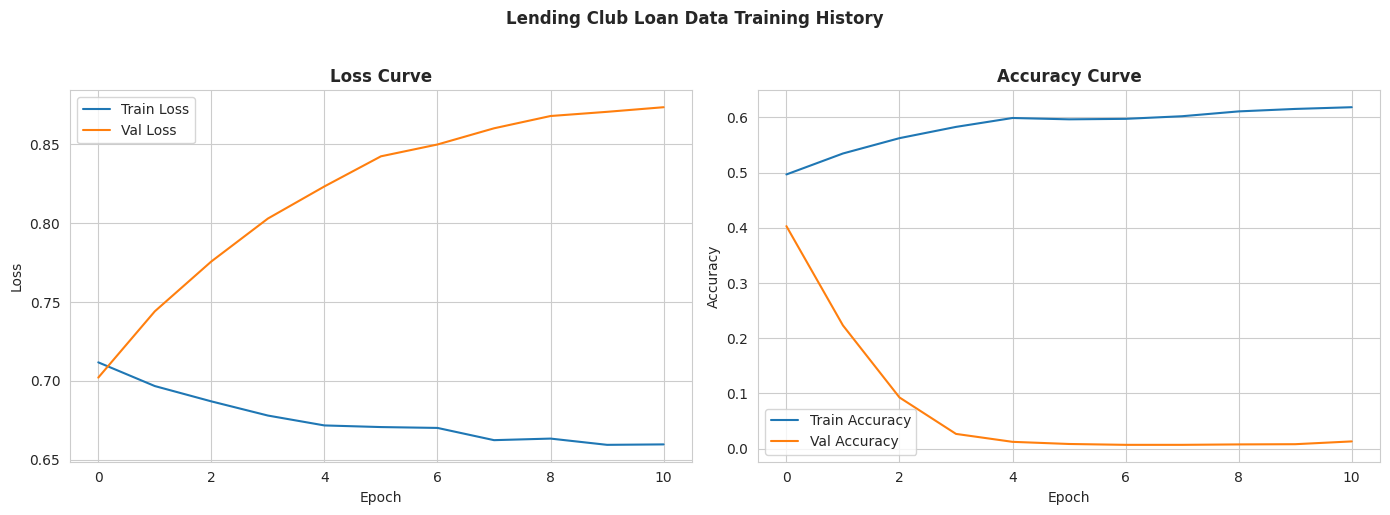


Completed Run #7
Batch size: 128, learning rate: 0.001...	Sequential Model using Dropouts

Sequential Model Architecture:


Model: "sequential_68"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_272 (Dense)               │ (None, 8)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_118 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_273 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_119 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_274 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_275 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

None
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.6670
Testing Accuracy:  0.5052
Testing F1 Score:  0.5644
Gap:               0.1618

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.8996372430471584, 'recall': 0.46239900559353636, 'f1-score': 0.6108374384236454, 'support': 1609.0}, '1': {'precision': 0.2056932966023875, 'recall': 0.7296416938110749, 'f1-score': 0.3209169054441261, 'support': 307.0}, 'accuracy': 0.5052192066805845, 'macro avg': {'precision': 0.5526652698247729, 'recall': 0.5960203497023057, 'f1-score': 0.4658771719338857, 'support': 1916.0}, 'weighted avg': {'precision': 0.7884468507932206, 'recall': 0.5052192066805845, 'f1-score': 0.5643835743188894, 'support': 1916.0}}



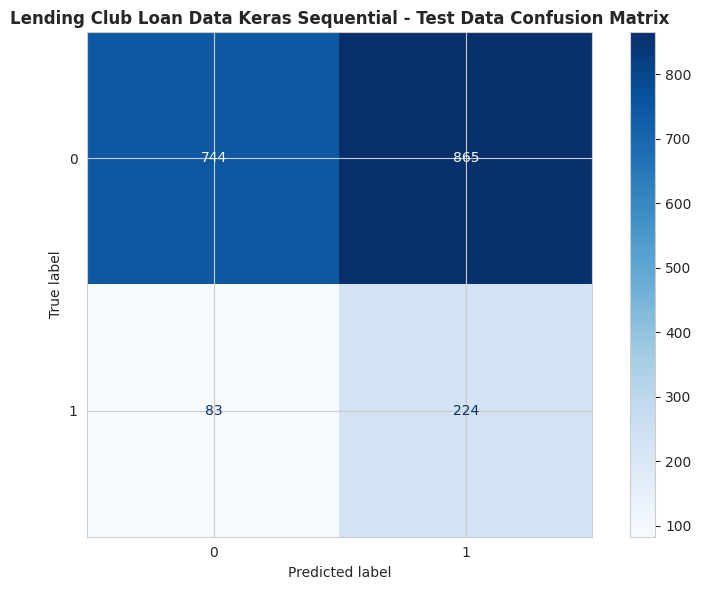

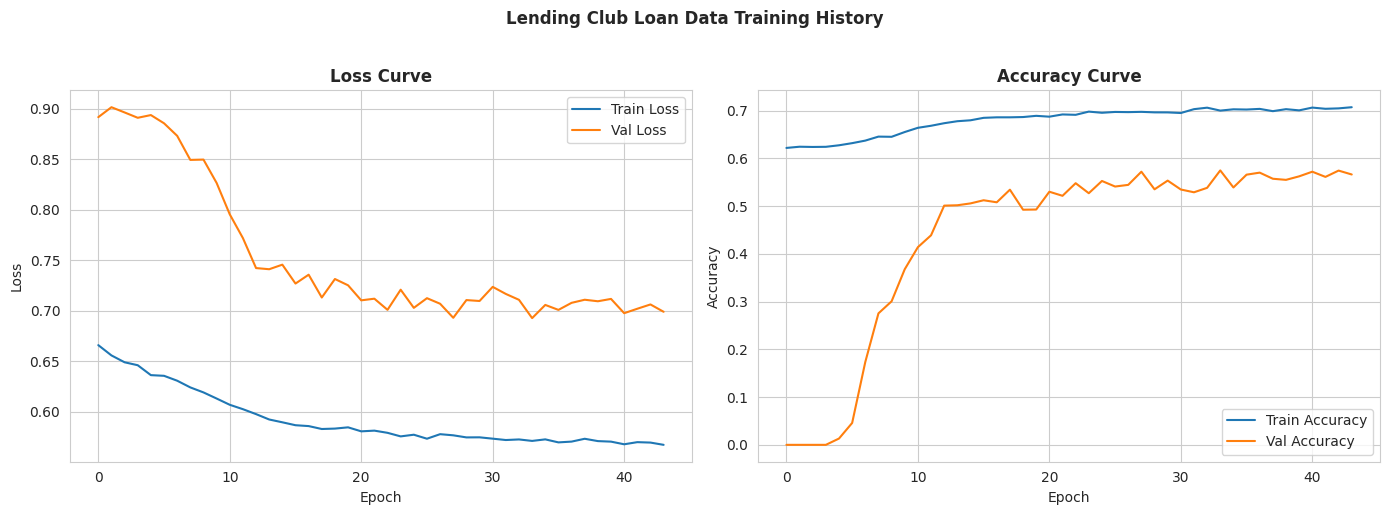


Completed Run #8
Batch size: 128, learning rate: 0.01...	Sequential Model using Dropouts

Sequential Model Architecture:


Model: "sequential_69"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_276 (Dense)               │ (None, 8)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_120 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_277 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_121 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_278 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_279 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

None
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.6779
Testing Accuracy:  0.5235
Testing F1 Score:  0.5835
Gap:               0.1544

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.8901345291479821, 'recall': 0.4934742075823493, 'f1-score': 0.6349460215913635, 'support': 1609.0}, '1': {'precision': 0.2041015625, 'recall': 0.6807817589576547, 'f1-score': 0.3140495867768595, 'support': 307.0}, 'accuracy': 0.5234864300626305, 'macro avg': {'precision': 0.547118045823991, 'recall': 0.587127983270002, 'f1-score': 0.47449780418411147, 'support': 1916.0}, 'weighted avg': {'precision': 0.7802117103792292, 'recall': 0.5234864300626305, 'f1-score': 0.583528899729123, 'support': 1916.0}}



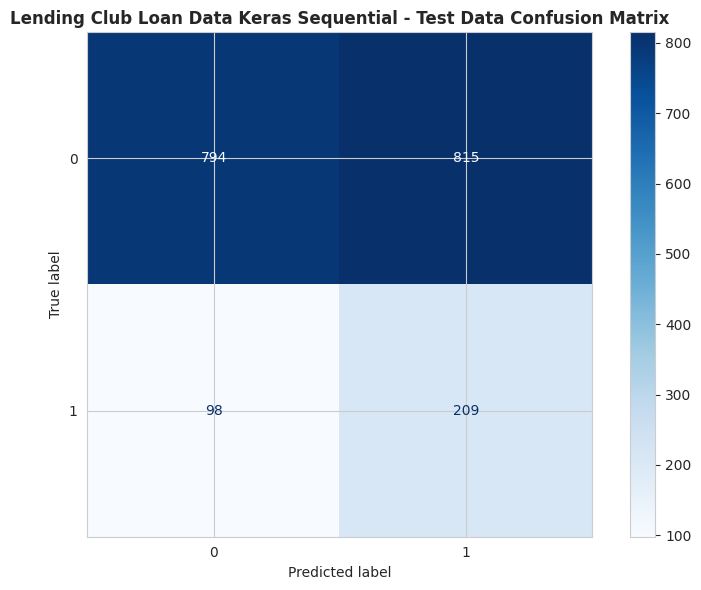

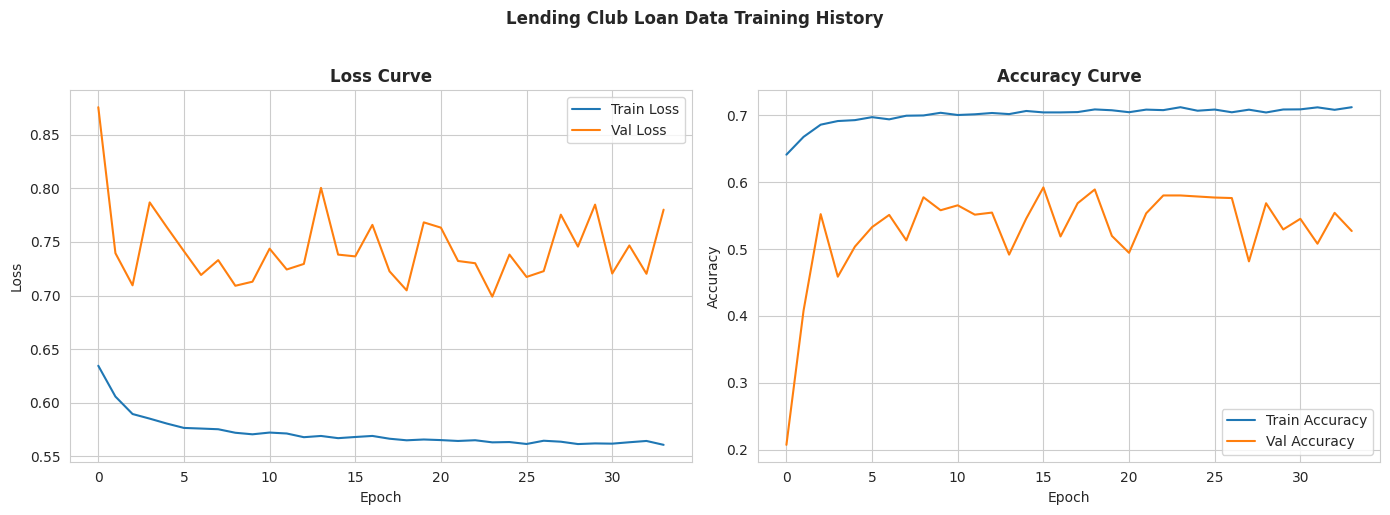


Completed Run #9
Batch size: 256, learning rate: 0.0001...	Sequential Model using Dropouts

Sequential Model Architecture:


Model: "sequential_70"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_280 (Dense)               │ (None, 8)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_122 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_281 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_123 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_282 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_283 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

None
403/403 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.5049
Testing Accuracy:  0.1910
Testing F1 Score:  0.1106
Gap:               0.3139

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.9041095890410958, 'recall': 0.041019266625233065, 'f1-score': 0.07847800237812129, 'support': 1609.0}, '1': {'precision': 0.16277807921866522, 'recall': 0.9771986970684039, 'f1-score': 0.27906976744186046, 'support': 307.0}, 'accuracy': 0.19102296450939457, 'macro avg': {'precision': 0.5334438341298805, 'recall': 0.5091089818468185, 'f1-score': 0.17877388490999088, 'support': 1916.0}, 'weighted avg': {'precision': 0.7853263043252888, 'recall': 0.19102296450939457, 'f1-score': 0.11061874970305237, 'support': 1916.0}

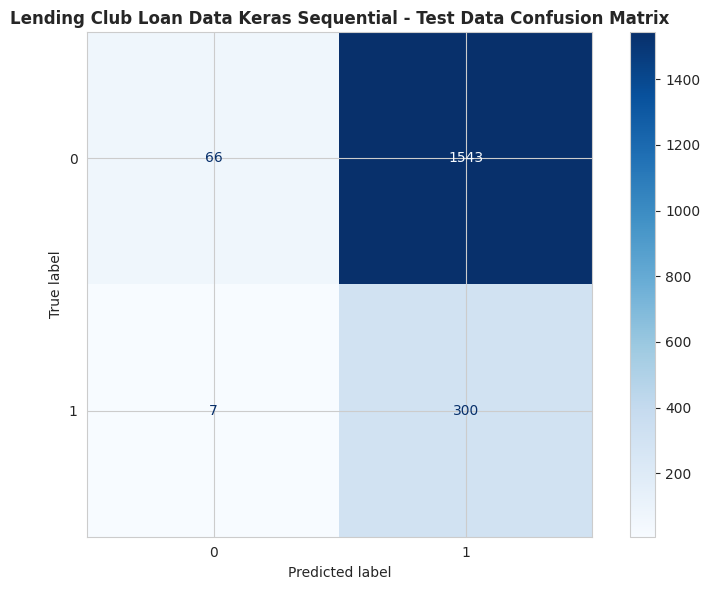

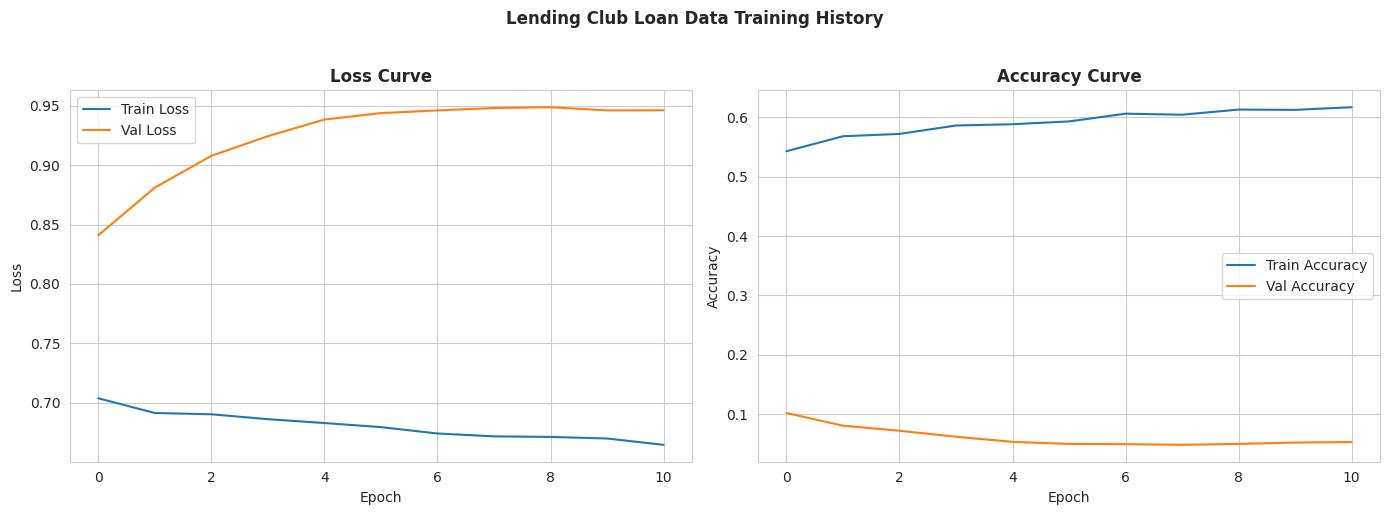


Completed Run #10
Batch size: 256, learning rate: 0.001...	Sequential Model using Dropouts

Sequential Model Architecture:


Model: "sequential_71"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_284 (Dense)               │ (None, 8)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_124 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_285 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_125 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_286 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_287 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

None
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.5024
Testing Accuracy:  0.1660
Testing F1 Score:  0.0568
Gap:               0.3364

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.9230769230769231, 'recall': 0.0074580484773151025, 'f1-score': 0.014796547472256474, 'support': 1609.0}, '1': {'precision': 0.1607987388334209, 'recall': 0.996742671009772, 'f1-score': 0.27692307692307694, 'support': 307.0}, 'accuracy': 0.16597077244258873, 'macro avg': {'precision': 0.541937830955172, 'recall': 0.5021003597435435, 'f1-score': 0.1458598121976667, 'support': 1916.0}, 'weighted avg': {'precision': 0.8009373601527294, 'recall': 0.16597077244258873, 'f1-score': 0.05679698825586915, 'support': 1916.0}}


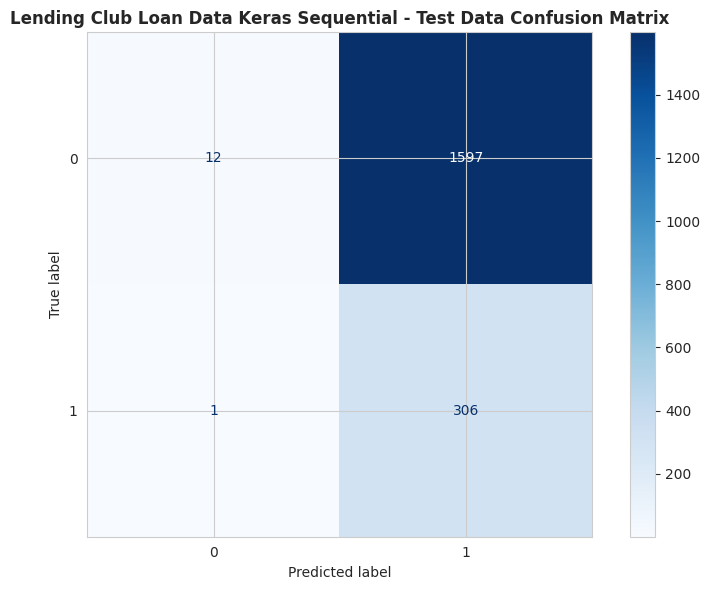

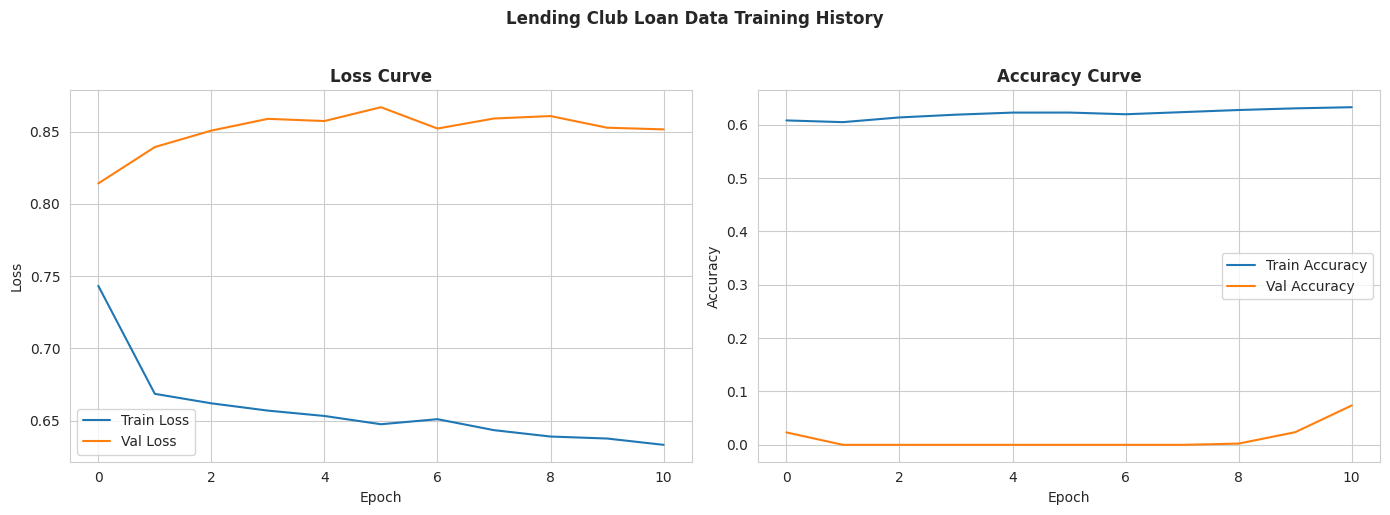


Completed Run #11
Batch size: 256, learning rate: 0.01...	Sequential Model using Dropouts

Sequential Model Architecture:


Model: "sequential_72"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_288 (Dense)               │ (None, 8)              │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_126 (Dropout)           │ (None, 8)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_289 (Dense)               │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_127 (Dropout)           │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_290 (Dense)               │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_291 (Dense)               │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 649 (2.54 KB)

 Trainable params: 649 (2.54 KB)

 Non-trainable params: 0 (0.00 B)

None
403/403 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Lending Club Loan Data KERAS SEQUENTIAL MODEL RESULTS
Scaling: False
Class Weights: None
Training Accuracy: 0.6593
Testing Accuracy:  0.4629
Testing F1 Score:  0.5206
Gap:               0.1964

------------------------------------------------------------
Lending Club Loan Data TEST DATA - Classification Report
------------------------------------------------------------
{'0': {'precision': 0.8940217391304348, 'recall': 0.4089496581727781, 'f1-score': 0.5611940298507463, 'support': 1609.0}, '1': {'precision': 0.19406779661016949, 'recall': 0.745928338762215, 'f1-score': 0.30800268997982516, 'support': 307.0}, 'accuracy': 0.4629436325678497, 'macro avg': {'precision': 0.5440447678703022, 'recall': 0.5774389984674966, 'f1-score': 0.4345983599152857, 'support': 1916.0}, 'weighted avg': {'precision': 0.7818683673383046, 'recall': 0.4629436325678497, 'f1-score': 0.520625271322368, 'support': 1916.0}}



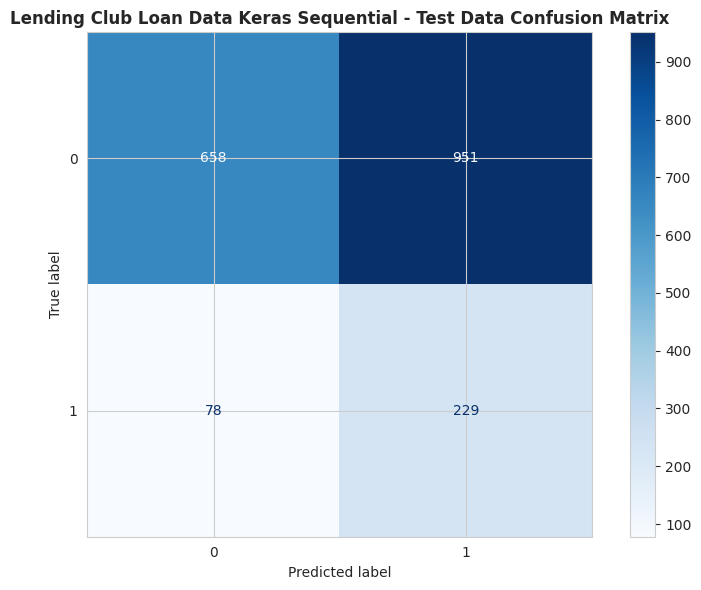

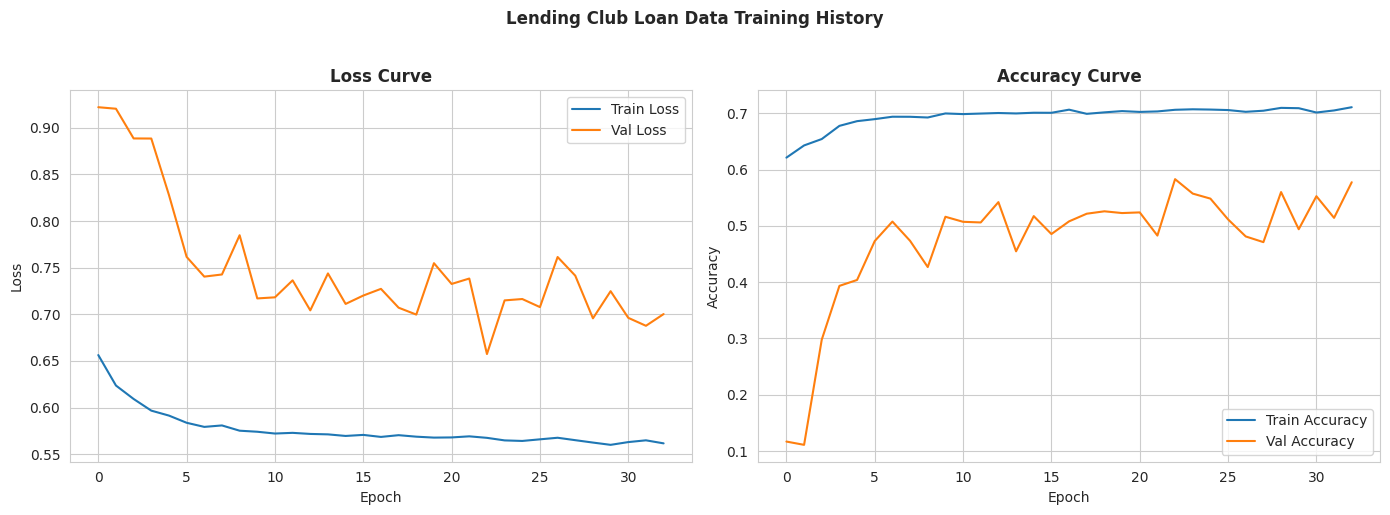


Completed Run #12


In [ ]:
#
# Try different batch sizes, learning rates, thresholds
#
#batch_sizes = [256, 512, 1024]
batch_sizes = [32, 64, 128, 256]
#learning_rates = [1e-6, 1e-5, 1e-4]
learning_rates = [1e-4, 1e-3, 1e-2]
thresholds = [0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
add_dropouts = [True, False]

epochs = 150

feature_engineered_sequential_results = {}
run_number = 1

# Iterate through hyperparameters to determine the best combination
for batch_size, learning_rate, threshold, add_dropout in itertools.product(batch_sizes, learning_rates, thresholds, add_dropouts):

    run_number_label = f'Run Number #{run_number}'
    print(f'{run_number_label}: Batch size: {batch_size}, learning rate: {learning_rate}, threshold: {threshold}, add_dropout: {add_dropout}', end='\t')


    feature_engineered_sequential_result = RunSequentialModel(plot_title='Lending Club Loan Data',
                                                            X_train=X_train_smote, 
                                                            X_test=X_test,
                                                            y_train=y_train_smote, 
                                                            y_test=y_test,
                                                            feature_names=None,
                                                            learning_rate=learning_rate,
                                                            epochs=epochs,
                                                            batch_size=batch_size,
                                                            patience=10,
                                                            apply_scaling=False,
                                                            class_weights=None,
                                                            threshold=threshold,
                                                            add_dropouts=add_dropout)

    # Make sure to grab hypertuneparameters    
    feature_engineered_sequential_result['batch_size'] = batch_size
    feature_engineered_sequential_result['learning_rate'] = learning_rate
    feature_engineered_sequential_result['threshold'] = threshold
    feature_engineered_sequential_result['add_dropout'] = add_dropout
    
    feature_engineered_sequential_results[f'Run{run_number}'] = feature_engineered_sequential_result
    print(f'Completed {run_number_label}')
    run_number +=1



#### Examine Sequential Model Results ####
Examine the Sequential Model runs and determine the best hyperparameter combination.</br>
Save that to the collection of feature engineered model results for comparison

#### Find The Best Performing Sequential Model (Feature Engineered Data)


In [ ]:
summary = pd.DataFrame([
                        {
                            'Batch Size': r['batch_size'],
                            'Learning Rate': r['learning_rate'],
                            'Threshold': r['threshold'],
                            'Dropout': r['add_dropout'],                            
                            'Test Accuracy': r['test_accuracy'],
                            'F1 Score': r['f1_score'],
                            'Val Loss': min(r['history'].history['val_loss'])
                        }
                        for run, r in feature_engineered_sequential_results.items()
                    ], index=feature_engineered_sequential_results.keys())

print(summary)

print('Accuracy Rankings')
print(summary.sort_values('Test Accuracy', ascending=False))
print()
print('F1 Score Rankings')
print(summary.sort_values('F1 Score', ascending=False))
print()
print('Val Loss Rankings')
print(summary.sort_values('Val Loss'))

# Choose best iteration of sequential model by hand
# Not using anything to automatically track best performance (keras_tuner, GridSearchCV)
# Weight the metrics to determine the best performing model
# val loss weight is highest, because most important

w_accuracy = 0.2
w_f1 = 0.3
w_valloss = 0.5

# Val Loss - lower is better
summary['Weighted Score'] = (w_accuracy * summary['Test Accuracy'] + 
                              w_f1 * summary['F1 Score'] + 
                              w_valloss * (1 - summary['Val Loss']))

summary = summary.sort_values('Weighted Score', ascending=False)

print('Best Model Performance Ranked by weighted score')
print(summary.iloc[0])
print(summary.index[0])

best_run = summary.index[0]
best_results = feature_engineered_sequential_results[best_run]
print(f"Best Run: {best_run}")
print(f"Best: {best_run} batch={best_results['batch_size']}, lr={best_results['learning_rate']}, threshold={best_results['threshold']}, dropout={best_results['add_dropout']}")


       Test Accuracy  F1 Score  Val Loss
Run1        0.160230  0.044256  0.617298
Run2        0.553236  0.611947  0.714195
Run3        0.472338  0.527683  0.660605
Run4        0.161273  0.046381  0.803876
Run5        0.456159  0.511681  0.697160
Run6        0.530793  0.590147  0.760941
Run7        0.160230  0.045194  0.702093
Run8        0.505219  0.564384  0.692773
Run9        0.523486  0.583529  0.698952
Run10       0.191023  0.110619  0.840998
Run11       0.165971  0.056797  0.814132
Run12       0.462944  0.520625  0.657450
Accuracy Rankings
       Test Accuracy  F1 Score  Val Loss
Run2        0.553236  0.611947  0.714195
Run6        0.530793  0.590147  0.760941
Run9        0.523486  0.583529  0.698952
Run8        0.505219  0.564384  0.692773
Run3        0.472338  0.527683  0.660605
Run12       0.462944  0.520625  0.657450
Run5        0.456159  0.511681  0.697160
Run10       0.191023  0.110619  0.840998
Run11       0.165971  0.056797  0.814132
Run4        0.161273  0.046381  0.80387

#### Best Performing Sequential Run ####
The best performing run based on the weighted metrics is Run #5

#### Feature Engineered Data Modeling Results ####

Double check the Classification Results


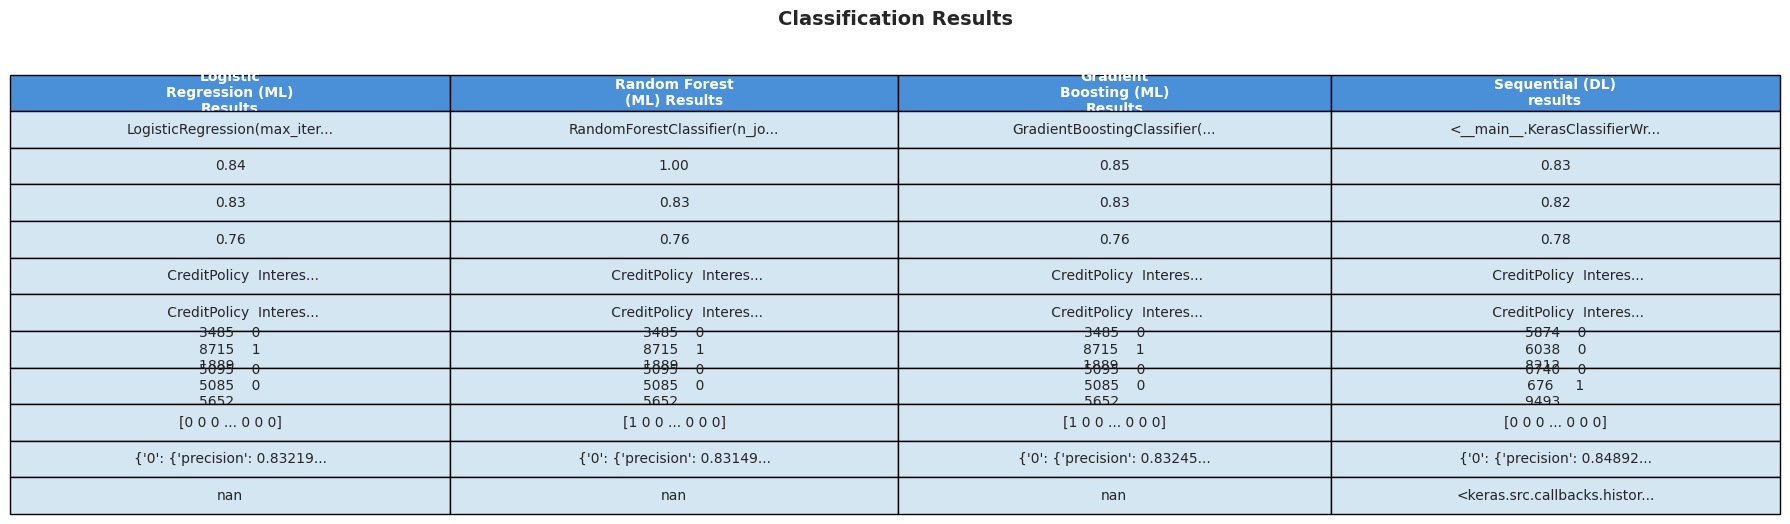



60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
Classification Model Feature Engineered Results
                                          Train Accuracy  Test Accuracy  \
Model                                                                     
Trained Logistic Regression (ML) Results          0.6975         0.6649   
Trained Random Forest (ML) Results                1.0000         0.7714   
Trained Gradient Boosting (ML) Results            0.7490         0.6785   
Trained Sequential (DL) results                   0.6965         0.5532   

                                          Balanced Accuracy  Precision  \
Model                                                                    
Trained Logistic Regression (ML) Results             0.5812     0.7688   
Trained Random Forest (ML) Results                   0.5638     0.7658   
Trained Gradient Boosting (ML) Results               0.5916     0.7736   
Trained Sequential (DL) results                      0.5582     0.7611   

               

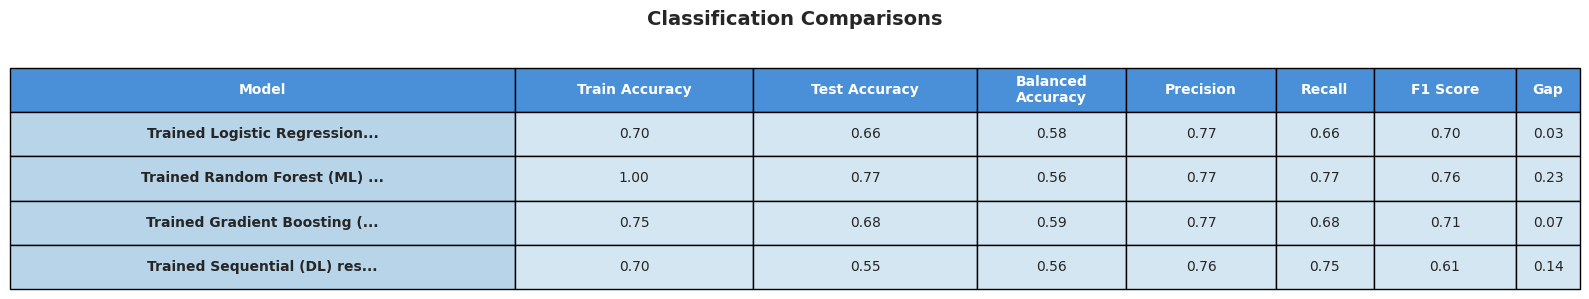



60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


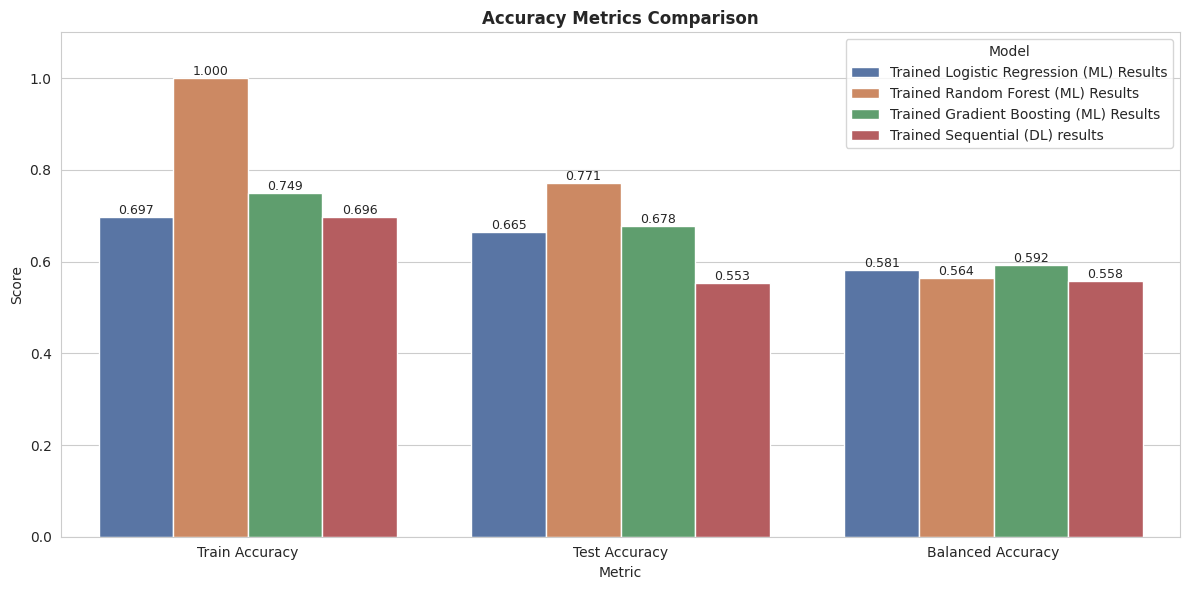


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


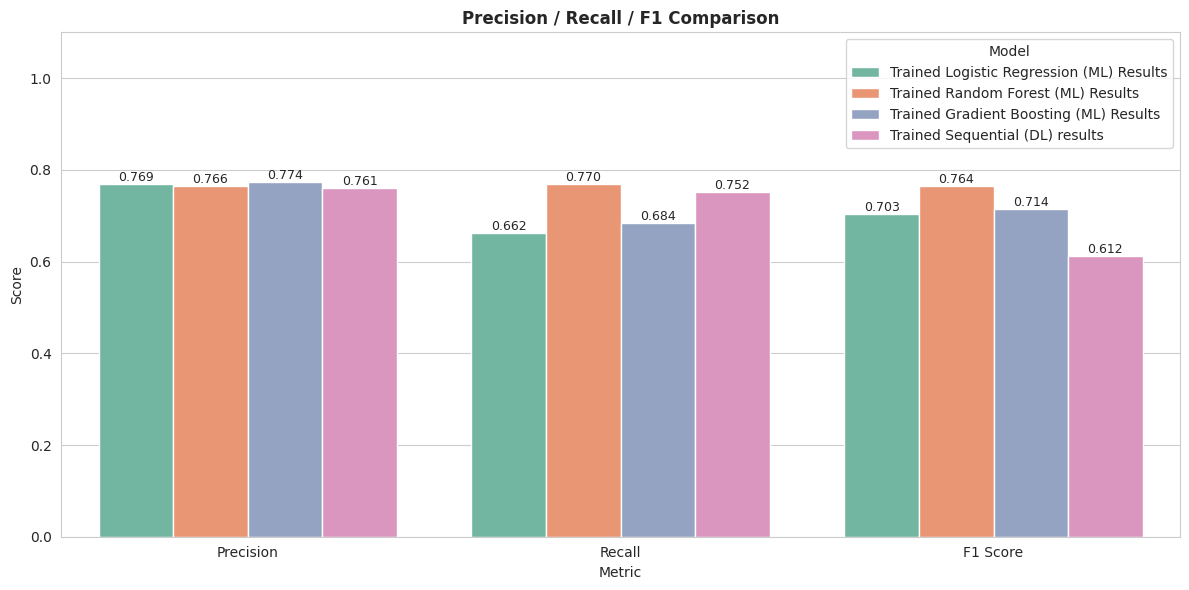

/tmp/ipykernel_1251/4279958838.py:485: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=gap_data, x='Model', y='Gap', palette='deep')


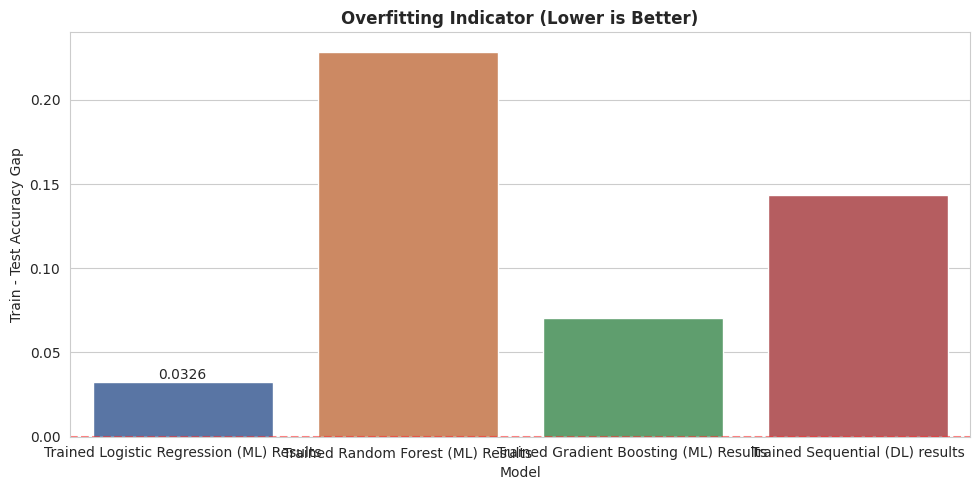


60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


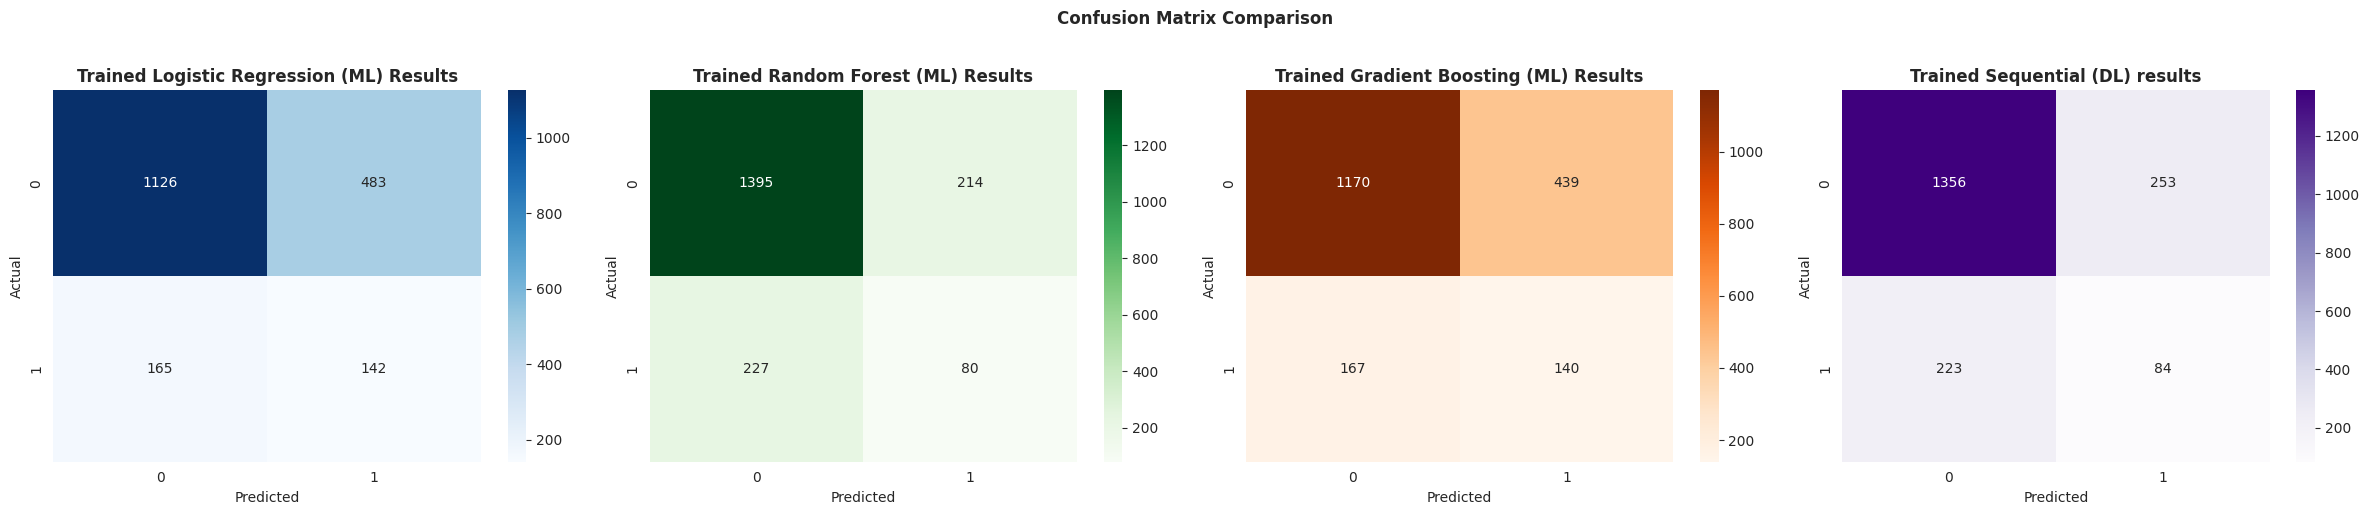

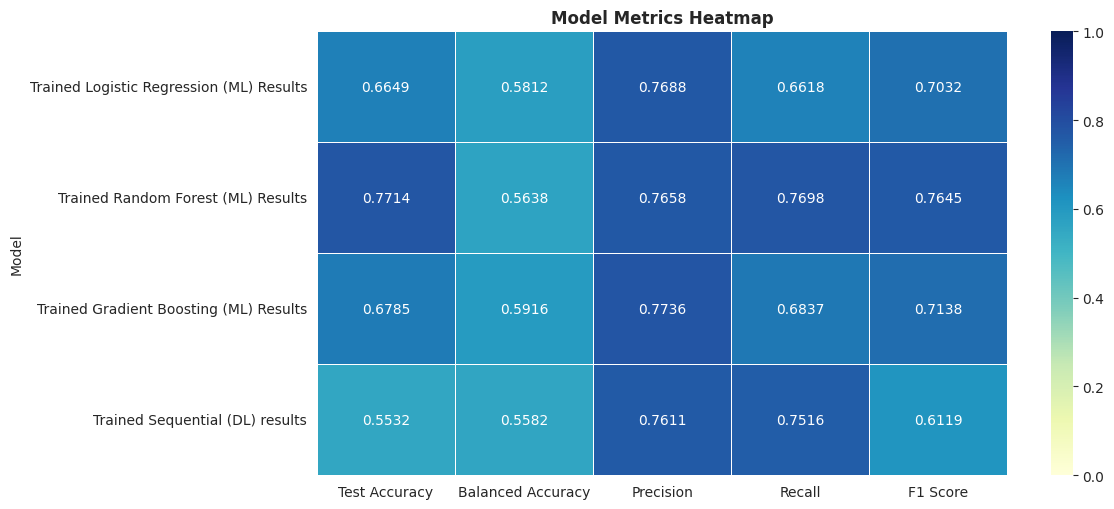

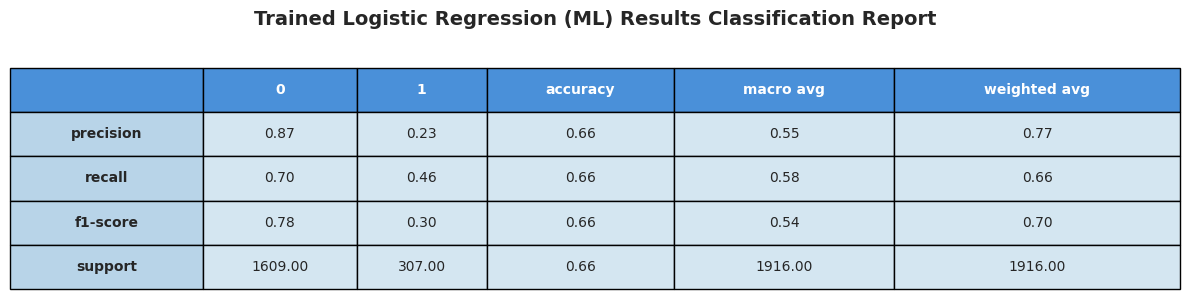

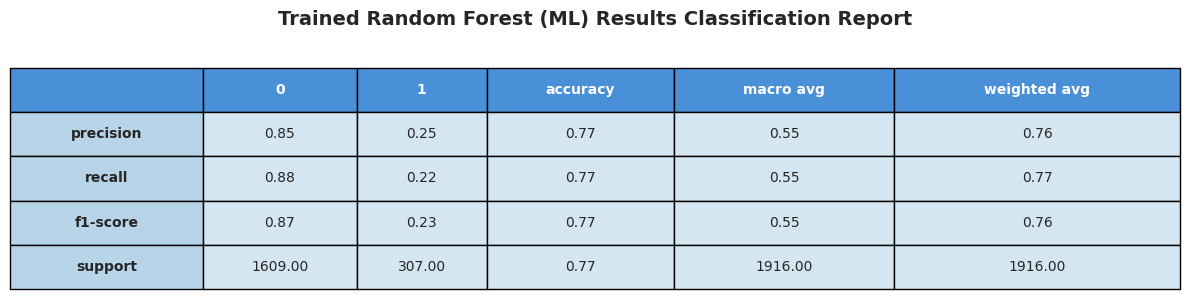

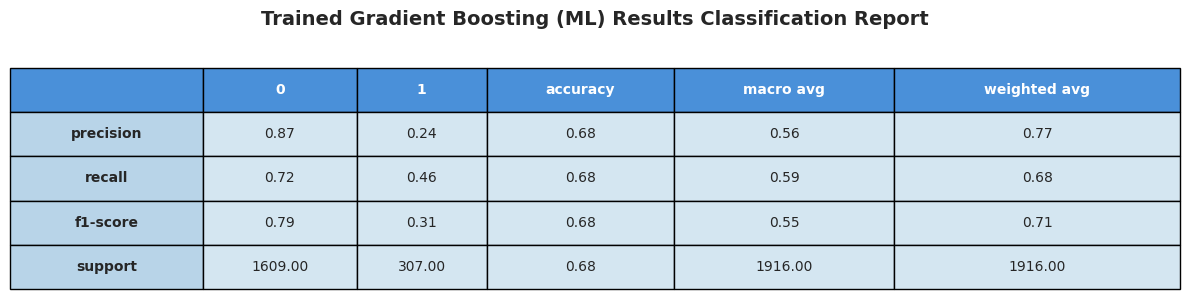

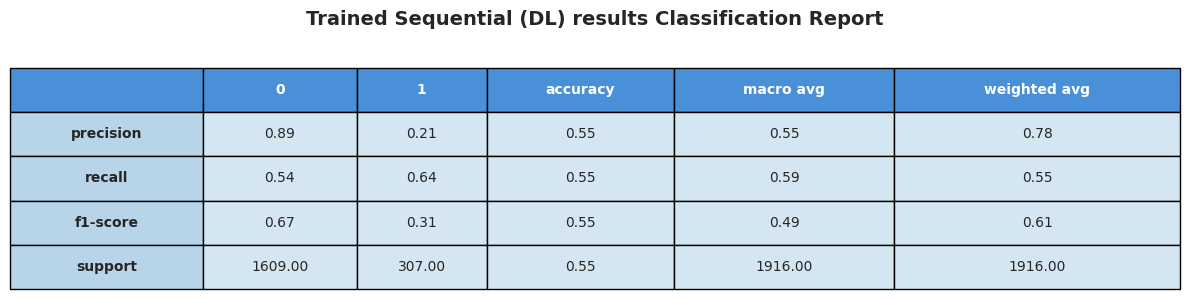

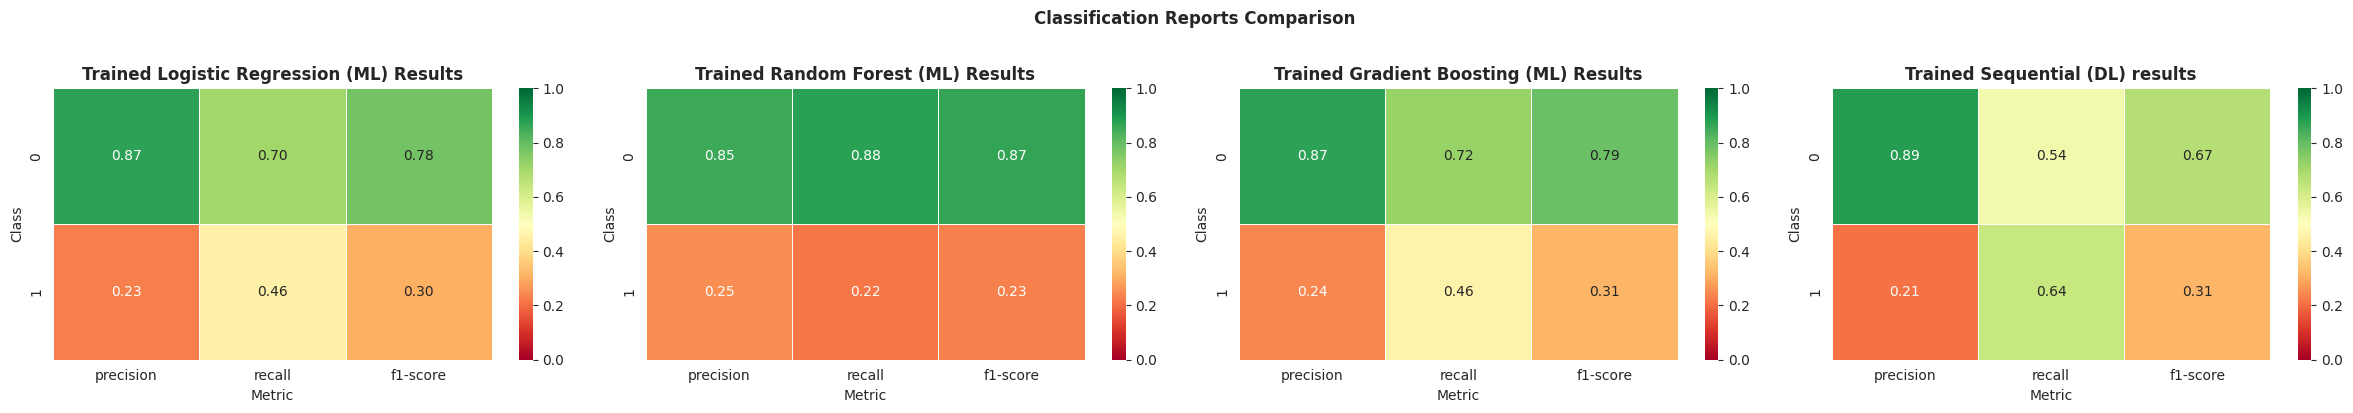

In [216]:
# Display Comparisons

feature_engineered_results_dict = {
                                    'Trained Logistic Regression (ML) Results': feature_engineered_LogisticRegressionResults,
                                    'Trained Random Forest (ML) Results': feature_engineered_RandomForestResults,
                                    'Trained Gradient Boosting (ML) Results': feature_engineered_GradientBoostingResults,
                                    'Trained Sequential (DL) results': best_feature_engineered_sequential_results
                                }

print('Double check the Classification Results')
df_Results = pd.DataFrame(results_dict)
DisplayTable(df_Results, 'Classification Results')

CompareClassificationResults(feature_engineered_results_dict, title='Classification Model Feature Engineered Results')
print()
print()

#### Track Notebook Runtime Performance ####

In [ ]:
elapsed = time.time() - notebook_start_time
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print('======================================================================')
print()
print(f'Total notebook runtime: {hours}h {minutes}m {seconds}s')
print()
print('======================================================================')

##### **Test Set Evaluation** #####

In [217]:
XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX


# Evaluate on test set
logistic_predictions = lr_model.predict(df_testing[features])
logistic_rsquared = lr_model.score(df_testing[features], df_testing[label])
print(f'Linear regression R² on test set: {logistic_rsquared:.4f}')

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(df_testing[label], logistic_predictions, ax=ax, cmap='Blues')
plt.title('Test Data Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()
print()

NameError: name 'XXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXXX' is not defined

**Logistic Regression Confusion Matrix Analysis** 
- Model is good at predicting customers who stay (1920)
- Model is bad at catching customers who actually leave (miss 399 of 497)

In [ ]:
# Compute class weights to handle class imbalance
# class_weights = compute_class_weight(
#     class_weight='balanced',
#     classes=np.unique(df_training[label]),
#     y=df_training[label]
# )

# class_weight_dict = dict(enumerate(class_weights))
# print(f'Class weights: {class_weight_dict}')

##### **Callback Function Constructors** #####

##### **Model Constructor Function** #####
- Activation Functions: - Decides whether neuron fires not. Introduces nonlinearity into model</br>
    1) **ReLU**  - for hidden layers; computationally efficient; outputs if positive, otherwise 0; maintains gradient
    2) **Sigmoid** - Used for binary classification of output layer; probability between 0 and 1
- Optimizer: - Adjusts model weights during training to minimize loss function.</br>
    1) **Adam Optimizer** - automatically adjusts during training; faster convergence</br>
- Loss: - how to measure difference between predictions and actual values</br>
    1) **binary_crossentropy** - specifically for binary classification problems where output is **0** or **1**
- Metrics: - used to track model performance during training and evaluation.
    1) accur**acy - accuracy is used for classification. In this case for binary classification I should have explicitly </br>
                  selected binary_accuracy; But Keras detects **binary_crossentropy** and automatically interprets **accuracy** </br>
                  to be **binary_accuracy**


##### **Model Training Function** #####
Architecture directly from George and Assignment_28. </br>
Unfortunately not enough time to explore KerasTuner, </br>
so I followed existing pattern to do some basic hyperparameter tuning.

##### **Train the Model** #####

##### **Retrain Model with Optimal Hyperparameters** #####

In [ ]:
batch_size = 512
learning_rate = 0.0001

callbacks = MakeCallbacks(learning_rate=learning_rate, batch_size=batch_size)
sequential_model = BuildModel(learning_rate=learning_rate)
sequential_model, sequential_history = TrainModel(sequential_model, batch_size=batch_size, callbacks=callbacks)

model.summary()

##### **Plot the Learning Curves** #####

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(9, 4))

axes[0].set_title('Optimized DNN: loss')
axes[0].plot(sequential_history.history['loss'], label='Training')
axes[0].plot(sequential_history.history['val_loss'], label='Validation')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss (binary crossentropy)')
axes[0].legend(loc='best')

axes[1].set_title('Optimized DNN: accuracy')
axes[1].plot(sequential_history.history['accuracy'], label='Training')
axes[1].plot(sequential_history.history['val_accuracy'], label='Validation')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend(loc='best')

plt.tight_layout()
plt.show()

**Sequential Model -  Loss and Accuracy Analysis** 
- Widening gap between train/test indicates model begins overfitting
- Loss - validation flattens out @ around 100 epochs, training continues to decrease
- Accuracy - similar behaviour to loss @ 100 epochs.

##### **Test Set Evaluation** #####

In [ ]:
sequential_probs = sequential_model.predict(df_testing[features], verbose=0).flatten()
sequential_predictions = (sequential_probs >= 0.5).astype(int)
sequential_accuracy = accuracy_score(df_testing[label], sequential_predictions)

print(f'Optimized DNN model accuracy on test set: {sequential_accuracy:.4f}')

#### **Performance Analysis** ####
Display Confusion Matrix

In [ ]:
# Display confusion matrix

print(sequential_predictions)
sequential_predictions_binary = (sequential_predictions > 0.5).astype(int)

# Confusion Matrix
fig, ax = plt.subplots(figsize=(8, 6))
ConfusionMatrixDisplay.from_predictions(df_testing[label], sequential_predictions_binary, ax=ax, cmap='Greens')
plt.title('Test Data Confusion Matrix', fontweight='bold')
plt.tight_layout()
plt.show()
print()

**Sequential Model Confusion Matrix Analysis** 
- Model is good at predicting customers who stay (1612)
- Model is decent at catching customers who actually leave (misses 137 of 497)
- False Alarms - predicts a decent percentage of customers will leave that don't,</br>
                 not a bad thing. Bank can be more proactive with these customers.

#### **Compare LogisticRegression and Best Sequential_Model Results** ####
##### **Classification Reports** #####

In [ ]:
report = classification_report(y_test, logistic_predictions, output_dict=True)
df_report = pd.DataFrame(report).transpose().T
DisplayTable(df_report, 
             'Logistic Regression Classification Report', 
             show_index=True)
print()

report = classification_report(y_test, sequential_predictions, output_dict=True)
df_report = pd.DataFrame(report).transpose().T
DisplayTable(df_report, 
             'Sequential Model Classification Report', 
             show_index=True)

**Classification Report Comparison**</br> 
    1) **precision** - Sequential Model has higher precision</br>
    2) **recall** - Sequential Model has lower recall</br>
    3) **f1-score** - Sequential Model has lower f1-score</br>

##### **Confusion Matrices** #####

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 8))
    
# Confusion Matrix
ConfusionMatrixDisplay.from_predictions(df_testing[label], logistic_predictions, ax=axes[0], cmap='Blues')
axes[0].set_title('Logistic Regression', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(df_testing[label], sequential_predictions, ax=axes[1], cmap='Greens')
axes[1].set_title('Sequential Model', fontweight='bold')

plt.suptitle('Confusion Matrix Comparison', fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print()

**Confusion Matrices Comparison**</br> 
**Logistic Regression** has higher accuracy, but misses roughly 80% of customers who leave. </br>
**Sequential Model** catches more customers who would leave, but has more false alarms of </br>
customers predicted to leave that stay.</br> </br>
From a business stand point, **Sequential Model** is more useful as it's better be more accurate </br>
predicting customers that leave; having false positives (customers predicted to leave that don't </br>
doesn't cost the bank anything in terms of lost business.

##### **Compare AUC-ROC Curves** #####

In [ ]:
# 
# First calculate roc_auc_score
#

# Get the predict probabilities of the positives (class 1)
y_pred_proba_lr = lr_model.predict_proba(df_testing[features])[:,1]
y_pred_proba_sequential = sequential_model.predict(df_testing[features]).flatten()

# Calculate the AUC score
y_test = df_testing[label]
auc_lr = roc_auc_score(y_test, y_pred_proba_lr)
auc_sequential = roc_auc_score(y_test, y_pred_proba_sequential)

aucScores = [
                {
                    'name' : 'LogisticRegression', 
                    'y_pred_proba' : y_pred_proba_lr, 
                    'auc' : auc_lr
                },
                {
                    'name' : 'Sequential Model', 
                    'y_pred_proba' : y_pred_proba_sequential,
                    'auc' : auc_sequential
                }
            ]

plt.figure(figsize=(8,6))

# Calculate and plot the auc curves
for aucScore in aucScores:
    
    # fpr - false alarms
    # tpr - recall
    fpr, tpr, _ = roc_curve(y_test, aucScore['y_pred_proba'])
    plt.plot(fpr, tpr, label=f"{aucScore['name']} (AUC = {aucScore['auc']:.3f})")


plt.plot([0, 1], [0, 1], 'k--', label='Random Chance')
plt.xlabel('False Positive Rate', fontweight='bold')
plt.ylabel('True Positive Rate', fontweight='bold')
plt.title('ROC Curve Comparisons', fontweight='bold')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


##### **Precision - Recall Curves**

In [ ]:
#
# Precision / Recall / F1 Comparison
#
prf_metrics = []

prf_metrics.append({'Model': 'Logistic Regression', 'Metric': 'Precision', 'Score': precision_score(y_test, logistic_predictions, average='weighted')})
prf_metrics.append({'Model': 'Logistic Regression', 'Metric': 'Recall', 'Score': recall_score(y_test, logistic_predictions, average='weighted')})
prf_metrics.append({'Model': 'Logistic Regression', 'Metric': 'F1 Score', 'Score': f1_score(y_test, logistic_predictions, average='weighted')})

prf_metrics.append({'Model': 'Sequential Model', 'Metric': 'Precision', 'Score': precision_score(y_test, sequential_predictions, average='weighted')})
prf_metrics.append({'Model': 'Sequential Model', 'Metric': 'Recall', 'Score': recall_score(y_test, sequential_predictions, average='weighted')})
prf_metrics.append({'Model': 'Sequential Model', 'Metric': 'F1 Score', 'Score': f1_score(y_test, sequential_predictions, average='weighted')})

prf_df = pd.DataFrame(prf_metrics)
DisplayTable(prf_df)

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=prf_df, x='Metric', y='Score', hue='Model', palette='Set2')
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', fontsize=9)
plt.title('Precision / Recall / F1 Comparison', fontweight='bold')
plt.ylim(0, 1.1)
plt.legend(title='Model')
plt.tight_layout()
plt.show()
print()

# Get predict probabilities
y_pred_proba_lr = lr_model.predict_proba(df_testing[features])[:,1]
y_pred_proba_sequential = sequential_model.predict(df_testing[features]).flatten()

# Calculate average precision scores
ap_lr = average_precision_score(y_test, y_pred_proba_lr)
ap_sequential = average_precision_score(y_test, y_pred_proba_sequential)

plt.figure(figsize=(8,6))

# Logistic Regression
precision_lr, recall_lr, _ = precision_recall_curve(y_test, y_pred_proba_lr)
plt.plot(recall_lr, precision_lr, label=f"Logistic Regression (AP = {ap_lr:.3f})")

# Sequential Model
precision_seq, recall_seq, _ = precision_recall_curve(y_test, y_pred_proba_sequential)
plt.plot(recall_seq, precision_seq, label=f"Sequential Model (AP = {ap_sequential:.3f})")

plt.xlabel('Recall', fontweight='bold')
plt.ylabel('Precision', fontweight='bold')
plt.title('Precision-Recall Curves', fontweight='bold')
plt.legend(loc='lower left')
plt.tight_layout()
plt.show()

##### **Final Thoughts and Comments** #####
- Sequential Model performs better than Linear Regression, but not by a large margin
- Sequential Model is much more computationally expensive. Final model choice must consider this
	  in addition to how much Sequential Model outperforms Logistic Regression. Is it worth the cost?
- In the end, missing "Churners" costs the bank in terms of lost business. Cost to be proactive
  to retain customers is far less.
- One could spend a lot of time/effort/computation optimizing Sequential Models to get optimum performance.
  (Need to step back and analyze at what point you stop; diminishing returns.)
- I'm getting better at interpreting Confusion Matrices and other plots
- For Precision/Recall and other metrics, I'm still not entirely clear on analyzing.